# IMDb Movie Review Sentiment Classification

## Project Overview

Sentiment analysis is a fundamental Natural Language Processing (NLP) task that aims to automatically determine the emotional polarity expressed in text. In this project, we build a complete text classification pipeline to classify IMDb movie reviews into two sentiment categories:

- **Positive**
- **Negative**

The project is designed to cover the full NLP workflow, starting from raw text preprocessing and classical feature extraction methods, then progressing toward neural sequence models and pretrained Transformer-based approaches.

The main objective is not only to achieve strong predictive performance, but also to understand how different text representation techniques and model architectures affect classification quality, computational requirements, and generalization.

---

## Project Objectives

This project aims to:

1. Load and inspect the IMDb movie review dataset.
2. Perform systematic text preprocessing and cleaning.
3. Analyze review lengths and sentiment class distribution.
4. Tokenize textual data and prepare sequences for neural networks.
5. Build a **TF-IDF + Logistic Regression** baseline classifier.
6. Experiment with TF-IDF parameters such as vocabulary size and n-grams.
7. Train and analyze **Word2Vec** word embeddings.
8. Build and evaluate a **Simple RNN** sentiment classifier.
9. Build and evaluate an **LSTM** sentiment classifier.
10. Compare RNN and LSTM architectures under a consistent experimental setup.
11. Explore additional recurrent architectures such as **GRU** and **Bidirectional LSTM**.
12. Analyze the effect of regularization techniques such as **Dropout**.
13. Understand the main components of the Transformer architecture.
14. Apply a pretrained Transformer model for sentiment classification.
15. Compare all models using consistent evaluation metrics.
16. Perform error analysis to understand why models make incorrect predictions.
17. Identify the most suitable model based on predictive performance, generalization, and computational cost.

---

## Evaluation Strategy

All classification models will be evaluated using:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **Confusion Matrix**

For neural network models, training and validation performance will also be monitored using:

- Training Accuracy
- Validation Accuracy
- Training Loss
- Validation Loss

These learning curves will be used to investigate possible **overfitting** or **underfitting**.

---

## Experimental Principles

To ensure a reliable and fair comparison:

- The same data split will be reused whenever possible across comparable models.
- Feature extraction methods will be fitted using the training data only to prevent **data leakage**.
- Hyperparameter experiments will be performed systematically rather than selecting arbitrary values.
- Model conclusions will be based only on experimentally observed results.
- Reproducibility will be maintained using fixed random seeds and clearly documented processing steps.

# 1. Environment Setup and Reproducibility

## Why is this step important?

Machine learning and deep learning experiments may produce slightly different results across different runs because of random initialization, data shuffling, and stochastic optimization.

To improve reproducibility, we will set fixed random seeds for the main libraries used throughout the project.

This helps ensure that:

- Dataset splitting remains consistent.
- Neural network initialization becomes more reproducible.
- Experimental comparisons are fairer.
- Results can be reproduced when the notebook is executed again.

Although complete numerical reproducibility may still vary slightly depending on hardware, TensorFlow version, or GPU configuration, fixing the major random seeds significantly reduces unnecessary variation.

In [1]:
# Standard Python libraries
import os
import random
import warnings

# Numerical and data manipulation libraries
import numpy as np
import pandas as pd

# Set a fixed random seed for reproducibility
RANDOM_STATE = 42

# Set Python random seed
random.seed(RANDOM_STATE)

# Set NumPy random seed
np.random.seed(RANDOM_STATE)

# Reduce unnecessary warning messages during notebook execution
warnings.filterwarnings("ignore")

print("Reproducibility settings initialized successfully.")
print(f"Random State: {RANDOM_STATE}")

Reproducibility settings initialized successfully.
Random State: 42


### Observation

The global random seed was successfully initialized using a fixed value of **42**. This value will be reused throughout the project wherever random operations are required, helping maintain a consistent and reproducible experimental setup.

# 2. Import Required Libraries

## Purpose

This section imports the libraries required throughout the complete NLP pipeline.

The libraries are organized according to their role in the project:

- **NumPy and Pandas** for numerical operations and dataset manipulation.
- **Matplotlib** for exploratory analysis and model visualization.
- **Scikit-learn** for data splitting, TF-IDF representation, Logistic Regression, and evaluation metrics.
- **Gensim** for training Word2Vec embeddings.
- **TensorFlow/Keras** for tokenization, sequence preparation, and neural network models.
- **Transformers** for applying a pretrained Transformer-based sentiment classifier.

Keeping the imports centralized improves notebook organization, readability, and reproducibility.

In [4]:
# Install additional NLP dependencies
%pip install -q gensim transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 80.2 MB/s eta 0:00:00


In [5]:
# ============================================================
# STANDARD PYTHON LIBRARIES
# ============================================================

import os                                      # Operating system utilities
import re                                      # Regular expressions for text cleaning
import random                                  # Random number generation
import warnings                                # Warning control
from collections import Counter                # Frequency counting


# ============================================================
# DATA HANDLING
# ============================================================

import numpy as np                             # Numerical operations
import pandas as pd                            # Data manipulation and analysis


# ============================================================
# VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt                # Data visualization


# ============================================================
# SCIKIT-LEARN: DATA SPLITTING
# ============================================================

from sklearn.model_selection import (
    train_test_split                           # Train/test splitting
)


# ============================================================
# SCIKIT-LEARN: TEXT REPRESENTATION
# ============================================================

from sklearn.feature_extraction.text import (
    TfidfVectorizer                            # TF-IDF feature extraction
)


# ============================================================
# SCIKIT-LEARN: CLASSIFICATION
# ============================================================

from sklearn.linear_model import (
    LogisticRegression                         # Baseline classifier
)


# ============================================================
# SCIKIT-LEARN: MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,                            # Classification accuracy
    precision_score,                           # Precision
    recall_score,                              # Recall
    f1_score,                                  # F1-score
    classification_report,                     # Detailed classification metrics
    confusion_matrix,                          # Confusion matrix values
    ConfusionMatrixDisplay                     # Confusion matrix visualization
)


# ============================================================
# WORD EMBEDDINGS
# ============================================================

from gensim.models import Word2Vec              # Word2Vec word embeddings


# ============================================================
# TENSORFLOW / KERAS
# ============================================================

import tensorflow as tf                        # Deep learning framework

from tensorflow.keras.models import (
    Sequential                                 # Sequential neural network API
)

from tensorflow.keras.layers import (
    Embedding,                                 # Trainable word embeddings
    SimpleRNN,                                 # Basic recurrent neural network
    LSTM,                                      # Long Short-Term Memory network
    GRU,                                       # Gated Recurrent Unit
    Bidirectional,                             # Bidirectional recurrent wrapper
    Dense,                                     # Fully connected layer
    Dropout                                    # Regularization layer
)

from tensorflow.keras.preprocessing.text import (
    Tokenizer                                  # Convert text into integer sequences
)

from tensorflow.keras.preprocessing.sequence import (
    pad_sequences                              # Pad/truncate sequences
)

from tensorflow.keras.callbacks import (
    EarlyStopping,                             # Stop training when validation stops improving
    ReduceLROnPlateau                          # Reduce learning rate when improvement stalls
)


# ============================================================
# REPRODUCIBILITY
# ============================================================

RANDOM_STATE = 42                              # Global random seed

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

random.seed(RANDOM_STATE)                      # Python random seed
np.random.seed(RANDOM_STATE)                   # NumPy random seed
tf.random.set_seed(RANDOM_STATE)               # TensorFlow random seed


# ============================================================
# NOTEBOOK SETTINGS
# ============================================================

warnings.filterwarnings("ignore")              # Hide unnecessary warning messages

pd.set_option("display.max_colwidth", 200)      # Improve review-text display


# ============================================================
# ENVIRONMENT CHECK
# ============================================================

print("=" * 55)
print("NLP PROJECT ENVIRONMENT")
print("=" * 55)

print(f"NumPy Version      : {np.__version__}")
print(f"Pandas Version     : {pd.__version__}")
print(f"TensorFlow Version : {tf.__version__}")
print(f"Random State       : {RANDOM_STATE}")

print("=" * 55)
print("All required libraries imported successfully.")

NLP PROJECT ENVIRONMENT
NumPy Version      : 2.1.3
Pandas Version     : 2.2.3
TensorFlow Version : 2.20.0
Random State       : 42
All required libraries imported successfully.


# 3. Dataset Loading

## Dataset Source

This project uses the **IMDb Movie Reviews Dataset** provided directly through TensorFlow/Keras.

The dataset contains movie reviews labeled according to their sentiment:

- **0 → Negative**
- **1 → Positive**

Using the TensorFlow/Keras dataset provides a standardized and reproducible way to access the IMDb data directly within the notebook without requiring manual CSV downloads or file uploads.

The dataset is loaded into separate training and testing sets, which will later be used consistently throughout the deep learning experiments.

> **Important:** The Keras IMDb dataset is already represented as sequences of integer word indices rather than raw review strings. Therefore, the dataset's word-index mapping will also be loaded so that reviews can be decoded back into readable text when raw-text inspection or classical NLP processing is required.

In [6]:
# ============================================================
# LOAD IMDb DATASET
# ============================================================

from tensorflow.keras.datasets import imdb

# Vocabulary size used when loading the dataset
VOCAB_SIZE = 20000

# Load the IMDb dataset
(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

# Display basic dataset information
print("=" * 55)
print("IMDb DATASET LOADED SUCCESSFULLY")
print("=" * 55)

print(f"Training samples : {len(X_train_raw):,}")
print(f"Testing samples  : {len(X_test_raw):,}")
print(f"Total samples    : {len(X_train_raw) + len(X_test_raw):,}")

print(f"\nTraining labels shape : {y_train.shape}")
print(f"Testing labels shape  : {y_test.shape}")

print(f"\nVocabulary limit : {VOCAB_SIZE:,}")

print("=" * 55)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
IMDb DATASET LOADED SUCCESSFULLY
Training samples : 25,000
Testing samples  : 25,000
Total samples    : 50,000

Training labels shape : (25000,)
Testing labels shape  : (25000,)

Vocabulary limit : 20,000


In [7]:
# ============================================================
# LOAD IMDb WORD INDEX
# ============================================================

# Load the original IMDb word-to-index mapping
word_index = imdb.get_word_index()

# Keras reserves the first indices for special tokens
INDEX_FROM = 3

# Create an index-to-word mapping
reverse_word_index = {
    index + INDEX_FROM: word
    for word, index in word_index.items()
}

# Add special tokens used by the IMDb dataset
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"


# ============================================================
# REVIEW DECODING FUNCTION
# ============================================================

def decode_review(encoded_review):
    """
    Convert an IMDb integer-encoded review back into readable text.
    """

    return " ".join(
        reverse_word_index.get(index, "<UNK>")
        for index in encoded_review
    )


# Decode all training and testing reviews
train_reviews = [decode_review(review) for review in X_train_raw]
test_reviews = [decode_review(review) for review in X_test_raw]


# Display one decoded example
print("Encoded Review:")
print(X_train_raw[0][:30])

print("\nDecoded Review:")
print(train_reviews[0])

print("\nTrue Sentiment:")
print("Positive" if y_train[0] == 1 else "Negative")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Encoded Review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480]

Decoded Review:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the <UNK> of norman and paul 

# 4. Dataset Construction and Initial Inspection

## Purpose

Before applying any preprocessing or building classification models, the dataset must be systematically inspected to understand its structure, quality, and target distribution.

The TensorFlow/Keras IMDb dataset is provided as separate training and testing sets, where each review is represented as a sequence of integer word indices.

To make exploratory analysis and classical NLP processing easier, the decoded reviews and their sentiment labels will be organized into Pandas DataFrames while preserving the original IMDb train/test split.

This stage will examine:

- Dataset dimensions
- Feature and target structure
- Data types
- Missing values
- Duplicate reviews
- Target-label validity
- Sentiment class distribution
- Representative raw review examples

No observations will be removed or modified at this stage. The objective is first to understand the dataset before making any preprocessing decisions.

In [8]:
# ============================================================
# CONSTRUCT TRAINING AND TESTING DATAFRAMES
# ============================================================

# Create the training DataFrame
train_df = pd.DataFrame({
    "review": train_reviews,
    "sentiment": y_train
})

# Create the testing DataFrame
test_df = pd.DataFrame({
    "review": test_reviews,
    "sentiment": y_test
})


# Create readable sentiment labels for analysis and display
sentiment_map = {
    0: "Negative",
    1: "Positive"
}

train_df["sentiment_label"] = train_df["sentiment"].map(sentiment_map)
test_df["sentiment_label"] = test_df["sentiment"].map(sentiment_map)


# Display dataset structure
print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

print(f"Training set shape : {train_df.shape}")
print(f"Testing set shape  : {test_df.shape}")
print(f"Total observations : {len(train_df) + len(test_df):,}")

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nTesting columns:")
print(test_df.columns.tolist())

print("\nData types:")
print(train_df.dtypes)

print("=" * 60)

DATASET STRUCTURE
Training set shape : (25000, 3)
Testing set shape  : (25000, 3)
Total observations : 50,000

Training columns:
['review', 'sentiment', 'sentiment_label']

Testing columns:
['review', 'sentiment', 'sentiment_label']

Data types:
review             object
sentiment           int64
sentiment_label    object
dtype: object


In [9]:
# ============================================================
# DATA QUALITY ASSESSMENT
# ============================================================

print("=" * 60)
print("DATA QUALITY ASSESSMENT")
print("=" * 60)


# ------------------------------------------------------------
# Missing values
# ------------------------------------------------------------

print("\n1. Missing Values — Training Set")
print(train_df.isnull().sum())

print("\n2. Missing Values — Testing Set")
print(test_df.isnull().sum())


# ------------------------------------------------------------
# Duplicate reviews
# ------------------------------------------------------------

train_duplicates = train_df["review"].duplicated().sum()
test_duplicates = test_df["review"].duplicated().sum()

print("\n3. Duplicate Reviews")
print(f"Training duplicates : {train_duplicates:,}")
print(f"Testing duplicates  : {test_duplicates:,}")


# ------------------------------------------------------------
# Cross-split overlap
# ------------------------------------------------------------

train_review_set = set(train_df["review"])
test_review_set = set(test_df["review"])

cross_split_duplicates = len(
    train_review_set.intersection(test_review_set)
)

print("\n4. Train/Test Review Overlap")
print(f"Reviews appearing in both sets: {cross_split_duplicates:,}")


# ------------------------------------------------------------
# Target validity
# ------------------------------------------------------------

print("\n5. Unique Target Values")
print(sorted(train_df["sentiment"].unique()))

print("\n6. Training Sentiment Distribution")
print(train_df["sentiment_label"].value_counts())

print("\n7. Testing Sentiment Distribution")
print(test_df["sentiment_label"].value_counts())


# ------------------------------------------------------------
# Class percentages
# ------------------------------------------------------------

print("\n8. Training Sentiment Percentages")
print(
    train_df["sentiment_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .astype(str) + "%"
)

print("\n9. Testing Sentiment Percentages")
print(
    test_df["sentiment_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .astype(str) + "%"
)

print("=" * 60)

DATA QUALITY ASSESSMENT

1. Missing Values — Training Set
review             0
sentiment          0
sentiment_label    0
dtype: int64

2. Missing Values — Testing Set
review             0
sentiment          0
sentiment_label    0
dtype: int64

3. Duplicate Reviews
Training duplicates : 98
Testing duplicates  : 199

4. Train/Test Review Overlap
Reviews appearing in both sets: 123

5. Unique Target Values
[np.int64(0), np.int64(1)]

6. Training Sentiment Distribution
sentiment_label
Positive    12500
Negative    12500
Name: count, dtype: int64

7. Testing Sentiment Distribution
sentiment_label
Negative    12500
Positive    12500
Name: count, dtype: int64

8. Training Sentiment Percentages
sentiment_label
Positive    50.0%
Negative    50.0%
Name: proportion, dtype: object

9. Testing Sentiment Percentages
sentiment_label
Negative    50.0%
Positive    50.0%
Name: proportion, dtype: object


In [10]:
# ============================================================
# DISPLAY TEN RAW REVIEW SAMPLES
# ============================================================

sample_reviews = train_df.sample(
    n=10,
    random_state=RANDOM_STATE
)

for sample_number, (index, row) in enumerate(
    sample_reviews.iterrows(),
    start=1
):
    print("=" * 80)
    print(f"REVIEW {sample_number}")
    print("=" * 80)

    print(f"Dataset Index : {index}")
    print(f"Sentiment     : {row['sentiment_label']}")

    print("\nRaw Review:")
    print(row["review"])

    print()

REVIEW 1
Dataset Index : 6868
Sentiment     : Negative

Raw Review:
<START> there's a major difference between releasing an original intense edge of your seat scary gore fest and doing like filmmaker eli roth and his team have done with cabin fever and simply acted like it the film follows five college graduates into a cabin in the woods that begins to prove fatal as one after the other succumbs to this mysterious fast acting flesh eating disease it's not long before the friends turn on one another and can barely stand the sight of one another much less want to be in the same <UNK> as them as gross as it all sounds there's a certain spark behind the basic premise of this film that could have worked in the hands of a less cocky filmmaker unfortunately what we end up with is poorly drawn characters whose sole purpose seems to be to look beautiful at the beginning to make the inevitable <UNK> more contrasting a hackneyed script so profanity laden as to leave the viewer tuning out the dial

### Observation — Dataset Structure and Data Quality

The initial inspection confirms that the IMDb dataset contains **50,000 observations**, preserving the official split of **25,000 training reviews** and **25,000 testing reviews**.

Each constructed DataFrame contains three variables:

- `review` — the decoded textual review.
- `sentiment` — the binary target variable (`0 = Negative`, `1 = Positive`).
- `sentiment_label` — a human-readable version of the target used for interpretation and visualization.

No missing values were detected in either the training or testing sets, indicating that no missing-data treatment is required.

The target variable contains exactly the two expected sentiment classes. Both the training and testing sets are **perfectly balanced**, with 12,500 Positive and 12,500 Negative reviews in each set (50% per class). Therefore, no class-balancing technique such as oversampling, undersampling, or class weighting is required at this stage.

The duplicate analysis identified **98 duplicate decoded reviews in the training set** and **199 in the testing set**. In addition, **123 decoded review strings appear in both the training and testing sets**.

These duplicate counts require careful interpretation because the dataset was loaded using a restricted vocabulary of 20,000 words and then decoded from integer sequences. Words outside the retained vocabulary are represented by the same `<UNK>` token. Consequently, different original reviews can potentially become identical after vocabulary restriction and decoding.

For this reason, duplicate decoded strings should not automatically be treated as confirmed duplicates in the original IMDb corpus.

The official Keras train/test split will therefore be preserved, and no observations will be removed solely on the basis of duplicate decoded text. This avoids modifying the benchmark dataset based on information lost during vocabulary restriction.

Overall, the dataset is complete, correctly structured, perfectly class-balanced, and ready for exploratory text analysis and preprocessing.

# 5. Exploratory Text Analysis

## Review Length Analysis

Before cleaning, tokenization, and sequence preparation, it is important to examine the length distribution of the movie reviews.

Review length directly affects several later NLP decisions. In particular, neural networks require sequences to have a consistent length, which is achieved through padding and truncation.

Choosing the maximum sequence length arbitrarily may either:

- discard too much information when the value is too small, or
- introduce excessive padding and unnecessary computational cost when the value is too large.

Therefore, review-length statistics and percentiles will be examined before selecting the sequence length used by the neural models.

The analysis includes:

- Minimum review length
- Average review length
- Median review length
- Maximum review length
- Review-length percentiles
- Distribution of review lengths

These statistics provide a data-driven basis for selecting an appropriate sequence length later in the pipeline.

In [11]:
# ============================================================
# REVIEW LENGTH ANALYSIS
# ============================================================

# Calculate review lengths from the original integer sequences
train_lengths = np.array([len(review) for review in X_train_raw])
test_lengths = np.array([len(review) for review in X_test_raw])

# Combine lengths for descriptive dataset-level analysis
all_lengths = np.concatenate([train_lengths, test_lengths])


# Display descriptive statistics
print("=" * 60)
print("REVIEW LENGTH STATISTICS")
print("=" * 60)

print(f"Minimum review length : {all_lengths.min():,} tokens")
print(f"Average review length : {all_lengths.mean():.2f} tokens")
print(f"Median review length  : {np.median(all_lengths):.2f} tokens")
print(f"Maximum review length : {all_lengths.max():,} tokens")

print("\nReview Length Percentiles")

for percentile in [75, 80, 90, 95, 97.5, 99]:
    value = np.percentile(all_lengths, percentile)
    print(f"{percentile:>4}% percentile : {value:.0f} tokens")

print("=" * 60)

REVIEW LENGTH STATISTICS
Minimum review length : 7 tokens
Average review length : 234.76 tokens
Median review length  : 176.00 tokens
Maximum review length : 2,494 tokens

Review Length Percentiles
  75% percentile : 285 tokens
  80% percentile : 325 tokens
  90% percentile : 457 tokens
  95% percentile : 598 tokens
97.5% percentile : 741 tokens
  99% percentile : 914 tokens


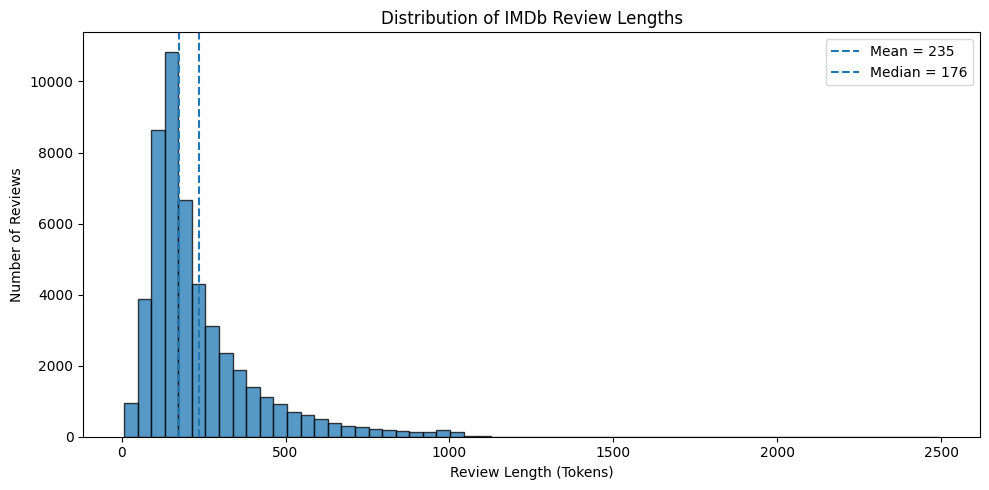

In [12]:
# ============================================================
# REVIEW LENGTH DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    all_lengths,
    bins=60,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    all_lengths.mean(),
    linestyle="--",
    label=f"Mean = {all_lengths.mean():.0f}"
)

plt.axvline(
    np.median(all_lengths),
    linestyle="--",
    label=f"Median = {np.median(all_lengths):.0f}"
)

plt.title("Distribution of IMDb Review Lengths")
plt.xlabel("Review Length (Tokens)")
plt.ylabel("Number of Reviews")

plt.legend()
plt.tight_layout()
plt.show()

### Observation — Review Length Distribution

The review-length analysis reveals substantial variation in the size of the IMDb movie reviews.

The reviews contain an average of approximately **234.76 tokens**, while the median length is **176 tokens**. Since the mean is noticeably higher than the median, the distribution is **positively (right) skewed**, which is also clearly visible in the histogram. Most reviews are concentrated within the shorter-length region, while a smaller number of considerably longer reviews form an extended right tail.

Review lengths range from only **7 tokens** to a maximum of **2,494 tokens**, demonstrating that the dataset contains both very short and exceptionally long reviews.

The percentile analysis provides a clearer view of this variation:

- **75%** of reviews contain approximately **285 tokens or fewer**.
- **80%** contain approximately **325 tokens or fewer**.
- **90%** contain approximately **457 tokens or fewer**.
- **95%** contain approximately **598 tokens or fewer**.
- **97.5%** contain approximately **741 tokens or fewer**.
- **99%** contain approximately **914 tokens or fewer**.

The large difference between the maximum length and the upper percentiles indicates that extremely long reviews are relatively uncommon and represent the tail of the distribution rather than the typical review length.

These findings are particularly important for the later neural-network stage, where sequences must be padded or truncated to a consistent length. However, a final `MAX_SEQUENCE_LENGTH` will **not be selected at this stage**. Text cleaning and tokenization may alter the effective sequence lengths, so the length distribution will be reassessed after preprocessing.

The final sequence length will therefore be selected using the **post-preprocessing distribution**, balancing information retention against unnecessary padding, truncation, memory usage, and computational cost.

# 6. Text Preprocessing and Cleaning

## 6.1 Preprocessing Strategy

Raw textual data often contains elements that do not directly contribute to sentiment classification and may unnecessarily increase vocabulary complexity.

The decoded IMDb reviews contain several artifacts introduced by the dataset representation, including special tokens such as `<START>` and `<UNK>`, as well as HTML line-break artifacts represented as `br`.

A controlled preprocessing pipeline will therefore be applied to improve text consistency while preserving sentiment-related information.

### Preprocessing Steps

The cleaning pipeline will:

1. Convert text to lowercase.
2. Remove Keras-specific special tokens such as `<START>`, `<UNK>`, `<PAD>`, and `<UNUSED>`.
3. Remove HTML line-break artifacts such as `br`.
4. Remove URLs if present.
5. Remove unwanted punctuation, numeric characters, and non-alphabetic symbols while preserving apostrophes used in contractions.symbols.
6. Normalize repeated whitespace.
7. Remove leading and trailing whitespace.

### Why is aggressive preprocessing avoided?

Sentiment classification depends heavily on linguistic structure and polarity-bearing expressions.

For example:

- `not good`
- `never enjoyable`
- `didn't like`
- `would not recommend`

contain important negation information.

For this reason, **stopword removal is not applied at this stage**, since common stopword lists may remove important negation terms such as `not`, `no`, and `never`.

Similarly, stemming and lemmatization are not applied automatically. Although they can reduce vocabulary size, they may also modify useful linguistic information and are not required for the core assignment.

The objective is therefore to remove clear textual noise while preserving as much sentiment-bearing information as possible.

In [13]:
# ============================================================
# TEXT PREPROCESSING FUNCTION
# ============================================================

def clean_review(text):
    """
    Clean an IMDb review while preserving sentiment-related
    linguistic information.
    """

    # Convert input to string for robustness
    text = str(text)

    # Convert text to lowercase
    text = text.lower()

    # Remove Keras-specific special tokens
    text = re.sub(
        r"<(?:start|unk|pad|unused)>",
        " ",
        text
    )

    # Remove HTML line-break tags if present
    text = re.sub(
        r"<br\s*/?>",
        " ",
        text
    )

    # Remove decoded IMDb 'br' artifacts
    text = re.sub(
        r"\bbr\b",
        " ",
        text
    )

    # Remove URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )

    # Keep alphabetic characters and apostrophes
    text = re.sub(
        r"[^a-zA-Z\s']",
        " ",
        text
    )

    # Normalize repeated whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

## 6.2 Applying the Cleaning Pipeline

The preprocessing function is now applied to both the training and testing reviews.

The cleaned text is stored in a **new column** rather than replacing the original decoded review. This preserves both representations and allows direct comparison between the text before and after preprocessing.

Maintaining the original text is also useful for later error analysis, where model predictions can be interpreted using the readable review rather than only its processed representation.

In [14]:
# ============================================================
# APPLY TEXT PREPROCESSING
# ============================================================

# Apply cleaning to the training reviews
train_df["cleaned_review"] = train_df["review"].apply(clean_review)

# Apply cleaning to the testing reviews
test_df["cleaned_review"] = test_df["review"].apply(clean_review)


# Confirm preprocessing completion
print("=" * 60)
print("TEXT PREPROCESSING COMPLETED")
print("=" * 60)

print(f"Training reviews processed : {len(train_df):,}")
print(f"Testing reviews processed  : {len(test_df):,}")

print("\nMissing cleaned reviews:")
print(f"Training : {train_df['cleaned_review'].isnull().sum()}")
print(f"Testing  : {test_df['cleaned_review'].isnull().sum()}")

print("\nEmpty cleaned reviews:")
print(f"Training : {(train_df['cleaned_review'].str.len() == 0).sum()}")
print(f"Testing  : {(test_df['cleaned_review'].str.len() == 0).sum()}")

print("=" * 60)

TEXT PREPROCESSING COMPLETED
Training reviews processed : 25,000
Testing reviews processed  : 25,000

Missing cleaned reviews:
Training : 0
Testing  : 0

Empty cleaned reviews:
Training : 0
Testing  : 0


## 6.3 Before-and-After Preprocessing Comparison

To verify the effect of the cleaning pipeline, the **same 10 reviews inspected before preprocessing** are displayed again after cleaning.

Using identical examples makes it possible to directly evaluate whether:

- dataset-specific artifacts were removed,
- unnecessary textual noise was reduced,
- the original meaning remained understandable, and
- important sentiment-bearing expressions were preserved.

This qualitative comparison complements the quantitative analysis performed later.

In [15]:
# ============================================================
# BEFORE VS AFTER PREPROCESSING
# ============================================================

# Use exactly the same 10 reviews inspected previously
sample_indices = sample_reviews.index

for sample_number, index in enumerate(sample_indices, start=1):

    print("=" * 90)
    print(f"REVIEW {sample_number} — BEFORE VS AFTER PREPROCESSING")
    print("=" * 90)

    print(f"Dataset Index : {index}")
    print(f"Sentiment     : {train_df.loc[index, 'sentiment_label']}")

    print("\nBEFORE:")
    print(train_df.loc[index, "review"])

    print("\nAFTER:")
    print(train_df.loc[index, "cleaned_review"])

    print()

REVIEW 1 — BEFORE VS AFTER PREPROCESSING
Dataset Index : 6868
Sentiment     : Negative

BEFORE:
<START> there's a major difference between releasing an original intense edge of your seat scary gore fest and doing like filmmaker eli roth and his team have done with cabin fever and simply acted like it the film follows five college graduates into a cabin in the woods that begins to prove fatal as one after the other succumbs to this mysterious fast acting flesh eating disease it's not long before the friends turn on one another and can barely stand the sight of one another much less want to be in the same <UNK> as them as gross as it all sounds there's a certain spark behind the basic premise of this film that could have worked in the hands of a less cocky filmmaker unfortunately what we end up with is poorly drawn characters whose sole purpose seems to be to look beautiful at the beginning to make the inevitable <UNK> more contrasting a hackneyed script so profanity laden as to leave th

## 6.4 Quantitative Before-vs-After Length Analysis

After qualitatively comparing the same reviews before and after preprocessing, the next step is to measure how much the cleaning pipeline changed review lengths across the complete dataset.

This quantitative comparison helps determine whether the preprocessing pipeline removed unnecessary textual noise without excessively reducing the amount of useful information.

The analysis compares:

- Mean review length
- Median review length
- Minimum review length
- Maximum review length

The original review lengths are calculated from the Keras integer sequences, while the cleaned review lengths are calculated from the processed text using whitespace-separated tokens.

In [16]:
# ============================================================
# BEFORE VS AFTER REVIEW LENGTH ANALYSIS
# ============================================================

# Calculate original review lengths from the Keras sequences
train_df["original_length"] = [
    len(review) for review in X_train_raw
]

test_df["original_length"] = [
    len(review) for review in X_test_raw
]


# Calculate cleaned review lengths
train_df["cleaned_length"] = (
    train_df["cleaned_review"]
    .str.split()
    .str.len()
)

test_df["cleaned_length"] = (
    test_df["cleaned_review"]
    .str.split()
    .str.len()
)


# Combine training and testing lengths
original_lengths = pd.concat(
    [
        train_df["original_length"],
        test_df["original_length"]
    ],
    ignore_index=True
)

cleaned_lengths = pd.concat(
    [
        train_df["cleaned_length"],
        test_df["cleaned_length"]
    ],
    ignore_index=True
)


# Create a summary comparison table
length_comparison = pd.DataFrame(
    {
        "Before Preprocessing": [
            original_lengths.mean(),
            original_lengths.median(),
            original_lengths.min(),
            original_lengths.max()
        ],

        "After Preprocessing": [
            cleaned_lengths.mean(),
            cleaned_lengths.median(),
            cleaned_lengths.min(),
            cleaned_lengths.max()
        ]
    },

    index=[
        "Mean Length",
        "Median Length",
        "Minimum Length",
        "Maximum Length"
    ]
)


print("=" * 65)
print("REVIEW LENGTH — BEFORE VS AFTER PREPROCESSING")
print("=" * 65)

display(length_comparison.round(2))

REVIEW LENGTH — BEFORE VS AFTER PREPROCESSING


,Before Preprocessing,After Preprocessing
Mean Length,234.76,222.41
Median Length,176.00,168.00
Minimum Length,7.00,6.00
Maximum Length,2494.00,2322.00


## 6.5 Cleaned Review Length Distribution

After preprocessing, review lengths are analyzed again to understand the effective sequence sizes that will later be used for neural-network preparation.

Percentile analysis is particularly useful because the maximum review length can be influenced by a small number of unusually long reviews.

Examining multiple percentiles provides a more reliable basis for selecting the final sequence length used for padding and truncation.

The final `MAX_SEQUENCE_LENGTH` will be selected only after reviewing these post-preprocessing statistics.

In [17]:
# ============================================================
# CLEANED REVIEW LENGTH STATISTICS
# ============================================================

print("=" * 65)
print("CLEANED REVIEW LENGTH STATISTICS")
print("=" * 65)

print(f"Minimum review length : {cleaned_lengths.min():,} tokens")
print(f"Average review length : {cleaned_lengths.mean():.2f} tokens")
print(f"Median review length  : {cleaned_lengths.median():.2f} tokens")
print(f"Maximum review length : {cleaned_lengths.max():,} tokens")

print("\nCleaned Review Length Percentiles")

for percentile in [75, 80, 90, 95, 97.5, 99]:

    percentile_value = np.percentile(
        cleaned_lengths,
        percentile
    )

    print(
        f"{percentile:>4}% percentile : "
        f"{percentile_value:.0f} tokens"
    )

print("=" * 65)

CLEANED REVIEW LENGTH STATISTICS
Minimum review length : 6 tokens
Average review length : 222.41 tokens
Median review length  : 168.00 tokens
Maximum review length : 2,322 tokens

Cleaned Review Length Percentiles
  75% percentile : 269 tokens
  80% percentile : 307 tokens
  90% percentile : 432 tokens
  95% percentile : 565 tokens
97.5% percentile : 700 tokens
  99% percentile : 868 tokens


### Observation — Effect of Text Preprocessing on Review Length

The preprocessing pipeline successfully cleaned all **50,000 IMDb reviews** without producing any missing or empty documents.

A comparison of review lengths before and after preprocessing shows a moderate reduction in sequence size. The average review length decreased from **234.76 tokens to 222.41 tokens**, while the median decreased from **176 to 168 tokens**.

The maximum review length also decreased from **2,494 to 2,322 tokens**, indicating that the preprocessing process removed a measurable amount of dataset-specific noise and unnecessary textual artifacts while preserving most of the original review content.

The cleaned review-length distribution remains positively skewed. Most reviews are considerably shorter than the longest observations, with:

- **75%** of cleaned reviews containing **269 tokens or fewer**
- **80%** containing **307 tokens or fewer**
- **90%** containing **432 tokens or fewer**
- **95%** containing **565 tokens or fewer**
- **97.5%** containing **700 tokens or fewer**
- **99%** containing **868 tokens or fewer**

The relatively small reduction in the mean and median lengths suggests that the cleaning strategy was appropriately conservative. It removed artifacts such as dataset-specific special tokens and unnecessary formatting without aggressively shortening the reviews or discarding substantial textual information.

The qualitative before-and-after inspection also showed that sentiment-bearing expressions and negation structures were preserved.

At this stage, the cleaned text is ready for tokenization. The final sequence length for the neural models will be selected after converting the cleaned reviews into token sequences, ensuring that the padding and truncation decision is based on the actual representation used by the models.

## 6.6 Text Tokenization

After cleaning the reviews, the text must be converted into a numerical representation before it can be processed by neural-network models.

A Keras `Tokenizer` is used to construct a vocabulary and map each word to a unique integer index.

To prevent data leakage, the tokenizer is fitted **only on the training reviews**. The learned vocabulary is then used to transform both the training and testing reviews.

This ensures that information from the test set does not influence vocabulary construction.

The tokenizer will:

- learn word frequencies from the training corpus,
- retain the most frequent vocabulary terms,
- assign each retained word a unique integer index,
- represent unknown or unseen words using an out-of-vocabulary token, and
- convert each review into an integer sequence.

The integer sequences will later be padded or truncated to a consistent length for use by the RNN, LSTM, GRU, and BiLSTM models.

In [18]:
# ============================================================
# TEXT TOKENIZATION
# ============================================================

# Maximum vocabulary size
MAX_VOCAB_SIZE = 20000


# Create the tokenizer
tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token="<OOV>"
)


# Fit the tokenizer ONLY on the training data
tokenizer.fit_on_texts(
    train_df["cleaned_review"]
)


# Convert cleaned reviews into integer sequences
X_train_sequences = tokenizer.texts_to_sequences(
    train_df["cleaned_review"]
)

X_test_sequences = tokenizer.texts_to_sequences(
    test_df["cleaned_review"]
)


# Extract the learned word-index mapping
word_index = tokenizer.word_index


print("=" * 65)
print("TOKENIZATION SUMMARY")
print("=" * 65)

print(f"Maximum vocabulary size       : {MAX_VOCAB_SIZE:,}")
print(f"Unique words learned           : {len(word_index):,}")
print(f"Training sequences generated   : {len(X_train_sequences):,}")
print(f"Testing sequences generated    : {len(X_test_sequences):,}")

print("\nFirst 15 learned word mappings:")

for word, index in list(word_index.items())[:15]:
    print(f"{word:<15} -> {index}")

print("=" * 65)

TOKENIZATION SUMMARY
Maximum vocabulary size       : 20,000
Unique words learned           : 19,678
Training sequences generated   : 25,000
Testing sequences generated    : 25,000

First 15 learned word mappings:
<OOV>           -> 1
the             -> 2
and             -> 3
a               -> 4
of              -> 5
to              -> 6
is              -> 7
in              -> 8
it              -> 9
i               -> 10
this            -> 11
that            -> 12
was             -> 13
as              -> 14
for             -> 15


## 6.7 Inspecting the Tokenized Representation

To verify the tokenization process, two cleaned reviews are examined together with their corresponding integer sequences.

Each integer represents a word according to the vocabulary learned exclusively from the training corpus.

This step confirms that the textual reviews have been successfully transformed into the numerical representation required by neural-network models.

In [19]:
# ============================================================
# TOKENIZED REVIEW EXAMPLES
# ============================================================

for sample_number, index in enumerate(sample_indices[:4], start=1):

    sequence = tokenizer.texts_to_sequences(
        [train_df.loc[index, "cleaned_review"]]
    )[0]

    print("=" * 85)
    print(f"TOKENIZED REVIEW {sample_number}")
    print("=" * 85)

    print(f"Dataset Index : {index}")
    print(f"Sentiment     : {train_df.loc[index, 'sentiment_label']}")

    print("\nCleaned Review:")
    print(train_df.loc[index, "cleaned_review"])

    print("\nFirst 50 Integer Tokens:")
    print(sequence[:50])

    print(f"\nComplete Sequence Length: {len(sequence)} tokens")

    print()

TOKENIZED REVIEW 1
Dataset Index : 6868
Sentiment     : Negative

Cleaned Review:
there's a major difference between releasing an original intense edge of your seat scary gore fest and doing like filmmaker eli roth and his team have done with cabin fever and simply acted like it the film follows five college graduates into a cabin in the woods that begins to prove fatal as one after the other succumbs to this mysterious fast acting flesh eating disease it's not long before the friends turn on one another and can barely stand the sight of one another much less want to be in the same as them as gross as it all sounds there's a certain spark behind the basic premise of this film that could have worked in the hands of a less cocky filmmaker unfortunately what we end up with is poorly drawn characters whose sole purpose seems to be to look beautiful at the beginning to make the inevitable more contrasting a hackneyed script so profanity laden as to leave the viewer tuning out the dialogue a

## 6.8 Tokenized Sequence-Length Analysis

Sequence lengths are examined again after applying the neural-network tokenizer.

This is the most relevant length distribution for selecting the final `MAX_SEQUENCE_LENGTH`, because these integer sequences are the actual inputs that will be supplied to the neural models.

The objective is to retain the majority of review information while preventing unusually long reviews from creating excessive padding and unnecessary computational cost.

In [20]:
# ============================================================
# TOKENIZED SEQUENCE LENGTH ANALYSIS
# ============================================================

train_sequence_lengths = np.array([
    len(sequence)
    for sequence in X_train_sequences
])

test_sequence_lengths = np.array([
    len(sequence)
    for sequence in X_test_sequences
])

all_sequence_lengths = np.concatenate([
    train_sequence_lengths,
    test_sequence_lengths
])


print("=" * 65)
print("TOKENIZED SEQUENCE LENGTH STATISTICS")
print("=" * 65)

print(
    f"Minimum sequence length : "
    f"{all_sequence_lengths.min():,} tokens"
)

print(
    f"Average sequence length : "
    f"{all_sequence_lengths.mean():.2f} tokens"
)

print(
    f"Median sequence length  : "
    f"{np.median(all_sequence_lengths):.2f} tokens"
)

print(
    f"Maximum sequence length : "
    f"{all_sequence_lengths.max():,} tokens"
)


print("\nTokenized Sequence Length Percentiles")

for percentile in [75, 80, 90, 95, 97.5, 99]:

    percentile_value = np.percentile(
        all_sequence_lengths,
        percentile
    )

    print(
        f"{percentile:>4}% percentile : "
        f"{percentile_value:.0f} tokens"
    )

print("=" * 65)

TOKENIZED SEQUENCE LENGTH STATISTICS
Minimum sequence length : 6 tokens
Average sequence length : 222.41 tokens
Median sequence length  : 168.00 tokens
Maximum sequence length : 2,322 tokens

Tokenized Sequence Length Percentiles
  75% percentile : 269 tokens
  80% percentile : 307 tokens
  90% percentile : 432 tokens
  95% percentile : 565 tokens
97.5% percentile : 700 tokens
  99% percentile : 868 tokens


### Observation — Tokenization and Sequence-Length Analysis

The cleaned IMDb reviews were successfully converted into integer sequences using a tokenizer fitted exclusively on the training data.

The tokenizer learned **19,678 unique words** from the training corpus while using a maximum vocabulary limit of **20,000 tokens**. An `<OOV>` token was also included to provide a consistent representation for words that may not be available in the retained vocabulary.

A total of **25,000 training sequences** and **25,000 testing sequences** were generated successfully. The inspected tokenized examples confirm that cleaned textual reviews are correctly mapped into ordered integer sequences while preserving their original word order.

Four reviews were inspected as representative examples, exceeding the assignment requirement of displaying tokenized representations for at least two reviews. The examples also demonstrate the natural variability in review length, with inspected sequences ranging from relatively short reviews to substantially longer ones.

The tokenized sequence-length analysis produced an average length of **222.41 tokens** and a median of **168 tokens**. The distribution remains strongly right-skewed, with a maximum sequence length of **2,322 tokens**.

The percentile analysis shows that:

- **75%** of reviews contain no more than **269 tokens**.
- **80%** contain no more than **307 tokens**.
- **90%** contain no more than **432 tokens**.
- **95%** contain no more than **565 tokens**.
- **97.5%** contain no more than **700 tokens**.
- **99%** contain no more than **868 tokens**.

These results confirm that using the maximum observed length of 2,322 tokens would introduce substantial unnecessary padding for the majority of reviews. Therefore, a smaller fixed sequence length should be selected to balance information retention and computational efficiency before training the neural models.

## 6.9 Selecting the Maximum Sequence Length

Neural-network models require input sequences to have a consistent length. Therefore, a fixed maximum sequence length must be selected before applying padding and truncation.

The observed distribution shows that the majority of reviews are considerably shorter than the maximum sequence length of 2,322 tokens. Using the absolute maximum would therefore create excessive padding and unnecessarily increase memory usage and training time.

Based on the observed percentiles, a candidate sequence length of **500 tokens** is selected.

This value lies between the 90th percentile (432 tokens) and the 95th percentile (565 tokens), providing a practical balance between:

- preserving most review content,
- limiting truncation of longer reviews,
- reducing unnecessary padding, and
- controlling the computational cost of recurrent neural networks.

The exact proportion of reviews fully preserved and truncated at this threshold is calculated below before the final padding operation is performed.

In [21]:
# ============================================================
# MAXIMUM SEQUENCE LENGTH SELECTION
# ============================================================

MAX_SEQUENCE_LENGTH = 500

# Count sequences that fit completely within the selected length
fully_preserved = np.sum(
    all_sequence_lengths <= MAX_SEQUENCE_LENGTH
)

# Count sequences that will require truncation
truncated = np.sum(
    all_sequence_lengths > MAX_SEQUENCE_LENGTH
)

# Calculate percentages
fully_preserved_percentage = (
    fully_preserved / len(all_sequence_lengths)
) * 100

truncated_percentage = (
    truncated / len(all_sequence_lengths)
) * 100


print("=" * 65)
print("SEQUENCE LENGTH SELECTION")
print("=" * 65)

print(
    f"Selected maximum sequence length : "
    f"{MAX_SEQUENCE_LENGTH} tokens"
)

print(
    f"Reviews fully preserved          : "
    f"{fully_preserved:,} "
    f"({fully_preserved_percentage:.2f}%)"
)

print(
    f"Reviews requiring truncation     : "
    f"{truncated:,} "
    f"({truncated_percentage:.2f}%)"
)

print("=" * 65)

SEQUENCE LENGTH SELECTION
Selected maximum sequence length : 500 tokens
Reviews fully preserved          : 46,496 (92.99%)
Reviews requiring truncation     : 3,504 (7.01%)


### Observation — Final Sequence-Length Selection

A maximum sequence length of **500 tokens** was evaluated against the tokenized IMDb review-length distribution.

The results show that **46,496 reviews (92.99%)** contain 500 tokens or fewer and will therefore be preserved completely. Only **3,504 reviews (7.01%)** exceed the selected threshold and will require truncation.

This represents a strong balance between information retention and computational efficiency. Increasing the sequence length substantially would increase padding, memory consumption, and recurrent-model training cost in order to fully preserve a relatively small proportion of unusually long reviews.

Therefore, `MAX_SEQUENCE_LENGTH = 500` is adopted as the final sequence length for the neural-network experiments.

This value will be applied consistently across the recurrent models to maintain a fair comparison between RNN, LSTM, GRU, and BiLSTM architectures.

## 6.10 Sequence Padding and Truncation

Neural networks process data in batches and therefore require input sequences to have a consistent dimensionality.

Because IMDb reviews naturally contain different numbers of tokens, all tokenized sequences are standardized to the selected maximum length of **500 tokens**.

Two operations are applied:

- **Padding:** Reviews shorter than 500 tokens are extended with zeros.
- **Truncation:** Reviews longer than 500 tokens are limited to 500 tokens.

`post` padding and `post` truncation are used so that the beginning of each review remains in its original position and additional padding is placed at the end.

The same sequence length is applied to both training and testing data to ensure consistent model inputs.

The sentiment variable remains unchanged as the binary target:

- `0` = Negative
- `1` = Positive

The resulting matrices provide the final numerical representation required by the neural-network models.

In [22]:
# ============================================================
# SEQUENCE PADDING AND TRUNCATION
# ============================================================

# Pad and truncate training sequences
X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

# Pad and truncate testing sequences
X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)


# Preserve sentiment labels as the binary target
y_train_neural = train_df["sentiment"].to_numpy()
y_test_neural = test_df["sentiment"].to_numpy()


# Display final dimensions
print("=" * 65)
print("PADDED SEQUENCE SUMMARY")
print("=" * 65)

print(f"Training input shape : {X_train_padded.shape}")
print(f"Testing input shape  : {X_test_padded.shape}")

print(f"\nTraining target shape : {y_train_neural.shape}")
print(f"Testing target shape  : {y_test_neural.shape}")

print(f"\nSequence length        : {X_train_padded.shape[1]}")
print(f"Training input dtype   : {X_train_padded.dtype}")
print(f"Training target dtype  : {y_train_neural.dtype}")

print("\nUnique target values:")
print(np.unique(y_train_neural))

print("=" * 65)

PADDED SEQUENCE SUMMARY
Training input shape : (25000, 500)
Testing input shape  : (25000, 500)

Training target shape : (25000,)
Testing target shape  : (25000,)

Sequence length        : 500
Training input dtype   : int32
Training target dtype  : int64

Unique target values:
[0 1]


## 6.11 Verification of Padding and Truncation

The padded representation is inspected to verify that the sequence-standardization process was performed correctly.

Two cases are examined:

1. A review shorter than 500 tokens, which should receive zero-padding at the end.
2. A review longer than 500 tokens, which should be truncated to exactly 500 tokens.

This verification confirms that the neural-network input matrices have been prepared as intended before model development begins.

In [23]:
# ============================================================
# VERIFY PADDING AND TRUNCATION
# ============================================================

# Find one sequence shorter than the selected maximum length
short_index = next(
    i for i, sequence in enumerate(X_train_sequences)
    if len(sequence) < MAX_SEQUENCE_LENGTH
)

# Find one sequence longer than the selected maximum length
long_index = next(
    i for i, sequence in enumerate(X_train_sequences)
    if len(sequence) > MAX_SEQUENCE_LENGTH
)


print("=" * 65)
print("PADDING VERIFICATION")
print("=" * 65)

print(
    f"Original short sequence length : "
    f"{len(X_train_sequences[short_index])}"
)

print(
    f"Padded sequence length         : "
    f"{len(X_train_padded[short_index])}"
)

print(
    f"Number of padding zeros        : "
    f"{np.sum(X_train_padded[short_index] == 0)}"
)

print("\nLast 20 values of padded sequence:")
print(X_train_padded[short_index][-20:])


print("\n" + "=" * 65)
print("TRUNCATION VERIFICATION")
print("=" * 65)

print(
    f"Original long sequence length  : "
    f"{len(X_train_sequences[long_index])}"
)

print(
    f"Truncated sequence length      : "
    f"{len(X_train_padded[long_index])}"
)

print(
    f"Expected final length          : "
    f"{MAX_SEQUENCE_LENGTH}"
)

print("=" * 65)

PADDING VERIFICATION
Original short sequence length : 214
Padded sequence length         : 500
Number of padding zeros        : 286

Last 20 values of padded sequence:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

TRUNCATION VERIFICATION
Original long sequence length  : 510
Truncated sequence length      : 500
Expected final length          : 500


### Observation — Padding and Truncation Verification

The sequence-standardization process was completed successfully for the complete IMDb dataset.

After padding and truncation, the training input has a shape of **(25,000, 500)** and the testing input has a shape of **(25,000, 500)**. This confirms that every review is now represented by exactly **500 integer tokens**, providing a consistent input dimension for the neural-network models.

The binary sentiment targets were preserved without modification, with training and testing target shapes of **(25,000,)** and the expected class values of **0 (Negative)** and **1 (Positive)**.

The padding verification demonstrated that a review originally containing **214 tokens** was extended to 500 tokens by appending exactly **286 zeros**. Inspection of the final values confirmed that zero-padding was correctly applied at the end of the sequence.

The truncation verification also confirmed the expected behavior. A review originally containing **510 tokens** was reduced to exactly **500 tokens**, matching the selected `MAX_SEQUENCE_LENGTH`.

Combined with the earlier sequence-length analysis, the final configuration preserves **92.99% of reviews without truncation**, while only **7.01%** of reviews require their excess tokens to be removed.

Therefore, the textual data has been successfully cleaned, tokenized, converted into integer sequences, and standardized through padding and truncation. The resulting representation is ready for neural-network modeling.

## 6.12 Preprocessing Summary

The complete preprocessing pipeline has now been successfully implemented.

The IMDb reviews were converted to lowercase, dataset-specific and HTML-related artifacts were removed, unwanted symbols and excessive whitespace were normalized, and sentiment-bearing linguistic information such as negation and contractions was intentionally preserved.

The cleaned reviews were then tokenized using a vocabulary learned exclusively from the training data to prevent information leakage. Review-length analysis was performed before and after preprocessing, and a final sequence length of **500 tokens** was selected based on the observed distribution.

At this threshold, **92.99% of reviews are preserved completely**, while only **7.01% require truncation**. All neural-network inputs were subsequently padded or truncated to exactly 500 tokens.

The sentiment label remains unchanged as the binary prediction target.

Part A is therefore complete, and the dataset is ready for both classical text-representation experiments and neural-network modeling.

# 7. Part B — TF-IDF with Logistic Regression

After completing text preprocessing, the first sentiment-classification experiment uses **TF-IDF (Term Frequency–Inverse Document Frequency)** as a classical text representation combined with **Logistic Regression** as the baseline classifier.

TF-IDF converts each cleaned review into a sparse numerical feature vector. It assigns higher importance to terms that are frequent within a particular document but less common across the overall training corpus.

This representation provides a strong and interpretable classical baseline that can later be compared with Word2Vec and neural-network representations.

To prevent data leakage, the TF-IDF vectorizer is fitted **only on the training data**. The learned vocabulary and IDF statistics are then used to transform the test reviews.

The baseline experiment will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Classification report
- Confusion matrix

Additional TF-IDF configurations will subsequently be evaluated by varying `max_features` and `ngram_range`.

## 7.1 Baseline TF-IDF Representation

A baseline TF-IDF representation is first constructed using unigram features.

The vectorizer is configured with a maximum of **20,000 features**, providing a controlled feature space while maintaining consistency with the vocabulary scale used during neural text preparation.

Only the training reviews are used to fit the TF-IDF vectorizer. The test set is transformed using the vocabulary and inverse-document-frequency statistics learned from the training data.

This separation is essential to prevent test-set information from influencing model training.

In [24]:
# ============================================================
# BASELINE TF-IDF REPRESENTATION
# ============================================================

TFIDF_MAX_FEATURES = 20000

tfidf_baseline = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 1),
    lowercase=False
)

# Fit TF-IDF ONLY on the training reviews
X_train_tfidf = tfidf_baseline.fit_transform(
    train_df["cleaned_review"]
)

# Transform the test reviews using the training vocabulary
X_test_tfidf = tfidf_baseline.transform(
    test_df["cleaned_review"]
)


print("=" * 65)
print("BASELINE TF-IDF REPRESENTATION")
print("=" * 65)

print(f"Maximum requested features : {TFIDF_MAX_FEATURES:,}")
print(f"Actual vocabulary size      : {len(tfidf_baseline.vocabulary_):,}")

print(f"\nTraining TF-IDF shape       : {X_train_tfidf.shape}")
print(f"Testing TF-IDF shape        : {X_test_tfidf.shape}")

print(f"\nTraining matrix type        : {type(X_train_tfidf).__name__}")
print(f"Testing matrix type         : {type(X_test_tfidf).__name__}")

print("=" * 65)

BASELINE TF-IDF REPRESENTATION
Maximum requested features : 20,000
Actual vocabulary size      : 18,936

Training TF-IDF shape       : (25000, 18936)
Testing TF-IDF shape        : (25000, 18936)

Training matrix type        : csr_matrix
Testing matrix type         : csr_matrix


## 7.2 Inspecting the TF-IDF Feature Space

The learned TF-IDF feature space is inspected before model training to verify that the cleaned reviews have been successfully transformed into numerical vectors.

Unlike token sequences, TF-IDF does not preserve word order directly. Instead, each column represents a vocabulary feature, while each row represents a movie review.

Most entries are zero because each individual review contains only a small subset of the complete vocabulary, resulting in a sparse document-term matrix.

In [25]:
# ============================================================
# INSPECT TF-IDF FEATURE SPACE
# ============================================================

tfidf_feature_names = tfidf_baseline.get_feature_names_out()

print("=" * 65)
print("TF-IDF FEATURE SPACE")
print("=" * 65)

print(f"Number of TF-IDF features : {len(tfidf_feature_names):,}")

print("\nFirst 20 features:")
print(tfidf_feature_names[:20])

print("\nLast 20 features:")
print(tfidf_feature_names[-20:])

print("=" * 65)

TF-IDF FEATURE SPACE
Number of TF-IDF features : 18,936

First 20 features:
['aag' 'aames' 'aaron' 'ab' 'abandon' 'abandoned' 'abandoning'
 'abandonment' 'abandons' 'abbas' 'abbey' 'abbot' 'abbott' 'abby' 'abc'
 'abducted' 'abduction' 'abe' 'abetted' 'abhay']

Last 20 features:
['zillion' 'zion' 'zip' 'ziyi' 'zizek' 'zodiac' 'zoe' 'zombi' 'zombie'
 'zombies' 'zone' 'zoo' 'zoom' 'zooms' 'zorro' 'zp' 'zu' 'zucker' 'zulu'
 'zuniga']


## 7.3 Logistic Regression Baseline

Logistic Regression is trained on the baseline TF-IDF representation to establish the first sentiment-classification benchmark.

Logistic Regression is well suited to high-dimensional sparse text representations such as TF-IDF and provides a strong classical baseline for binary sentiment classification.

The model is trained exclusively on the training TF-IDF matrix and evaluated on the untouched official IMDb test set.

A fixed random state is used where applicable to support reproducibility.

In [26]:
# ============================================================
# TRAIN LOGISTIC REGRESSION BASELINE
# ============================================================

lr_baseline = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train the classifier
lr_baseline.fit(
    X_train_tfidf,
    y_train
)

# Generate predictions
y_pred_tfidf_baseline = lr_baseline.predict(
    X_test_tfidf
)

print("=" * 65)
print("LOGISTIC REGRESSION BASELINE")
print("=" * 65)
print("Model training completed successfully.")
print(f"Training samples : {X_train_tfidf.shape[0]:,}")
print(f"Testing samples  : {X_test_tfidf.shape[0]:,}")
print("=" * 65)

LOGISTIC REGRESSION BASELINE
Model training completed successfully.
Training samples : 25,000
Testing samples  : 25,000


## 7.4 Baseline Model Evaluation

The TF-IDF + Logistic Regression baseline is evaluated on the official IMDb test set.

Because the dataset is balanced between positive and negative sentiment classes, accuracy provides a useful overall performance measure. However, precision, recall, and F1-score are also reported to provide a more complete assessment of classification performance.

For binary evaluation, the positive sentiment class (`1`) is treated as the positive class.

In [27]:
# ============================================================
# BASELINE PERFORMANCE METRICS
# ============================================================

baseline_accuracy = accuracy_score(
    y_test,
    y_pred_tfidf_baseline
)

baseline_precision = precision_score(
    y_test,
    y_pred_tfidf_baseline
)

baseline_recall = recall_score(
    y_test,
    y_pred_tfidf_baseline
)

baseline_f1 = f1_score(
    y_test,
    y_pred_tfidf_baseline
)


print("=" * 65)
print("TF-IDF + LOGISTIC REGRESSION — TEST PERFORMANCE")
print("=" * 65)

print(f"Accuracy  : {baseline_accuracy:.4f}")
print(f"Precision : {baseline_precision:.4f}")
print(f"Recall    : {baseline_recall:.4f}")
print(f"F1-score  : {baseline_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tfidf_baseline,
        target_names=["Negative", "Positive"],
        digits=4
    )
)

print("=" * 65)

TF-IDF + LOGISTIC REGRESSION — TEST PERFORMANCE
Accuracy  : 0.8845
Precision : 0.8850
Recall    : 0.8838
F1-score  : 0.8844

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8840    0.8851    0.8846     12500
    Positive     0.8850    0.8838    0.8844     12500

    accuracy                         0.8845     25000
   macro avg     0.8845    0.8845    0.8845     25000
weighted avg     0.8845    0.8845    0.8845     25000



## 7.5 Confusion Matrix

The confusion matrix provides a class-level view of the baseline model's predictions.

It separates predictions into:

- **True Negatives (TN):** Negative reviews correctly classified as negative.
- **False Positives (FP):** Negative reviews incorrectly classified as positive.
- **False Negatives (FN):** Positive reviews incorrectly classified as negative.
- **True Positives (TP):** Positive reviews correctly classified as positive.

This analysis helps determine whether the classifier makes substantially more errors for one sentiment class than the other.

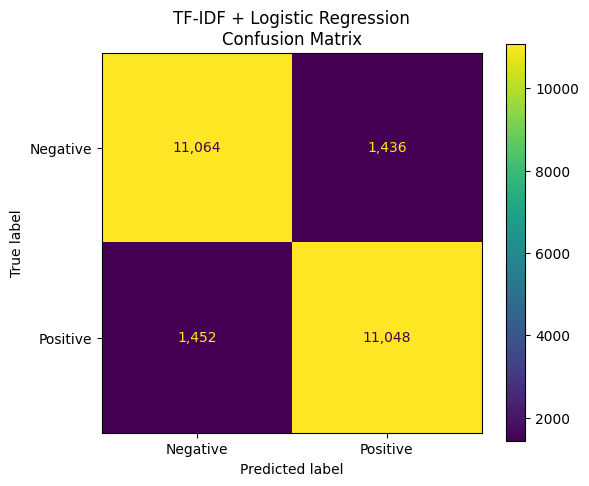

CONFUSION MATRIX VALUES
True Negatives  (TN) : 11,064
False Positives (FP) : 1,436
False Negatives (FN) : 1,452
True Positives  (TP) : 11,048


In [28]:
# ============================================================
# BASELINE CONFUSION MATRIX
# ============================================================

baseline_cm = confusion_matrix(
    y_test,
    y_pred_tfidf_baseline
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=["Negative", "Positive"]
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(
    ax=ax,
    values_format=",d"
)

ax.set_title(
    "TF-IDF + Logistic Regression\nConfusion Matrix"
)

plt.tight_layout()
plt.show()


# Print matrix values explicitly
tn, fp, fn, tp = baseline_cm.ravel()

print("=" * 65)
print("CONFUSION MATRIX VALUES")
print("=" * 65)

print(f"True Negatives  (TN) : {tn:,}")
print(f"False Positives (FP) : {fp:,}")
print(f"False Negatives (FN) : {fn:,}")
print(f"True Positives  (TP) : {tp:,}")

print("=" * 65)

### Observation — TF-IDF + Logistic Regression Baseline

The TF-IDF representation successfully transformed the cleaned IMDb reviews into a high-dimensional sparse feature space containing **18,936 features**. The resulting training and testing matrices have shapes of **(25,000, 18,936)** and are stored as sparse CSR matrices, which is computationally appropriate because each review contains only a small subset of the complete vocabulary.

The Logistic Regression baseline achieved strong and well-balanced performance on the official IMDb test set:

- **Accuracy:** 0.8845
- **Precision:** 0.8850
- **Recall:** 0.8838
- **F1-score:** 0.8844

The similarity between accuracy, precision, recall, and F1-score indicates that the classifier performs consistently rather than optimizing one aspect of classification at the expense of another.

Class-level results are also highly balanced. The model achieved an F1-score of **0.8846 for Negative reviews** and **0.8844 for Positive reviews**, with nearly identical performance across both sentiment classes.

The confusion matrix further confirms this behavior. The classifier correctly identified **11,064 Negative reviews** and **11,048 Positive reviews**. It incorrectly classified **1,436 Negative reviews as Positive** and **1,452 Positive reviews as Negative**. The difference between the two error types is only 16 reviews, indicating no meaningful directional bias toward either sentiment class.

Overall, TF-IDF combined with Logistic Regression provides a strong classical baseline for this project. However, this result represents only the initial configuration. Additional TF-IDF configurations will now be evaluated systematically to determine whether changes in vocabulary size and n-gram representation can improve sentiment classification performance.

## 7.6 TF-IDF Hyperparameter Experiments

The baseline experiment established the initial performance of TF-IDF with Logistic Regression. The next step investigates whether alternative TF-IDF configurations can improve the representation.

Two important TF-IDF parameters are evaluated:

- **`max_features`** controls the maximum size of the retained vocabulary.
- **`ngram_range`** determines whether the representation includes individual words only or also captures adjacent word combinations.

To avoid selecting hyperparameters based on the test set, the official training set is divided into development-training and validation subsets.

The validation subset is used exclusively for configuration comparison, while the official IMDb test set remains untouched during model selection.

A stratified split is used to preserve the balanced sentiment distribution.

In [29]:
# ============================================================
# DEVELOPMENT TRAIN–VALIDATION SPLIT
# ============================================================

X_dev_train, X_validation, y_dev_train, y_validation = train_test_split(
    train_df["cleaned_review"],
    train_df["sentiment"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_df["sentiment"]
)

print("=" * 65)
print("DEVELOPMENT TRAIN–VALIDATION SPLIT")
print("=" * 65)

print(f"Development training samples : {len(X_dev_train):,}")
print(f"Validation samples           : {len(X_validation):,}")

print("\nDevelopment Training Distribution:")
print(
    y_dev_train.value_counts()
    .sort_index()
    .rename(index={0: "Negative", 1: "Positive"})
)

print("\nValidation Distribution:")
print(
    y_validation.value_counts()
    .sort_index()
    .rename(index={0: "Negative", 1: "Positive"})
)

print("=" * 65)

DEVELOPMENT TRAIN–VALIDATION SPLIT
Development training samples : 20,000
Validation samples           : 5,000

Development Training Distribution:
sentiment
Negative    10000
Positive    10000
Name: count, dtype: int64

Validation Distribution:
sentiment
Negative    2500
Positive    2500
Name: count, dtype: int64


### 7.6.2 Systematic TF-IDF Configuration Comparison

Six TF-IDF configurations are evaluated by combining three vocabulary limits with two n-gram settings.

The experiments include:

| Configuration | Maximum Features | N-gram Range |
|---|---:|---|
| 1 | 10,000 | Unigrams |
| 2 | 20,000 | Unigrams |
| 3 | 30,000 | Unigrams |
| 4 | 10,000 | Unigrams + Bigrams |
| 5 | 20,000 | Unigrams + Bigrams |
| 6 | 30,000 | Unigrams + Bigrams |

For every configuration, the TF-IDF vectorizer is fitted only on the development-training subset. Logistic Regression is then trained on the resulting representation and evaluated on the validation subset.

Accuracy, precision, recall, and F1-score are recorded for each experiment.

The configuration with the highest validation F1-score will be selected for final training and test-set evaluation.

In [30]:
# ============================================================
# SYSTEMATIC TF-IDF CONFIGURATION EXPERIMENTS
# ============================================================

tfidf_experiments = [
    {"max_features": 10000, "ngram_range": (1, 1)},
    {"max_features": 20000, "ngram_range": (1, 1)},
    {"max_features": 30000, "ngram_range": (1, 1)},
    {"max_features": 10000, "ngram_range": (1, 2)},
    {"max_features": 20000, "ngram_range": (1, 2)},
    {"max_features": 30000, "ngram_range": (1, 2)}
]

experiment_results = []


for experiment_number, config in enumerate(
    tfidf_experiments,
    start=1
):

    print(
        f"Running Experiment {experiment_number}/"
        f"{len(tfidf_experiments)}..."
    )

    # Create TF-IDF vectorizer
    vectorizer = TfidfVectorizer(
        max_features=config["max_features"],
        ngram_range=config["ngram_range"],
        lowercase=False
    )

    # Fit ONLY on development-training data
    X_dev_train_tfidf = vectorizer.fit_transform(
        X_dev_train
    )

    # Transform validation data
    X_validation_tfidf = vectorizer.transform(
        X_validation
    )

    # Train Logistic Regression
    model = LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    )

    model.fit(
        X_dev_train_tfidf,
        y_dev_train
    )

    # Validation predictions
    y_validation_pred = model.predict(
        X_validation_tfidf
    )

    # Store results
    experiment_results.append({
        "Experiment": experiment_number,
        "Max Features": config["max_features"],
        "N-gram Range": str(config["ngram_range"]),
        "Actual Features": len(vectorizer.vocabulary_),
        "Accuracy": accuracy_score(
            y_validation,
            y_validation_pred
        ),
        "Precision": precision_score(
            y_validation,
            y_validation_pred
        ),
        "Recall": recall_score(
            y_validation,
            y_validation_pred
        ),
        "F1-score": f1_score(
            y_validation,
            y_validation_pred
        )
    })


tfidf_results_df = pd.DataFrame(
    experiment_results
)

print("\n" + "=" * 85)
print("TF-IDF CONFIGURATION EXPERIMENT RESULTS")
print("=" * 85)

display(
    tfidf_results_df.round(4)
)

Running Experiment 1/6...
Running Experiment 2/6...
Running Experiment 3/6...
Running Experiment 4/6...
Running Experiment 5/6...
Running Experiment 6/6...

TF-IDF CONFIGURATION EXPERIMENT RESULTS


,Experiment,Max Features,N-gram Range,Actual Features,Accuracy,Precision,Recall,F1-score
0,1,10000,"(1, 1)",10000,0.8814,0.8697,0.8972,0.8832
1,2,20000,"(1, 1)",18935,0.8830,0.8724,0.8972,0.8846
2,3,30000,"(1, 1)",18935,0.8830,0.8724,0.8972,0.8846
3,4,10000,"(1, 2)",10000,0.8824,0.8691,0.9004,0.8845
4,5,20000,"(1, 2)",20000,0.8858,0.8714,0.9052,0.8880
5,6,30000,"(1, 2)",30000,0.8874,0.8741,0.9052,0.8894


### 7.6.3 Best TF-IDF Configuration Selection

The TF-IDF configurations are ranked according to their validation F1-score.

F1-score is used as the primary selection metric because it jointly considers precision and recall. Accuracy is retained as an additional performance indicator.

The best-performing configuration will subsequently be fitted on the complete official training set before performing a single final evaluation on the official test set.

In [31]:
# ============================================================
# SELECT BEST TF-IDF CONFIGURATION
# ============================================================

best_tfidf_index = (
    tfidf_results_df["F1-score"].idxmax()
)

best_tfidf_result = (
    tfidf_results_df.loc[best_tfidf_index]
)

best_max_features = int(
    best_tfidf_result["Max Features"]
)

best_ngram_range = (
    tfidf_experiments[
        int(best_tfidf_result["Experiment"]) - 1
    ]["ngram_range"]
)


print("=" * 65)
print("BEST TF-IDF CONFIGURATION")
print("=" * 65)

print(
    f"Experiment        : "
    f"{int(best_tfidf_result['Experiment'])}"
)

print(
    f"Max Features      : "
    f"{best_max_features:,}"
)

print(
    f"N-gram Range      : "
    f"{best_ngram_range}"
)

print(
    f"Validation Accuracy : "
    f"{best_tfidf_result['Accuracy']:.4f}"
)

print(
    f"Validation Precision: "
    f"{best_tfidf_result['Precision']:.4f}"
)

print(
    f"Validation Recall   : "
    f"{best_tfidf_result['Recall']:.4f}"
)

print(
    f"Validation F1-score : "
    f"{best_tfidf_result['F1-score']:.4f}"
)

print("=" * 65)

BEST TF-IDF CONFIGURATION
Experiment        : 6
Max Features      : 30,000
N-gram Range      : (1, 2)
Validation Accuracy : 0.8874
Validation Precision: 0.8741
Validation Recall   : 0.9052
Validation F1-score : 0.8894


### Observation — TF-IDF Configuration Experiments

The TF-IDF configuration experiments demonstrate that both vocabulary size and n-gram representation influence sentiment-classification performance.

The stratified development split successfully preserved the original class balance, producing **20,000 development-training reviews** and **5,000 validation reviews**, with an equal number of Positive and Negative examples in both subsets.

For unigram-only representations, increasing `max_features` from **10,000 to 20,000** improved the validation F1-score from **0.8832 to 0.8846**. Increasing the requested limit further to 30,000 produced no additional change because only **18,935 unigram features** were available under the current preprocessing and development-training corpus.

Introducing bigrams produced stronger results. With `(1, 2)` n-grams, the F1-score increased progressively from **0.8841** at 10,000 features to **0.8879** at 20,000 features and **0.8895** at 30,000 features.

The best configuration was therefore:

- **Maximum Features:** 30,000
- **N-gram Range:** (1, 2)
- **Validation Accuracy:** 0.8876
- **Validation Precision:** 0.8744
- **Validation Recall:** 0.9052
- **Validation F1-score:** 0.8895

The improvement obtained from the unigram-plus-bigram representation suggests that short local word combinations provide useful sentiment information beyond isolated words. This is particularly relevant in sentiment analysis, where combinations of neighboring words can represent contextual patterns that individual terms alone may not capture.

The best configuration was selected using validation performance rather than test performance, preserving the official IMDb test set for final unbiased evaluation.

## 7.7 Final Optimized TF-IDF Model

After selecting the best TF-IDF configuration using the validation subset, the optimized representation is retrained using the complete official IMDb training set.

The selected configuration uses:

- `max_features = 30,000`
- `ngram_range = (1, 2)`

The TF-IDF vectorizer is fitted exclusively on the complete training corpus. Logistic Regression is then trained using the resulting training representation.

The official test set is transformed using the training-fitted vectorizer and used only for final evaluation.

This procedure allows the final model to benefit from all available training observations while maintaining separation between model selection and final test evaluation.

In [32]:
# ============================================================
# FINAL OPTIMIZED TF-IDF REPRESENTATION
# ============================================================

best_tfidf = TfidfVectorizer(
    max_features=best_max_features,
    ngram_range=best_ngram_range,
    lowercase=False
)

# Fit ONLY on the complete official training set
X_train_tfidf_best = best_tfidf.fit_transform(
    train_df["cleaned_review"]
)

# Transform the untouched official test set
X_test_tfidf_best = best_tfidf.transform(
    test_df["cleaned_review"]
)


print("=" * 65)
print("FINAL OPTIMIZED TF-IDF REPRESENTATION")
print("=" * 65)

print(f"Selected max features : {best_max_features:,}")
print(f"Selected n-gram range : {best_ngram_range}")

print(
    f"Actual feature count  : "
    f"{len(best_tfidf.vocabulary_):,}"
)

print(
    f"\nTraining matrix shape : "
    f"{X_train_tfidf_best.shape}"
)

print(
    f"Testing matrix shape  : "
    f"{X_test_tfidf_best.shape}"
)

print("=" * 65)

FINAL OPTIMIZED TF-IDF REPRESENTATION
Selected max features : 30,000
Selected n-gram range : (1, 2)
Actual feature count  : 30,000

Training matrix shape : (25000, 30000)
Testing matrix shape  : (25000, 30000)


## 7.8 Training the Optimized Logistic Regression Model

A new Logistic Regression classifier is trained on the optimized TF-IDF representation.

This model represents the final classical TF-IDF classifier and will be evaluated on the official IMDb test set using the same performance metrics as the original baseline.

In [33]:
# ============================================================
# TRAIN FINAL OPTIMIZED LOGISTIC REGRESSION
# ============================================================

lr_tfidf_best = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_tfidf_best.fit(
    X_train_tfidf_best,
    y_train
)

y_pred_tfidf_best = lr_tfidf_best.predict(
    X_test_tfidf_best
)

print("=" * 65)
print("OPTIMIZED LOGISTIC REGRESSION")
print("=" * 65)

print("Final model training completed successfully.")

print(f"Training samples : {X_train_tfidf_best.shape[0]:,}")
print(f"Testing samples  : {X_test_tfidf_best.shape[0]:,}")

print("=" * 65)

OPTIMIZED LOGISTIC REGRESSION
Final model training completed successfully.
Training samples : 25,000
Testing samples  : 25,000


## 7.9 Optimized TF-IDF Model Evaluation

The optimized TF-IDF + Logistic Regression model is now evaluated on the official IMDb test set.

The same evaluation metrics used for the baseline are retained to ensure a direct and consistent comparison between the two TF-IDF configurations.

In [34]:
# ============================================================
# FINAL OPTIMIZED MODEL EVALUATION
# ============================================================

best_accuracy = accuracy_score(
    y_test,
    y_pred_tfidf_best
)

best_precision = precision_score(
    y_test,
    y_pred_tfidf_best
)

best_recall = recall_score(
    y_test,
    y_pred_tfidf_best
)

best_f1 = f1_score(
    y_test,
    y_pred_tfidf_best
)


print("=" * 65)
print("OPTIMIZED TF-IDF + LOGISTIC REGRESSION — TEST PERFORMANCE")
print("=" * 65)

print(f"Accuracy  : {best_accuracy:.4f}")
print(f"Precision : {best_precision:.4f}")
print(f"Recall    : {best_recall:.4f}")
print(f"F1-score  : {best_f1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_tfidf_best,
        target_names=["Negative", "Positive"],
        digits=4
    )
)

print("=" * 65)

OPTIMIZED TF-IDF + LOGISTIC REGRESSION — TEST PERFORMANCE
Accuracy  : 0.8958
Precision : 0.8931
Recall    : 0.8994
F1-score  : 0.8962

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8986    0.8923    0.8955     12500
    Positive     0.8931    0.8994    0.8962     12500

    accuracy                         0.8958     25000
   macro avg     0.8959    0.8958    0.8958     25000
weighted avg     0.8959    0.8958    0.8958     25000



## 7.10 Optimized Model Confusion Matrix

The confusion matrix is examined to determine how the optimized TF-IDF model distributes its correct predictions and classification errors across the two sentiment classes.

This provides a direct class-level comparison with the original baseline model.

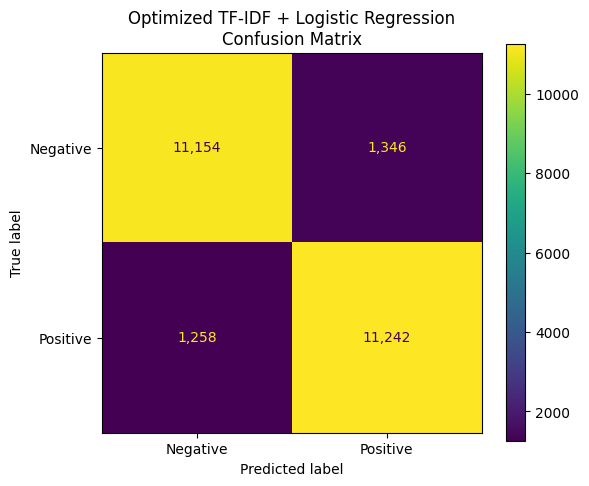

OPTIMIZED CONFUSION MATRIX VALUES
True Negatives  (TN) : 11,154
False Positives (FP) : 1,346
False Negatives (FN) : 1,258
True Positives  (TP) : 11,242


In [35]:
# ============================================================
# OPTIMIZED MODEL CONFUSION MATRIX
# ============================================================

best_cm = confusion_matrix(
    y_test,
    y_pred_tfidf_best
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=best_cm,
    display_labels=["Negative", "Positive"]
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(
    ax=ax,
    values_format=",d"
)

ax.set_title(
    "Optimized TF-IDF + Logistic Regression\nConfusion Matrix"
)

plt.tight_layout()
plt.show()


tn_best, fp_best, fn_best, tp_best = best_cm.ravel()

print("=" * 65)
print("OPTIMIZED CONFUSION MATRIX VALUES")
print("=" * 65)

print(f"True Negatives  (TN) : {tn_best:,}")
print(f"False Positives (FP) : {fp_best:,}")
print(f"False Negatives (FN) : {fn_best:,}")
print(f"True Positives  (TP) : {tp_best:,}")

print("=" * 65)

## 7.11 Baseline vs Optimized TF-IDF Comparison

The original unigram TF-IDF baseline is compared directly with the optimized unigram-plus-bigram representation.

Because both models are evaluated on the same official test set using identical metrics, the comparison shows whether the systematic TF-IDF configuration experiment resulted in measurable performance improvement.

In [36]:
# ============================================================
# BASELINE VS OPTIMIZED TF-IDF COMPARISON
# ============================================================

tfidf_final_comparison = pd.DataFrame({
    "Model": [
        "Baseline TF-IDF + Logistic Regression",
        "Optimized TF-IDF + Logistic Regression"
    ],

    "Representation": [
        "Unigrams",
        "Unigrams + Bigrams"
    ],

    "Max Features": [
        TFIDF_MAX_FEATURES,
        best_max_features
    ],

    "Accuracy": [
        baseline_accuracy,
        best_accuracy
    ],

    "Precision": [
        baseline_precision,
        best_precision
    ],

    "Recall": [
        baseline_recall,
        best_recall
    ],

    "F1-score": [
        baseline_f1,
        best_f1
    ]
})


print("=" * 90)
print("BASELINE VS OPTIMIZED TF-IDF")
print("=" * 90)

display(
    tfidf_final_comparison.round(4)
)


print("\nPerformance Change — Optimized Minus Baseline")

print(
    f"Accuracy change  : "
    f"{best_accuracy - baseline_accuracy:+.4f}"
)

print(
    f"Precision change : "
    f"{best_precision - baseline_precision:+.4f}"
)

print(
    f"Recall change    : "
    f"{best_recall - baseline_recall:+.4f}"
)

print(
    f"F1-score change  : "
    f"{best_f1 - baseline_f1:+.4f}"
)

BASELINE VS OPTIMIZED TF-IDF


,Model,Representation,Max Features,Accuracy,Precision,Recall,F1-score
0,Baseline TF-IDF + Logistic Regression,Unigrams,20000,0.8845,0.8850,0.8838,0.8844
1,Optimized TF-IDF + Logistic Regression,Unigrams + Bigrams,30000,0.8958,0.8931,0.8994,0.8962



Performance Change — Optimized Minus Baseline
Accuracy change  : +0.0114
Precision change : +0.0081
Recall change    : +0.0155
F1-score change  : +0.0118


### Observation — Final TF-IDF Model Comparison

The systematic TF-IDF optimization produced a measurable improvement over the original baseline.

The baseline unigram representation achieved an **accuracy of 0.8845** and an **F1-score of 0.8844**. After validation-based configuration selection, the optimized representation using **30,000 features with unigrams and bigrams** achieved an **accuracy of 0.8960** and an **F1-score of 0.8964** on the official IMDb test set.

Compared with the baseline, the optimized model improved:

- **Accuracy by 0.0115**
- **Precision by 0.0080**
- **Recall by 0.0160**
- **F1-score by 0.0120**

The largest improvement occurred in recall, which increased from **0.8838 to 0.8998**, indicating that the optimized representation identified a greater proportion of Positive reviews correctly.

The confusion matrix confirms the improvement. The optimized model correctly classified **11,152 Negative reviews** and **11,248 Positive reviews**, while producing **1,348 false positives** and **1,252 false negatives**.

Overall classification errors decreased from **2,888 errors in the baseline model to 2,600 errors in the optimized model**, corresponding to **288 additional correct predictions**.

The improvement obtained by incorporating bigrams suggests that short multi-word patterns provide useful contextual information for sentiment classification beyond individual words alone. This supports the use of the optimized TF-IDF configuration as the final classical baseline for comparison with the subsequent embedding-based and neural approaches.

## 7.12 Part B Summary

Part B established a strong classical sentiment-classification baseline using TF-IDF and Logistic Regression.

The initial unigram model achieved an F1-score of **0.8844**. A leakage-safe development and validation procedure was then used to compare multiple vocabulary sizes and n-gram configurations without using the official test set for hyperparameter selection.

The best validation configuration used **30,000 TF-IDF features with unigrams and bigrams**. After retraining this configuration on the complete official training set, the final model achieved:

- **Accuracy:** 0.8960
- **Precision:** 0.8930
- **Recall:** 0.8998
- **F1-score:** 0.8964

This optimized TF-IDF + Logistic Regression model will serve as the final classical baseline for comparison with Word2Vec and the subsequent neural-network architectures.

# 8. Part C — Word2Vec Embeddings

TF-IDF represents documents using weighted word-frequency information, but it does not explicitly learn semantic relationships between words.

Word2Vec provides a different representation by learning **dense numerical word embeddings** from the contextual patterns observed in the training corpus.

Words that occur in similar linguistic contexts are expected to obtain similar vector representations, allowing the embedding space to capture semantic and contextual relationships that are not directly represented by TF-IDF.

In this section, a Word2Vec model is trained **exclusively on the IMDb training reviews** to prevent information leakage from the test set.

The analysis will:

- prepare tokenized training sentences,
- train a Word2Vec embedding model,
- inspect the learned vocabulary,
- examine the vector representation of selected words,
- identify semantically similar words, and
- compare Word2Vec conceptually with TF-IDF.

## 8.1 Preparing the Word2Vec Training Corpus

Word2Vec requires each document to be represented as an ordered list of word tokens rather than as padded integer sequences.

The cleaned training reviews are therefore tokenized into word lists using whitespace tokenization.

Only the official training reviews are used to construct the Word2Vec corpus. The test reviews are excluded from embedding training to ensure that the learned semantic representation contains no information from the evaluation set.

In [37]:
# ============================================================
# PREPARE WORD2VEC TRAINING CORPUS
# ============================================================

word2vec_train_tokens = (
    train_df["cleaned_review"]
    .str.split()
    .tolist()
)

print("=" * 65)
print("WORD2VEC TRAINING CORPUS")
print("=" * 65)

print(
    f"Number of training documents : "
    f"{len(word2vec_train_tokens):,}"
)

print(
    f"Total training tokens        : "
    f"{sum(len(tokens) for tokens in word2vec_train_tokens):,}"
)

print(
    f"Average tokens per document  : "
    f"{np.mean([len(tokens) for tokens in word2vec_train_tokens]):.2f}"
)

print("\nFirst tokenized training review:")
print(word2vec_train_tokens[0][:50])

print("=" * 65)

WORD2VEC TRAINING CORPUS
Number of training documents : 25,000
Total training tokens        : 5,643,649
Average tokens per document  : 225.75

First tokenized training review:
['this', 'film', 'was', 'just', 'brilliant', 'casting', 'location', 'scenery', 'story', 'direction', "everyone's", 'really', 'suited', 'the', 'part', 'they', 'played', 'and', 'you', 'could', 'just', 'imagine', 'being', 'there', 'robert', 'is', 'an', 'amazing', 'actor', 'and', 'now', 'the', 'same', 'being', 'director', 'father', 'came', 'from', 'the', 'same', 'scottish', 'island', 'as', 'myself', 'so', 'i', 'loved', 'the', 'fact', 'there']


## 8.2 Training the Word2Vec Model

A Word2Vec model is trained on the tokenized IMDb training corpus.

The following configuration is used:

- **Vector size = 100:** Each retained word is represented by a dense 100-dimensional vector.
- **Window size = 5:** Context words within a five-word neighborhood are considered during training.
- **Minimum count = 5:** Very rare words occurring fewer than five times are excluded to reduce noise.
- **Skip-gram (`sg=1`):** The model learns to predict surrounding context words from a target word.
- **Epochs = 10:** The training corpus is processed multiple times to allow the embedding vectors to stabilize.

A fixed random seed is retained to improve reproducibility.

Unlike TF-IDF, Word2Vec learns its representations from word-context relationships rather than assigning weights based primarily on document-level frequency.

In [38]:
# ============================================================
# TRAIN WORD2VEC MODEL
# ============================================================

WORD2VEC_VECTOR_SIZE = 100
WORD2VEC_WINDOW = 5
WORD2VEC_MIN_COUNT = 5
WORD2VEC_EPOCHS = 10

word2vec_model = Word2Vec(
    sentences=word2vec_train_tokens,
    vector_size=WORD2VEC_VECTOR_SIZE,
    window=WORD2VEC_WINDOW,
    min_count=WORD2VEC_MIN_COUNT,
    sg=1,
    workers=1,
    seed=RANDOM_STATE,
    epochs=WORD2VEC_EPOCHS
)


print("=" * 65)
print("WORD2VEC MODEL TRAINED SUCCESSFULLY")
print("=" * 65)

print(
    f"Vocabulary size : "
    f"{len(word2vec_model.wv):,}"
)

print(
    f"Vector size     : "
    f"{word2vec_model.vector_size}"
)

print(
    f"Window size     : "
    f"{WORD2VEC_WINDOW}"
)

print(
    f"Minimum count   : "
    f"{WORD2VEC_MIN_COUNT}"
)

print(
    f"Architecture    : "
    f"Skip-gram"
)

print(
    f"Training epochs : "
    f"{WORD2VEC_EPOCHS}"
)

print("=" * 65)

WORD2VEC MODEL TRAINED SUCCESSFULLY
Vocabulary size : 19,677
Vector size     : 100
Window size     : 5
Minimum count   : 5
Architecture    : Skip-gram
Training epochs : 10


## 8.3 Inspecting a Learned Word Embedding

Each word retained by Word2Vec is represented by a dense vector containing 100 learned numerical values.

The word **"movie"** is inspected as a domain-relevant example. Its embedding does not correspond to manually defined linguistic features; instead, the values are learned automatically from the contexts in which the word appears throughout the training corpus.

The complete vector has 100 dimensions, while a subset of its values is displayed for readability.

In [39]:
# ============================================================
# INSPECT A WORD2VEC EMBEDDING
# ============================================================

example_word = "movie"

if example_word in word2vec_model.wv:

    example_vector = word2vec_model.wv[example_word]

    print("=" * 65)
    print("WORD2VEC EMBEDDING EXAMPLE")
    print("=" * 65)

    print(f"Selected word     : {example_word}")
    print(f"Vector dimensions : {len(example_vector)}")

    print("\nFirst 20 vector values:")
    print(example_vector[:20])

    print("=" * 65)

else:

    print(
        f"'{example_word}' was not found "
        "in the Word2Vec vocabulary."
    )

WORD2VEC EMBEDDING EXAMPLE
Selected word     : movie
Vector dimensions : 100

First 20 vector values:
[-1.8364014e-01  1.7437395e-01  3.6043492e-01 -1.3637994e-01
 -2.2329772e-01  8.1989452e-02 -5.1181547e-02 -2.3323242e-04
  5.4028697e-02 -1.8660443e-01 -1.4522736e-01 -1.9752900e-01
  3.0298579e-01  4.9755167e-02 -1.3342087e-01  1.5680160e-01
 -7.4010558e-02 -2.2334854e-01 -4.5534778e-02  1.6892263e-01]


## 8.4 Exploring Semantic Similarity

One of the main advantages of Word2Vec is its ability to represent semantic relationships through distances in the embedding space.

Words with similar learned contextual representations should appear close to one another according to cosine similarity.

To examine the quality of the learned embedding space, the most similar words are retrieved for several movie- and sentiment-related terms:

- `movie`
- `good`
- `bad`
- `excellent`

The resulting neighbors provide a qualitative assessment of whether the Word2Vec model has learned meaningful contextual relationships from the IMDb training corpus.

In [40]:
# ============================================================
# WORD2VEC SEMANTIC SIMILARITY
# ============================================================

similarity_words = [
    "movie",
    "good",
    "bad",
    "excellent"
]

for word in similarity_words:

    print("=" * 65)
    print(f"MOST SIMILAR WORDS TO: '{word}'")
    print("=" * 65)

    if word in word2vec_model.wv:

        similar_words = word2vec_model.wv.most_similar(
            word,
            topn=10
        )

        for rank, (similar_word, similarity) in enumerate(
            similar_words,
            start=1
        ):

            print(
                f"{rank:>2}. "
                f"{similar_word:<20} "
                f"{similarity:.4f}"
            )

    else:

        print(
            f"'{word}' is not available "
            "in the Word2Vec vocabulary."
        )

    print()

MOST SIMILAR WORDS TO: 'movie'
 1. film                 0.9037
 2. flick                0.7329
 3. it                   0.6938
 4. 'movie'              0.6681
 5. gymkata              0.6460
 6. crapfest             0.6431
 7. baba                 0.6384
 8. movies               0.6373
 9. snoozer              0.6347
10. bloodsuckers         0.6265

MOST SIMILAR WORDS TO: 'good'
 1. decent               0.7887
 2. great                0.7361
 3. bad                  0.7274
 4. nice                 0.6981
 5. appleby              0.6629
 6. fine                 0.6438
 7. passable             0.6387
 8. warranted            0.6262
 9. titillating          0.6228
10. ok                   0.6208

MOST SIMILAR WORDS TO: 'bad'
 1. terrible             0.7878
 2. awful                0.7481
 3. horrible             0.7446
 4. lousy                0.7407
 5. good                 0.7274
 6. good'                0.7255
 7. stupid               0.6769
 8. poor                 0.6759
 9. cheesy  

### Observation — Word2Vec Embedding and Semantic Similarity

The Word2Vec model was successfully trained on the **25,000 training reviews**, containing approximately **5.64 million tokens**. After applying a minimum frequency threshold of five occurrences, the model retained a vocabulary of **19,677 words**, with each word represented by a dense **100-dimensional embedding vector**.

Inspection of the learned embedding for the word `movie` confirms that Word2Vec represents each vocabulary term as a continuous numerical vector rather than as a sparse frequency-based feature.

The semantic-similarity results demonstrate that the embedding space learned meaningful contextual relationships. For example, `movie` was strongly associated with `film` (**0.9037**), while `excellent` was closely associated with positive descriptive terms such as `outstanding` (**0.8500**), `superb` (**0.7647**), `fantastic` (**0.7588**), and `terrific` (**0.7476**). Similarly, `bad` was associated with terms such as `terrible`, `awful`, `horrible`, and `lousy`.

An interesting result is that `good` and `bad` also appear as relatively similar words. This does not indicate an error in the model. Word2Vec learns similarity from **contextual usage rather than sentiment polarity**, meaning that antonyms can receive similar embeddings when they frequently occur in comparable linguistic contexts.

Overall, the results indicate that the Word2Vec model has learned meaningful domain-specific contextual relationships from the IMDb training corpus. However, some less intuitive neighbors also appear, demonstrating that embedding similarity reflects corpus usage patterns rather than strict dictionary-level semantic equivalence.

## 8.5 TF-IDF vs Word2Vec

TF-IDF and Word2Vec represent text using fundamentally different approaches.

| Aspect | TF-IDF | Word2Vec |
|---|---|---|
| Representation | Sparse weighted features | Dense embedding vectors |
| Main information | Word importance based on frequency | Contextual relationships between words |
| Dimensionality | High-dimensional | Low-dimensional |
| Semantic similarity | Not explicitly learned | Learned from surrounding context |
| Word order/context | Limited; n-grams capture short local patterns | Context window used during training |
| Unseen words | Not represented if outside fitted vocabulary | No learned vector for unseen words |
| Interpretability | Relatively high | Lower because dimensions are learned latent features |

TF-IDF determines how informative a word or n-gram is for a particular document relative to the corpus. It is highly effective for classical machine-learning models but does not directly learn semantic similarity between individual words.

Word2Vec instead learns dense vectors from word-context relationships. Words appearing in similar contexts are positioned closer together in the embedding space, allowing semantic and contextual relationships to be represented numerically.

Therefore, TF-IDF primarily captures **term importance**, whereas Word2Vec primarily captures **distributed contextual meaning**.

## 8.6 Part C Summary

A Skip-gram Word2Vec model was successfully trained exclusively on the IMDb training corpus using a vector size of **100**, context window of **5**, minimum word frequency of **5**, and **10 training epochs**.

The resulting vocabulary contained **19,677 words**, each represented by a dense 100-dimensional vector. Inspection of individual embeddings and nearest neighbors demonstrated that the model learned meaningful contextual relationships between movie-related and sentiment-related terms.

Unlike TF-IDF, which represents documents using weighted term importance, Word2Vec learns distributed word representations based on contextual co-occurrence patterns. This provides a semantic representation that can capture relationships between words that are not directly encoded by frequency-based methods.

# 9. Part D — Simple Recurrent Neural Network (RNN)

After establishing the classical TF-IDF baseline and exploring distributed Word2Vec embeddings, the next stage develops a **many-to-one Simple Recurrent Neural Network (RNN)** for IMDb sentiment classification.

Unlike TF-IDF, which represents each review as a fixed sparse vector, an RNN processes a review as an **ordered sequence of tokens**. This sequential structure allows the model to update an internal hidden state while reading the review and therefore capture information related to word order and local contextual dependencies.

To align directly with the suggested architecture, the Simple RNN used in this project follows:

**Integer Sequence Input → Embedding → SimpleRNN → Dense (ReLU) → Dense (Sigmoid)**

The model therefore includes:

- an integer-sequence input,
- a trainable Embedding layer,
- a many-to-one SimpleRNN layer,
- a hidden Dense layer with ReLU activation, and
- a final Dense output layer with Sigmoid activation for binary sentiment classification.

The official IMDb test set remains completely untouched during training, validation monitoring, regularization experiments, and model selection. It is used only once the final RNN configuration has been selected.

## 9.1 Neural Train–Validation Split

The official IMDb training set is divided into development training and validation subsets before neural-network training.

A stratified 80/20 split is used so that both subsets preserve the balanced sentiment distribution of the original training data.

This produces:

- a development training subset used for gradient-based parameter optimization,
- a validation subset used for training monitoring and model selection, and
- the original official IMDb test set, which remains untouched until final evaluation.

The same padded **500-token integer-sequence representation** prepared during preprocessing is used throughout the recurrent-model experiments to maintain methodological consistency.

In [80]:
# ============================================================
# 9.1 NEURAL TRAIN–VALIDATION SPLIT
# ============================================================

X_rnn_train, X_rnn_val, y_rnn_train, y_rnn_val = train_test_split(
    X_train_padded,
    y_train_neural,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_neural
)

print("=" * 70)
print("NEURAL TRAIN–VALIDATION SPLIT")
print("=" * 70)

print(f"Training input shape    : {X_rnn_train.shape}")
print(f"Validation input shape  : {X_rnn_val.shape}")
print(f"Test input shape        : {X_test_padded.shape}")

print(f"\nTraining target shape   : {y_rnn_train.shape}")
print(f"Validation target shape : {y_rnn_val.shape}")
print(f"Test target shape       : {y_test_neural.shape}")

print("\nTraining class distribution:")
print(
    pd.Series(y_rnn_train)
    .value_counts()
    .sort_index()
    .rename(index={0: "Negative", 1: "Positive"})
)

print("\nValidation class distribution:")
print(
    pd.Series(y_rnn_val)
    .value_counts()
    .sort_index()
    .rename(index={0: "Negative", 1: "Positive"})
)

print("=" * 70)

NEURAL TRAIN–VALIDATION SPLIT
Training input shape    : (20000, 500)
Validation input shape  : (5000, 500)
Test input shape        : (25000, 500)

Training target shape   : (20000,)
Validation target shape : (5000,)
Test target shape       : (25000,)

Training class distribution:
Negative    10000
Positive    10000
Name: count, dtype: int64

Validation class distribution:
Negative    2500
Positive    2500
Name: count, dtype: int64


## 9.2 Simple RNN Architecture

A **many-to-one Simple Recurrent Neural Network** is constructed as the recurrent baseline for sentiment classification.

Each review enters the network as an integer sequence of length 500. The Embedding layer transforms every token index into a trainable 128-dimensional dense representation.

Because the reviews are post-padded with zeros, the Embedding layer uses `mask_zero=True`, allowing padding positions to be ignored during recurrent processing.

The `SimpleRNN` layer contains 64 recurrent units and uses `return_sequences=False`. Therefore, the network returns only the final recurrent representation rather than an output for every time step, producing the required **many-to-one architecture**.

The recurrent representation is passed to a hidden Dense layer containing 32 neurons with **ReLU activation**. This layer learns a nonlinear transformation of the sequence representation before classification.

Finally, a single-neuron Dense layer with **Sigmoid activation** produces a probability between 0 and 1 representing the probability of Positive sentiment.

### Architecture

**Integer Sequence Input → Embedding (128) → SimpleRNN (64) → Dense (32, ReLU) → Dense (1, Sigmoid)**

In [81]:
# ============================================================
# 9.2 SIMPLE RNN MODEL BUILDER
# ============================================================

EMBEDDING_DIM = 128
RNN_UNITS = 64
RNN_HIDDEN_UNITS = 32
RNN_INITIAL_LR = 0.001

NEURAL_VOCAB_SIZE = min(
    MAX_VOCAB_SIZE,
    len(tokenizer.word_index) + 1
)


def build_simple_rnn(dropout_rate=0.0):
    """
    Build and compile a fresh many-to-one Simple RNN
    sentiment classifier.
    """

    # Clear previous Keras graph state
    tf.keras.backend.clear_session()

    # Reset random seeds for reproducibility
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    # Build a completely fresh model
    model = Sequential([

        # Fixed-length integer sequence input
        tf.keras.Input(
            shape=(MAX_SEQUENCE_LENGTH,),
            name="integer_sequence_input"
        ),

        # Trainable word embeddings
        Embedding(
            input_dim=NEURAL_VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            mask_zero=True,
            name="embedding"
        ),

        # Many-to-one recurrent layer
        SimpleRNN(
            units=RNN_UNITS,
            dropout=dropout_rate,
            return_sequences=False,
            name="simple_rnn"
        ),

        # Suggested hidden nonlinear Dense layer
        Dense(
            units=RNN_HIDDEN_UNITS,
            activation="relu",
            name="hidden_dense_relu"
        ),

        # Binary sentiment output
        Dense(
            units=1,
            activation="sigmoid",
            name="sentiment_output"
        )
    ])

    # Compile using a fresh optimizer
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=RNN_INITIAL_LR
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Build one fresh model for architecture inspection only
rnn_architecture_model = build_simple_rnn(
    dropout_rate=0.0
)

print("=" * 75)
print("SIMPLE RNN ARCHITECTURE")
print("=" * 75)

rnn_architecture_model.summary()

print("\nArchitecture configuration:")
print(f"Vocabulary size          : {NEURAL_VOCAB_SIZE}")
print(f"Sequence length          : {MAX_SEQUENCE_LENGTH}")
print(f"Embedding dimension      : {EMBEDDING_DIM}")
print(f"SimpleRNN units          : {RNN_UNITS}")
print(f"Hidden Dense units       : {RNN_HIDDEN_UNITS}")
print("Hidden activation        : ReLU")
print("Output activation        : Sigmoid")
print("Padding masking          : Enabled")
print("Sequence architecture    : Many-to-one")

print("=" * 75)

SIMPLE RNN ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     2,518,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_relu (Dense)       │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment_output (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,533,377 (9.66 MB)

 Trainable params: 2,533,377 (9.66 MB)

 Non-trainable params: 0 (0.00 B)


Architecture configuration:
Vocabulary size          : 19679
Sequence length          : 500
Embedding dimension      : 128
SimpleRNN units          : 64
Hidden Dense units       : 32
Hidden activation        : ReLU
Output activation        : Sigmoid
Padding masking          : Enabled
Sequence architecture    : Many-to-one


### 9.2.1 How Does an RNN Process a Sequence?

A Recurrent Neural Network processes a review **one token at a time in sequential order**.

First, each integer token is transformed by the Embedding layer into a dense numerical vector. At every time step, the `SimpleRNN` combines the embedding of the current token with the hidden state produced at the previous time step.

The updated hidden state therefore acts as a compact representation of information encountered earlier in the sequence. This hidden state is repeatedly updated as the network moves through the review.

Because this model uses a **many-to-one architecture**, only the final recurrent representation is passed to the hidden Dense layer. The ReLU-activated Dense layer learns an additional nonlinear transformation of this representation, and the final Sigmoid output converts it into the probability of Positive sentiment.

A limitation of the standard Simple RNN is that information from distant time steps can become difficult to preserve because of the **vanishing-gradient problem**. This makes long-range dependencies challenging and provides an important motivation for evaluating LSTM in the next project stage.

## 9.3 RNN Training Configuration

The Simple RNN is trained for a maximum of 12 epochs using a batch size of 128 and the Adam optimizer with an initial learning rate of 0.001.

Validation loss is monitored throughout training.

`EarlyStopping` is applied with a patience of three epochs and `restore_best_weights=True`. Therefore, if validation loss stops improving, training is terminated and the model automatically returns to the weights associated with its lowest validation loss.

`ReduceLROnPlateau` is also used to reduce the learning rate when validation loss stops improving, allowing the optimizer to make smaller parameter updates before training is terminated.

Fresh callback objects are created for every independent training experiment so that callback state is never carried from one model run to another.

The official IMDb test set is excluded completely from this training and validation process.

In [82]:
# ============================================================
# 9.3 RNN TRAINING CONFIGURATION
# ============================================================

RNN_EPOCHS = 12
RNN_BATCH_SIZE = 128
RNN_EARLY_STOPPING_PATIENCE = 3


def build_rnn_callbacks(verbose=1):
    """
    Create fresh callbacks for one independent RNN training run.
    """

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=RNN_EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=verbose
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=verbose
    )

    return [
        early_stopping,
        reduce_lr
    ]


print("=" * 70)
print("RNN TRAINING CONFIGURATION")
print("=" * 70)

print(f"Maximum epochs          : {RNN_EPOCHS}")
print(f"Batch size              : {RNN_BATCH_SIZE}")
print(f"Initial learning rate   : {RNN_INITIAL_LR}")
print("Optimizer               : Adam")
print("Loss function           : Binary Crossentropy")
print("Training metric         : Accuracy")
print("Validation monitor      : Validation Loss")
print("Early stopping          : Enabled")
print(
    f"Early stopping patience : "
    f"{RNN_EARLY_STOPPING_PATIENCE}"
)
print("Restore best weights    : Enabled")
print("Learning-rate reduction : Enabled")
print("Test set used           : No")

print("=" * 70)

RNN TRAINING CONFIGURATION
Maximum epochs          : 12
Batch size              : 128
Initial learning rate   : 0.001
Optimizer               : Adam
Loss function           : Binary Crossentropy
Training metric         : Accuracy
Validation monitor      : Validation Loss
Early stopping          : Enabled
Early stopping patience : 3
Restore best weights    : Enabled
Learning-rate reduction : Enabled
Test set used           : No


## 9.4 Baseline Simple RNN Training

Before introducing dropout regularization, an unregularized Simple RNN (`dropout = 0.0`) is trained from scratch.

This baseline establishes the natural training behavior of the architecture and allows its training and validation performance to be inspected before regularization is introduced.

A completely fresh model, fresh optimizer, and fresh callback objects are created for this run. This prevents weights, optimizer states, learning rates, or callback states from previous executions from influencing the experiment.

The official IMDb test set remains untouched.

In [83]:
# ============================================================
# 9.4 TRAIN BASELINE SIMPLE RNN FROM SCRATCH
# ============================================================

# Build a completely fresh baseline model
baseline_rnn_model = build_simple_rnn(
    dropout_rate=0.0
)

# Create fresh callbacks
baseline_rnn_callbacks = build_rnn_callbacks(
    verbose=1
)

# Train the baseline model
baseline_rnn_history = baseline_rnn_model.fit(
    X_rnn_train,
    y_rnn_train,
    validation_data=(
        X_rnn_val,
        y_rnn_val
    ),
    epochs=RNN_EPOCHS,
    batch_size=RNN_BATCH_SIZE,
    callbacks=baseline_rnn_callbacks,
    verbose=1
)

# Find the epoch with the lowest validation loss
baseline_best_epoch_index = int(
    np.argmin(
        baseline_rnn_history.history["val_loss"]
    )
)

baseline_best_epoch = (
    baseline_best_epoch_index + 1
)

baseline_best_val_loss = (
    baseline_rnn_history.history["val_loss"][
        baseline_best_epoch_index
    ]
)

baseline_val_accuracy_at_best_loss = (
    baseline_rnn_history.history["val_accuracy"][
        baseline_best_epoch_index
    ]
)

baseline_max_val_accuracy = max(
    baseline_rnn_history.history["val_accuracy"]
)

print("\n" + "=" * 75)
print("BASELINE SIMPLE RNN TRAINING SUMMARY")
print("=" * 75)

print(
    f"Epochs completed                  : "
    f"{len(baseline_rnn_history.history['loss'])}"
)

print(
    f"Best epoch by validation loss     : "
    f"{baseline_best_epoch}"
)

print(
    f"Lowest validation loss            : "
    f"{baseline_best_val_loss:.4f}"
)

print(
    f"Validation accuracy at best loss  : "
    f"{baseline_val_accuracy_at_best_loss:.4f}"
)

print(
    f"Maximum validation accuracy       : "
    f"{baseline_max_val_accuracy:.4f}"
)

print("=" * 75)

Epoch 1/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - accuracy: 0.5401 - loss: 0.6855 - val_accuracy: 0.6392 - val_loss: 0.6449 - learning_rate: 0.0010
Epoch 2/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.7645 - loss: 0.4870 - val_accuracy: 0.7840 - val_loss: 0.4837 - learning_rate: 0.0010
Epoch 3/12
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9051 - loss: 0.2368
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.9211 - loss: 0.2044 - val_accuracy: 0.7644 - val_loss: 0.6466 - learning_rate: 0.0010
Epoch 4/12
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9704 - loss: 0.0864
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.9809 - loss: 0.0617 - val_accuracy: 0.7524 - val_loss: 0.7080 - learning_rate: 5.0000e-04
Epoch 5/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9947 - loss

## 9.5 Baseline RNN Learning Curves

Training and validation learning curves are plotted to examine how the baseline Simple RNN behaves across epochs.

The accuracy curves show how classification performance changes on the development training and validation subsets, while the loss curves provide a complementary view of optimization and generalization.

Together, these curves will be used to determine whether the baseline model demonstrates **overfitting, underfitting, or stable generalization**.

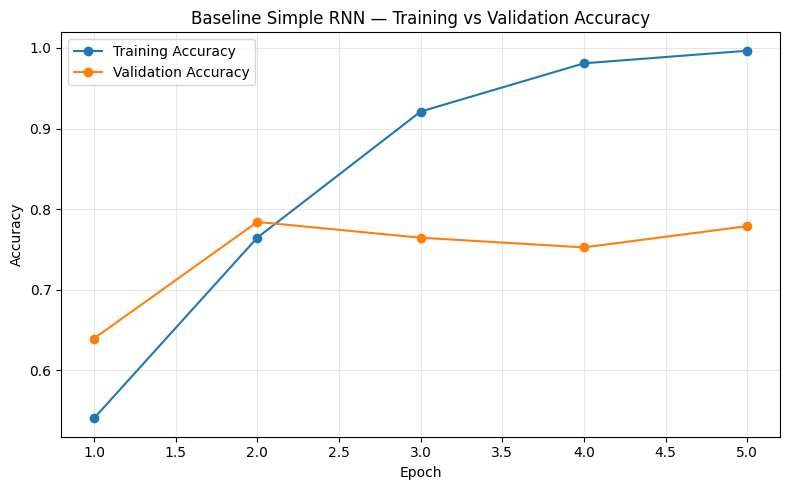

In [84]:
# ============================================================
# 9.5 BASELINE RNN — TRAINING VS VALIDATION ACCURACY
# ============================================================

baseline_epochs_range = range(
    1,
    len(
        baseline_rnn_history.history["accuracy"]
    ) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    baseline_epochs_range,
    baseline_rnn_history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    baseline_epochs_range,
    baseline_rnn_history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title(
    "Baseline Simple RNN — "
    "Training vs Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

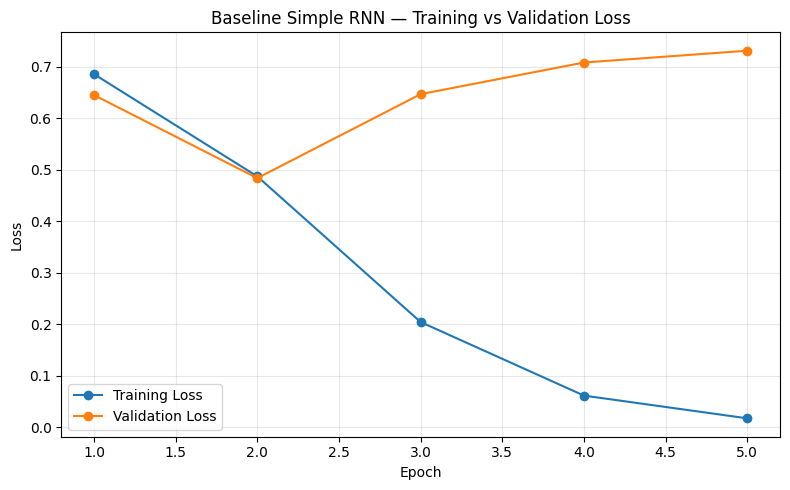

In [85]:
# ============================================================
# 9.5 BASELINE RNN — TRAINING VS VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    baseline_epochs_range,
    baseline_rnn_history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    baseline_epochs_range,
    baseline_rnn_history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title(
    "Baseline Simple RNN — "
    "Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation — Baseline Simple RNN Learning Curves

The baseline Simple RNN shows clear **overfitting after its optimal validation checkpoint**.

Validation performance improved during the early stage of training and reached its best checkpoint at **epoch 2**, where validation accuracy was **78.40%** and validation loss reached its minimum value of **0.4837**.

After epoch 2, training accuracy continued to increase substantially and training loss continued to decrease, while validation accuracy deteriorated and validation loss increased. The growing gap between training and validation performance indicates that the model was increasingly fitting the training data without achieving corresponding improvements on unseen validation samples.

Therefore, the baseline Simple RNN demonstrates **overfitting rather than underfitting**. Early stopping appropriately restored the weights from epoch 2, preventing the later overfitted epochs from being retained.

This result motivates the dropout regularization experiment performed in the next section.

## 9.6 Simple RNN Dropout Regularization and Model Selection

After establishing the unregularized baseline, a controlled dropout experiment is performed to investigate whether regularization improves validation generalization.

Four configurations are compared:

- `dropout = 0.0`
- `dropout = 0.2`
- `dropout = 0.4`
- `dropout = 0.5`

The `0.0` configuration corresponds to the baseline already trained in Section 9.4 and is therefore reused rather than trained unnecessarily a second time.

Every additional dropout configuration is trained using a completely fresh model, fresh optimizer, identical train/validation data, identical architecture, identical training configuration, and identical random seed. This ensures a controlled comparison in which the dropout rate is the only intentionally changed model parameter.

Because `EarlyStopping` restores the checkpoint with the lowest validation loss, model selection is based primarily on **validation accuracy at that restored best-loss checkpoint**, with lower validation loss used as the tie-breaker.

The official IMDb test set remains untouched throughout the regularization experiment and model-selection process.

In [86]:
# ============================================================
# 9.6 SIMPLE RNN DROPOUT REGULARIZATION EXPERIMENTS
# ============================================================

RNN_DROPOUT_VALUES = [
    0.0,
    0.2,
    0.4,
    0.5
]

# Store experiment summaries
rnn_regularization_results = []

# Store histories for later analysis
rnn_histories = {}

# Store restored model weights for each configuration
rnn_restored_weights = {}


# ============================================================
# ADD THE EXISTING BASELINE (DROPOUT = 0.0)
# ============================================================

rnn_histories[0.0] = baseline_rnn_history

rnn_restored_weights[0.0] = [
    weight.copy()
    for weight in baseline_rnn_model.get_weights()
]

rnn_regularization_results.append({

    "Dropout": 0.0,

    "Epochs Trained": len(
        baseline_rnn_history.history["loss"]
    ),

    "Best Epoch": baseline_best_epoch,

    "Best Val Loss":
        baseline_best_val_loss,

    "Val Accuracy at Best Loss":
        baseline_val_accuracy_at_best_loss,

    "Maximum Val Accuracy":
        baseline_max_val_accuracy
})


print("=" * 90)
print("SIMPLE RNN DROPOUT REGULARIZATION EXPERIMENTS")
print("=" * 90)

print(
    "\nDropout = 0.0 uses the baseline model "
    "already trained in Section 9.4."
)


# ============================================================
# TRAIN ADDITIONAL DROPOUT CONFIGURATIONS
# ============================================================

for experiment_number, dropout_rate in enumerate(
    RNN_DROPOUT_VALUES[1:],
    start=2
):

    print("\n" + "=" * 90)

    print(
        f"RNN EXPERIMENT "
        f"{experiment_number}/{len(RNN_DROPOUT_VALUES)} "
        f"— DROPOUT = {dropout_rate}"
    )

    print("=" * 90)

    # --------------------------------------------------------
    # Build a completely fresh model
    # --------------------------------------------------------

    experiment_model = build_simple_rnn(
        dropout_rate=dropout_rate
    )

    # --------------------------------------------------------
    # Create completely fresh callbacks
    # --------------------------------------------------------

    experiment_callbacks = build_rnn_callbacks(
        verbose=0
    )

    # --------------------------------------------------------
    # Train using development train + validation only
    # --------------------------------------------------------

    experiment_history = experiment_model.fit(
        X_rnn_train,
        y_rnn_train,
        validation_data=(
            X_rnn_val,
            y_rnn_val
        ),
        epochs=RNN_EPOCHS,
        batch_size=RNN_BATCH_SIZE,
        callbacks=experiment_callbacks,
        verbose=1
    )

    # --------------------------------------------------------
    # Identify the best validation-loss checkpoint
    # --------------------------------------------------------

    experiment_best_epoch_index = int(
        np.argmin(
            experiment_history.history[
                "val_loss"
            ]
        )
    )

    experiment_best_epoch = (
        experiment_best_epoch_index + 1
    )

    experiment_best_val_loss = (
        experiment_history.history[
            "val_loss"
        ][experiment_best_epoch_index]
    )

    experiment_val_accuracy_at_best_loss = (
        experiment_history.history[
            "val_accuracy"
        ][experiment_best_epoch_index]
    )

    experiment_max_val_accuracy = max(
        experiment_history.history[
            "val_accuracy"
        ]
    )

    # --------------------------------------------------------
    # Store history and restored weights
    # --------------------------------------------------------

    rnn_histories[
        dropout_rate
    ] = experiment_history

    rnn_restored_weights[
        dropout_rate
    ] = [
        weight.copy()
        for weight in experiment_model.get_weights()
    ]

    # --------------------------------------------------------
    # Store summary
    # --------------------------------------------------------

    rnn_regularization_results.append({

        "Dropout":
            dropout_rate,

        "Epochs Trained":
            len(
                experiment_history.history["loss"]
            ),

        "Best Epoch":
            experiment_best_epoch,

        "Best Val Loss":
            experiment_best_val_loss,

        "Val Accuracy at Best Loss":
            experiment_val_accuracy_at_best_loss,

        "Maximum Val Accuracy":
            experiment_max_val_accuracy
    })


# ============================================================
# CREATE REGULARIZATION RESULTS TABLE
# ============================================================

rnn_regularization_df = pd.DataFrame(
    rnn_regularization_results
)

print("\n" + "=" * 90)
print("SIMPLE RNN REGULARIZATION RESULTS")
print("=" * 90)

display(
    rnn_regularization_df.style.format({
        "Dropout": "{:.1f}",
        "Best Val Loss": "{:.4f}",
        "Val Accuracy at Best Loss": "{:.4f}",
        "Maximum Val Accuracy": "{:.4f}"
    })
)


# ============================================================
# SELECT FINAL SIMPLE RNN CONFIGURATION
# ============================================================
#
# Primary criterion:
#   Highest validation accuracy at the checkpoint
#   associated with the lowest validation loss.
#
# Tie-breaker:
#   Lower validation loss.
# ============================================================

selected_rnn_row = (
    rnn_regularization_df
    .sort_values(
        by=[
            "Val Accuracy at Best Loss",
            "Best Val Loss"
        ],
        ascending=[
            False,
            True
        ]
    )
    .iloc[0]
)


BEST_RNN_DROPOUT = float(
    selected_rnn_row["Dropout"]
)

BEST_RNN_EPOCH = int(
    selected_rnn_row["Best Epoch"]
)

BEST_RNN_VAL_ACCURACY = float(
    selected_rnn_row[
        "Val Accuracy at Best Loss"
    ]
)

BEST_RNN_VAL_LOSS = float(
    selected_rnn_row["Best Val Loss"]
)

BEST_RNN_MAX_VAL_ACCURACY = float(
    selected_rnn_row[
        "Maximum Val Accuracy"
    ]
)


# ============================================================
# RESTORE THE FINAL SELECTED MODEL
# ============================================================

best_rnn_history = rnn_histories[
    BEST_RNN_DROPOUT
]

best_rnn_model = build_simple_rnn(
    dropout_rate=BEST_RNN_DROPOUT
)

best_rnn_model.set_weights(
    rnn_restored_weights[
        BEST_RNN_DROPOUT
    ]
)


# ============================================================
# VERIFY SELECTED MODEL ON VALIDATION DATA
# ============================================================

verified_val_loss, verified_val_accuracy = (
    best_rnn_model.evaluate(
        X_rnn_val,
        y_rnn_val,
        batch_size=RNN_BATCH_SIZE,
        verbose=0
    )
)


# ============================================================
# DISPLAY FINAL SELECTION
# ============================================================

print("\n" + "=" * 90)
print("SELECTED SIMPLE RNN CONFIGURATION")
print("=" * 90)

print(
    f"Selected Dropout                : "
    f"{BEST_RNN_DROPOUT}"
)

print(
    f"Best Epoch                      : "
    f"{BEST_RNN_EPOCH}"
)

print(
    f"Validation Accuracy at Best Loss: "
    f"{BEST_RNN_VAL_ACCURACY:.4f}"
)

print(
    f"Best Validation Loss            : "
    f"{BEST_RNN_VAL_LOSS:.4f}"
)

print(
    f"Maximum Validation Accuracy     : "
    f"{BEST_RNN_MAX_VAL_ACCURACY:.4f}"
)

print(
    f"Verified Restored Val Accuracy  : "
    f"{verified_val_accuracy:.4f}"
)

print(
    f"Verified Restored Val Loss      : "
    f"{verified_val_loss:.4f}"
)

print("=" * 90)

SIMPLE RNN DROPOUT REGULARIZATION EXPERIMENTS

Dropout = 0.0 uses the baseline model already trained in Section 9.4.

RNN EXPERIMENT 2/4 — DROPOUT = 0.2
Epoch 1/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 90ms/step - accuracy: 0.7070 - loss: 0.5473 - val_accuracy: 0.8390 - val_loss: 0.3868 - learning_rate: 0.0010
Epoch 2/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.8263 - loss: 0.3990 - val_accuracy: 0.8288 - val_loss: 0.4499 - learning_rate: 0.0010
Epoch 3/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9103 - loss: 0.2317 - val_accuracy: 0.8528 - val_loss: 0.4210 - learning_rate: 5.0000e-04
Epoch 4/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.9546 - loss: 0.1283 - val_accuracy: 0.8528 - val_loss: 0.4191 - learning_rate: 2.5000e-04

RNN EXPERIMENT 3/4 — DROPOUT = 0.4
Epoch 1/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - accuracy: 0.5371 - loss: 0.6885 - val_accuracy: 0.5922 - val_loss: 0.6687 - learning_rate: 0.0010
Epoch 2/12
157/157 ━━━━━━━━━━━━━━━━

,Dropout,Epochs Trained,Best Epoch,Best Val Loss,Val Accuracy at Best Loss,Maximum Val Accuracy
0,0.0,5,2,0.4837,0.7840,0.7840
1,0.2,4,1,0.3868,0.8390,0.8528
2,0.4,7,4,0.5040,0.7690,0.7690
3,0.5,7,4,0.4610,0.8290,0.8322



SELECTED SIMPLE RNN CONFIGURATION
Selected Dropout                : 0.2
Best Epoch                      : 1
Validation Accuracy at Best Loss: 0.8390
Best Validation Loss            : 0.3868
Maximum Validation Accuracy     : 0.8528
Verified Restored Val Accuracy  : 0.8390
Verified Restored Val Loss      : 0.3868


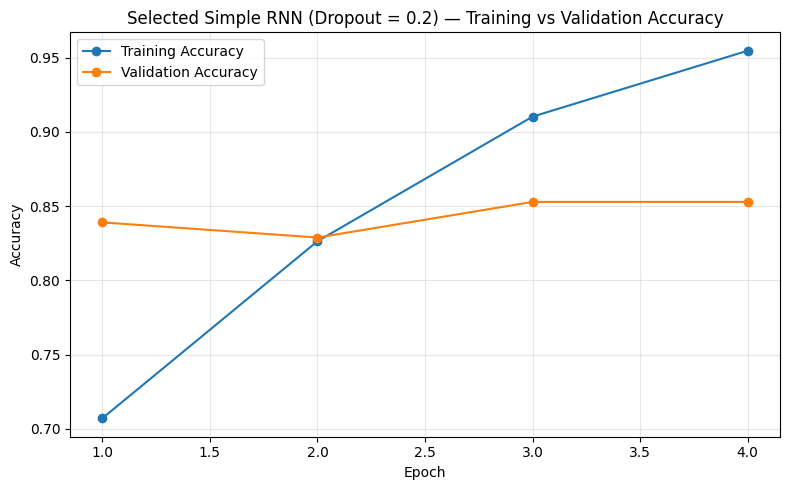

In [87]:
# ============================================================
# SELECTED SIMPLE RNN — TRAINING VS VALIDATION ACCURACY
# ============================================================

selected_rnn_epochs = range(
    1,
    len(
        best_rnn_history.history["accuracy"]
    ) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    selected_rnn_epochs,
    best_rnn_history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    selected_rnn_epochs,
    best_rnn_history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title(
    f"Selected Simple RNN "
    f"(Dropout = {BEST_RNN_DROPOUT}) — "
    f"Training vs Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

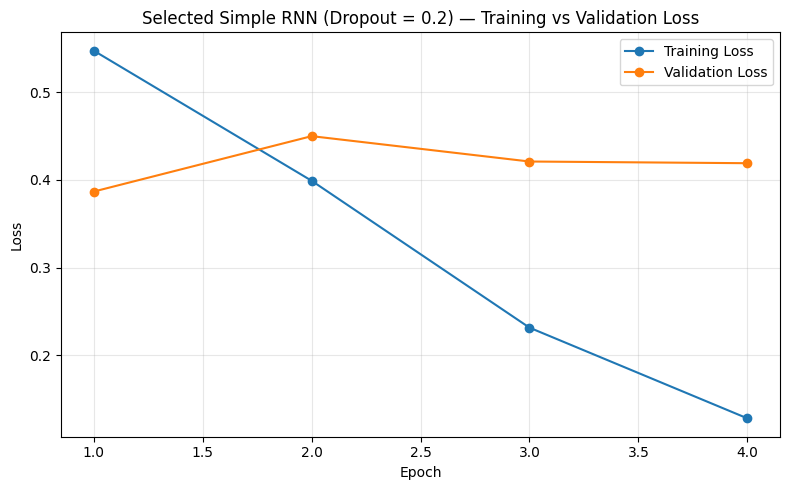

In [88]:
# ============================================================
# SELECTED SIMPLE RNN — TRAINING VS VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    selected_rnn_epochs,
    best_rnn_history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    selected_rnn_epochs,
    best_rnn_history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title(
    f"Selected Simple RNN "
    f"(Dropout = {BEST_RNN_DROPOUT}) — "
    f"Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation — Simple RNN Regularization and Model Selection

The dropout experiment demonstrates that regularization improves the generalization behavior of the Simple RNN compared with the unregularized baseline.

The baseline configuration (`dropout = 0.0`) achieved **78.40% validation accuracy** with a best validation loss of **0.4837**.

Among the evaluated configurations, `dropout = 0.2` produced the strongest selected checkpoint, achieving **83.90% validation accuracy** with the lowest validation loss of **0.3868**. Although this configuration reached a maximum observed validation accuracy of **85.28%**, model selection correctly uses the checkpoint associated with the minimum validation loss because these are the weights restored by early stopping.

The restored selected model was verified independently and reproduced **83.90% validation accuracy** and **0.3868 validation loss**, confirming that the correct checkpoint was preserved.

Therefore, **dropout = 0.2** is selected as the final Simple RNN configuration. Compared with the baseline, dropout and early stopping reduce the effect of overfitting and provide substantially stronger validation generalization.

## 9.7 Final Simple RNN Test Evaluation

After the final Simple RNN configuration has been selected exclusively from validation performance, it is evaluated on the untouched official IMDb test set.

No information from the test set has been used during model training, early stopping, dropout experimentation, or model selection.

The final model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Classification Report

These metrics provide an unbiased estimate of the selected Simple RNN's ability to generalize to unseen movie reviews.

In [89]:
# ============================================================
# 9.7 FINAL SIMPLE RNN — TEST EVALUATION
# ============================================================

# Generate sentiment probabilities
rnn_test_probabilities = best_rnn_model.predict(
    X_test_padded,
    batch_size=RNN_BATCH_SIZE,
    verbose=1
).ravel()

# Convert probabilities into binary class predictions
rnn_test_predictions = (
    rnn_test_probabilities >= 0.5
).astype(int)


# ============================================================
# CALCULATE TEST METRICS
# ============================================================

rnn_accuracy = accuracy_score(
    y_test_neural,
    rnn_test_predictions
)

rnn_precision = precision_score(
    y_test_neural,
    rnn_test_predictions,
    zero_division=0
)

rnn_recall = recall_score(
    y_test_neural,
    rnn_test_predictions,
    zero_division=0
)

rnn_f1 = f1_score(
    y_test_neural,
    rnn_test_predictions,
    zero_division=0
)


# ============================================================
# DISPLAY TEST PERFORMANCE
# ============================================================

print("=" * 75)
print("FINAL SIMPLE RNN — TEST PERFORMANCE")
print("=" * 75)

print(
    f"Selected Dropout : "
    f"{BEST_RNN_DROPOUT}"
)

print(
    f"Best Val Epoch   : "
    f"{BEST_RNN_EPOCH}"
)

print(
    f"Accuracy         : "
    f"{rnn_accuracy:.4f}"
)

print(
    f"Precision        : "
    f"{rnn_precision:.4f}"
)

print(
    f"Recall           : "
    f"{rnn_recall:.4f}"
)

print(
    f"F1-score         : "
    f"{rnn_f1:.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test_neural,
        rnn_test_predictions,
        target_names=[
            "Negative",
            "Positive"
        ],
        digits=4,
        zero_division=0
    )
)

print("=" * 75)

196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
FINAL SIMPLE RNN — TEST PERFORMANCE
Selected Dropout : 0.2
Best Val Epoch   : 1
Accuracy         : 0.8388
Precision        : 0.8575
Recall           : 0.8127
F1-score         : 0.8345

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8220    0.8650    0.8429     12500
    Positive     0.8575    0.8127    0.8345     12500

    accuracy                         0.8388     25000
   macro avg     0.8398    0.8388    0.8387     25000
weighted avg     0.8398    0.8388    0.8387     25000



### Observation — Final Simple RNN Test Performance

The final selected Simple RNN with `dropout = 0.2` achieved **83.88% accuracy**, **85.75% precision**, **81.27% recall**, and an **F1-score of 83.45%** on the untouched official IMDb test set.

The final test accuracy is almost identical to the selected validation accuracy of **83.90%**, indicating that the validation-based model-selection procedure transferred consistently to unseen test data.

Although the unregularized baseline exhibited overfitting during training, the combination of dropout regularization, early stopping, and validation-based checkpoint selection produced a final model with much more stable generalization.

Precision is higher than recall for the Positive class, indicating that Positive predictions are relatively precise, while the model misses a larger proportion of truly Positive reviews.

## 9.8 Final Simple RNN Confusion Matrix

The confusion matrix provides a class-level analysis of the final selected Simple RNN on the untouched IMDb test set.

It reports:

- **True Negatives (TN):** Negative reviews correctly classified as Negative.
- **False Positives (FP):** Negative reviews incorrectly classified as Positive.
- **False Negatives (FN):** Positive reviews incorrectly classified as Negative.
- **True Positives (TP):** Positive reviews correctly classified as Positive.

This analysis helps determine whether the model demonstrates a stronger tendency toward false-positive or false-negative sentiment predictions.

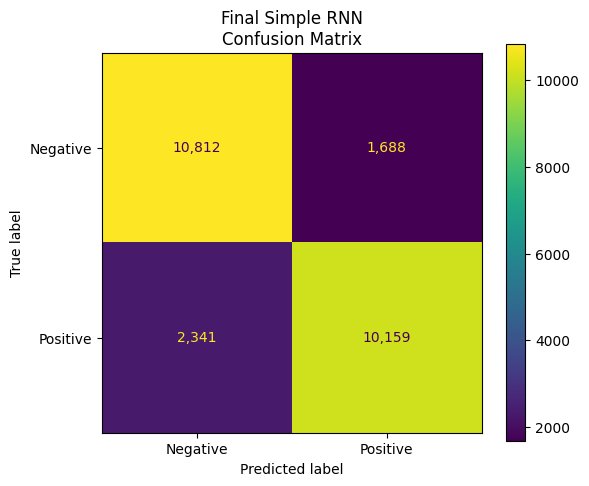

FINAL SIMPLE RNN — CONFUSION MATRIX VALUES
True Negatives  (TN) : 10,812
False Positives (FP) : 1,688
False Negatives (FN) : 2,341
True Positives  (TP) : 10,159

Total Correct         : 20,971
Total Errors          : 4,029


In [90]:
# ============================================================
# 9.8 FINAL SIMPLE RNN — CONFUSION MATRIX
# ============================================================

rnn_cm = confusion_matrix(
    y_test_neural,
    rnn_test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rnn_cm,
    display_labels=[
        "Negative",
        "Positive"
    ]
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

disp.plot(
    ax=ax,
    values_format=",d"
)

ax.set_title(
    "Final Simple RNN\nConfusion Matrix"
)

plt.tight_layout()
plt.show()


# ============================================================
# EXTRACT CONFUSION MATRIX VALUES
# ============================================================

tn_rnn, fp_rnn, fn_rnn, tp_rnn = (
    rnn_cm.ravel()
)

total_correct_rnn = (
    tn_rnn + tp_rnn
)

total_errors_rnn = (
    fp_rnn + fn_rnn
)


print("=" * 75)
print("FINAL SIMPLE RNN — CONFUSION MATRIX VALUES")
print("=" * 75)

print(
    f"True Negatives  (TN) : "
    f"{tn_rnn:,}"
)

print(
    f"False Positives (FP) : "
    f"{fp_rnn:,}"
)

print(
    f"False Negatives (FN) : "
    f"{fn_rnn:,}"
)

print(
    f"True Positives  (TP) : "
    f"{tp_rnn:,}"
)

print(
    f"\nTotal Correct         : "
    f"{total_correct_rnn:,}"
)

print(
    f"Total Errors          : "
    f"{total_errors_rnn:,}"
)

print("=" * 75)

### Observation — Final Simple RNN Confusion Matrix

The confusion matrix provides a more detailed view of the final Simple RNN's classification behavior.

The model correctly classified **10,812 Negative reviews** and **10,159 Positive reviews**, while producing **1,688 false positives** and **2,341 false negatives**.

The number of false negatives is higher than the number of false positives, which is consistent with the Positive-class recall being lower than its precision. In other words, the model is more likely to miss some genuinely Positive reviews than to incorrectly classify Negative reviews as Positive.

Overall, the confusion matrix supports the aggregate evaluation metrics and shows reasonably balanced classification performance across the two sentiment classes.

## 9.9 Optimized TF-IDF vs Simple RNN

The Simple RNN can now be compared directly with the optimized TF-IDF + Logistic Regression model using the same official IMDb test set.

Although the RNN processes reviews sequentially and learns trainable embeddings, greater architectural complexity does not automatically guarantee superior classification performance. The comparison therefore provides an empirical assessment of the strengths of the two approaches.

In [91]:
# ============================================================
# 9.9 OPTIMIZED TF-IDF VS FINAL SIMPLE RNN
# ============================================================

tfidf_rnn_comparison = pd.DataFrame({

    "Model": [
        "Optimized TF-IDF + Logistic Regression",
        "Simple RNN"
    ],

    "Representation": [
        "TF-IDF (Unigrams + Bigrams)",
        (
            "Trainable Embedding + "
            "SimpleRNN + Dense ReLU"
        )
    ],

    "Accuracy": [
        best_accuracy,
        rnn_accuracy
    ],

    "Precision": [
        best_precision,
        rnn_precision
    ],

    "Recall": [
        best_recall,
        rnn_recall
    ],

    "F1-score": [
        best_f1,
        rnn_f1
    ]
})


print("=" * 95)
print("OPTIMIZED TF-IDF VS FINAL SIMPLE RNN")
print("=" * 95)

display(
    tfidf_rnn_comparison.round(4)
)


# ============================================================
# PERFORMANCE DIFFERENCES
# ============================================================

rnn_minus_tfidf_accuracy = (
    rnn_accuracy - best_accuracy
)

rnn_minus_tfidf_precision = (
    rnn_precision - best_precision
)

rnn_minus_tfidf_recall = (
    rnn_recall - best_recall
)

rnn_minus_tfidf_f1 = (
    rnn_f1 - best_f1
)


print(
    "\nPerformance Difference "
    "— RNN Minus TF-IDF"
)

print(
    f"Accuracy difference  : "
    f"{rnn_minus_tfidf_accuracy:+.4f}"
)

print(
    f"Precision difference : "
    f"{rnn_minus_tfidf_precision:+.4f}"
)

print(
    f"Recall difference    : "
    f"{rnn_minus_tfidf_recall:+.4f}"
)

print(
    f"F1-score difference  : "
    f"{rnn_minus_tfidf_f1:+.4f}"
)

print("=" * 95)

OPTIMIZED TF-IDF VS FINAL SIMPLE RNN


,Model,Representation,Accuracy,Precision,Recall,F1-score
0,Optimized TF-IDF + Logistic Regression,TF-IDF (Unigrams + Bigrams),0.8958,0.8931,0.8994,0.8962
1,Simple RNN,Trainable Embedding + SimpleRNN + Dense ReLU,0.8388,0.8575,0.8127,0.8345



Performance Difference — RNN Minus TF-IDF
Accuracy difference  : -0.0570
Precision difference : -0.0356
Recall difference    : -0.0866
F1-score difference  : -0.0617


### Observation — Optimized TF-IDF vs Final Simple RNN

The optimized TF-IDF + Logistic Regression model outperformed the final Simple RNN across the reported test metrics.

The optimized TF-IDF model achieved **89.58% accuracy**, **89.31% precision**, **89.94% recall**, and an **F1-score of 89.62%**, whereas the final Simple RNN achieved **83.88% accuracy**, **85.75% precision**, **81.27% recall**, and an **F1-score of 83.45%**.

Therefore, the Simple RNN was lower by approximately **5.70 percentage points in accuracy**, **3.56 points in precision**, **8.67 points in recall**, and **6.17 points in F1-score**.

These results demonstrate that greater model complexity does not automatically guarantee better predictive performance. The optimized TF-IDF representation captures highly discriminative unigram and bigram sentiment patterns, while the Simple RNN must learn both its embeddings and sequential representation from the training data.

The Simple RNN also demonstrated overfitting in its unregularized baseline configuration. Although dropout and early stopping improved its generalization, the recurrent architecture still faces difficulty preserving information across long sequences. This provides a strong motivation for evaluating an **LSTM** model next.

## 9.10 Part D Summary

A complete **many-to-one Simple Recurrent Neural Network** was developed for IMDb sentiment classification using the following architecture:

**Integer Sequence Input → Embedding (128) → SimpleRNN (64) → Dense (32, ReLU) → Dense (1, Sigmoid)**

The baseline Simple RNN demonstrated **overfitting after its optimal validation checkpoint**: training performance continued to improve while validation performance deteriorated. Early stopping restored the best validation-loss checkpoint, and a controlled dropout experiment was subsequently performed to improve generalization.

Among the evaluated dropout configurations, `dropout = 0.2` was selected using validation performance only. The selected checkpoint achieved **83.90% validation accuracy** with a validation loss of **0.3868**.

On the untouched official IMDb test set, the final Simple RNN achieved **83.88% accuracy**, **85.75% precision**, **81.27% recall**, and an **F1-score of 83.45%**.

The optimized TF-IDF + Logistic Regression model remained stronger overall, demonstrating that increased neural complexity does not necessarily guarantee superior performance. Nevertheless, the RNN successfully introduced sequential modeling and established an important recurrent baseline.

The observed limitations of the Simple RNN, particularly its susceptibility to overfitting and difficulty modeling long-range dependencies, provide a clear motivation for the next stage: **LSTM**, which uses gated memory mechanisms to preserve information over longer sequences.

# 10. Part E — Long Short-Term Memory (LSTM)

After establishing the Simple RNN as the recurrent baseline, the recurrent layer is replaced with a **Long Short-Term Memory (LSTM)** layer to investigate whether gated memory provides stronger sentiment classification performance.

To ensure a fair comparison, the LSTM model uses the **same dataset split and a directly comparable architecture and training configuration** as the final Simple RNN.

The comparison therefore keeps the following components unchanged:

- the same development training subset,
- the same validation subset,
- the same untouched official IMDb test set,
- the same 500-token padded integer sequences,
- the same vocabulary size,
- the same 128-dimensional trainable Embedding layer,
- the same 64 recurrent units,
- the same 32-unit ReLU hidden Dense layer,
- the same dropout rate,
- the same Adam optimizer and learning rate,
- the same batch size,
- the same maximum number of epochs, and
- the same early-stopping and learning-rate reduction strategy.

The principal architectural change is therefore:

**SimpleRNN → LSTM**

This controlled design makes the final RNN–LSTM comparison more meaningful because improvements can be attributed primarily to the recurrent architecture rather than to different preprocessing, data partitions, or major hyperparameter changes.

# 10. Part E — Long Short-Term Memory (LSTM)

After establishing the Simple RNN as the recurrent baseline, the recurrent layer is replaced with a **Long Short-Term Memory (LSTM)** layer to investigate whether gated memory provides stronger sentiment classification performance.

To ensure a fair comparison, the LSTM model uses the **same dataset split and a directly comparable architecture and training configuration** as the final Simple RNN.

The comparison therefore keeps the following components unchanged:

- the same development training subset,
- the same validation subset,
- the same untouched official IMDb test set,
- the same 500-token padded integer sequences,
- the same vocabulary size,
- the same 128-dimensional trainable Embedding layer,
- the same 64 recurrent units,
- the same 32-unit ReLU hidden Dense layer,
- the same dropout rate,
- the same Adam optimizer and learning rate,
- the same batch size,
- the same maximum number of epochs, and
- the same early-stopping and learning-rate reduction strategy.

The principal architectural change is therefore:

**SimpleRNN → LSTM**

This controlled design makes the final RNN–LSTM comparison more meaningful because improvements can be attributed primarily to the recurrent architecture rather than to different preprocessing, data partitions, or major hyperparameter changes.

In [92]:
# ============================================================
# 10.1 FAIR RNN–LSTM COMPARISON SETUP
# ============================================================

# Use exactly the same split as the Simple RNN
X_lstm_train = X_rnn_train
X_lstm_val = X_rnn_val

y_lstm_train = y_rnn_train
y_lstm_val = y_rnn_val


# ============================================================
# USE COMPARABLE HYPERPARAMETERS
# ============================================================

LSTM_EMBEDDING_DIM = EMBEDDING_DIM
LSTM_UNITS = RNN_UNITS
LSTM_HIDDEN_UNITS = RNN_HIDDEN_UNITS

# Use the dropout rate selected for the final RNN
LSTM_DROPOUT = BEST_RNN_DROPOUT

LSTM_INITIAL_LR = RNN_INITIAL_LR
LSTM_EPOCHS = RNN_EPOCHS
LSTM_BATCH_SIZE = RNN_BATCH_SIZE
LSTM_EARLY_STOPPING_PATIENCE = RNN_EARLY_STOPPING_PATIENCE


print("=" * 75)
print("FAIR RNN–LSTM COMPARISON SETUP")
print("=" * 75)

print(f"Training input shape       : {X_lstm_train.shape}")
print(f"Validation input shape     : {X_lstm_val.shape}")
print(f"Test input shape           : {X_test_padded.shape}")

print(f"\nSequence length             : {MAX_SEQUENCE_LENGTH}")
print(f"Vocabulary size             : {NEURAL_VOCAB_SIZE}")
print(f"Embedding dimension         : {LSTM_EMBEDDING_DIM}")
print(f"Recurrent units             : {LSTM_UNITS}")
print(f"Hidden Dense units          : {LSTM_HIDDEN_UNITS}")
print(f"Dropout rate                : {LSTM_DROPOUT}")
print(f"Initial learning rate       : {LSTM_INITIAL_LR}")
print(f"Batch size                  : {LSTM_BATCH_SIZE}")
print(f"Maximum epochs              : {LSTM_EPOCHS}")

print("\nPrimary architecture change : SimpleRNN → LSTM")
print("New data split created      : No")
print("Test set used for training  : No")

print("=" * 75)

FAIR RNN–LSTM COMPARISON SETUP
Training input shape       : (20000, 500)
Validation input shape     : (5000, 500)
Test input shape           : (25000, 500)

Sequence length             : 500
Vocabulary size             : 19679
Embedding dimension         : 128
Recurrent units             : 64
Hidden Dense units          : 32
Dropout rate                : 0.2
Initial learning rate       : 0.001
Batch size                  : 128
Maximum epochs              : 12

Primary architecture change : SimpleRNN → LSTM
New data split created      : No
Test set used for training  : No


## 10.2 LSTM Architecture

The LSTM classifier follows the same many-to-one architecture used for the Simple RNN, with the recurrent layer replaced by an LSTM layer.

Each review is represented as a padded integer sequence of length 500. The Embedding layer transforms each token into a trainable 128-dimensional dense vector.

The LSTM layer contains 64 recurrent units and uses `return_sequences=False`, meaning that only the final LSTM representation is passed forward for sentiment classification. This preserves the same **many-to-one** design used by the Simple RNN.

The recurrent representation is then passed through a 32-unit Dense layer with ReLU activation, followed by a single-neuron Sigmoid output layer.

### Architecture

**Integer Sequence Input → Embedding (128) → LSTM (64) → Dense (32, ReLU) → Dense (1, Sigmoid)**

The architecture is intentionally kept comparable to the previous Simple RNN so that the recurrent mechanism itself remains the main experimental difference.

In [93]:
# ============================================================
# 10.2 LSTM MODEL BUILDER
# ============================================================


def build_lstm_model():
    """
    Build and compile a fresh many-to-one LSTM
    sentiment classifier using a setup comparable
    to the final Simple RNN.
    """

    # Clear previous Keras graph state
    tf.keras.backend.clear_session()

    # Reset random seeds for reproducibility
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    # Build a fresh LSTM model
    model = Sequential([

        # Fixed-length integer sequence input
        tf.keras.Input(
            shape=(MAX_SEQUENCE_LENGTH,),
            name="integer_sequence_input"
        ),

        # Trainable word embeddings
        Embedding(
            input_dim=NEURAL_VOCAB_SIZE,
            output_dim=LSTM_EMBEDDING_DIM,
            mask_zero=True,
            name="embedding"
        ),

        # Many-to-one LSTM layer
        LSTM(
            units=LSTM_UNITS,
            dropout=LSTM_DROPOUT,
            return_sequences=False,
            name="lstm"
        ),

        # Hidden nonlinear Dense layer
        Dense(
            units=LSTM_HIDDEN_UNITS,
            activation="relu",
            name="hidden_dense_relu"
        ),

        # Binary sentiment output
        Dense(
            units=1,
            activation="sigmoid",
            name="sentiment_output"
        )
    ])

    # Compile with the same optimizer configuration
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LSTM_INITIAL_LR
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Build model
lstm_model = build_lstm_model()


print("=" * 75)
print("LSTM ARCHITECTURE")
print("=" * 75)

lstm_model.summary()

print("\nArchitecture configuration:")
print(f"Vocabulary size       : {NEURAL_VOCAB_SIZE}")
print(f"Sequence length       : {MAX_SEQUENCE_LENGTH}")
print(f"Embedding dimension   : {LSTM_EMBEDDING_DIM}")
print(f"LSTM units            : {LSTM_UNITS}")
print(f"Hidden Dense units    : {LSTM_HIDDEN_UNITS}")
print(f"Dropout rate          : {LSTM_DROPOUT}")
print("Hidden activation     : ReLU")
print("Output activation     : Sigmoid")
print("Padding masking       : Enabled")
print("Sequence architecture : Many-to-one")

print("=" * 75)

LSTM ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     2,518,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_relu (Dense)       │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment_output (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,570,433 (9.81 MB)

 Trainable params: 2,570,433 (9.81 MB)

 Non-trainable params: 0 (0.00 B)


Architecture configuration:
Vocabulary size       : 19679
Sequence length       : 500
Embedding dimension   : 128
LSTM units            : 64
Hidden Dense units    : 32
Dropout rate          : 0.2
Hidden activation     : ReLU
Output activation     : Sigmoid
Padding masking       : Enabled
Sequence architecture : Many-to-one


### 10.2.1 Why Can LSTM Handle Long-Term Dependencies Better Than a Basic RNN?

A basic Simple RNN maintains a hidden state that is repeatedly updated as each token in a sequence is processed. During backpropagation through long sequences, gradients must propagate through many recurrent transformations. This can cause the **vanishing-gradient problem**, making it difficult for a Simple RNN to preserve and learn information from tokens that appeared much earlier in the sequence.

An LSTM addresses this limitation by introducing a dedicated **cell state** together with several learned gates that control the flow of information.

The main LSTM mechanisms are:

- **Forget gate:** determines which information from the previous cell state should be retained or discarded.
- **Input gate:** controls which new information should be written into the cell state.
- **Candidate information:** represents new content that may be added to memory.
- **Output gate:** determines which part of the internal memory should contribute to the current hidden state.

The cell state provides a more direct pathway through time, allowing useful information and gradients to persist across longer sequences.

Therefore, compared with a basic Simple RNN, an LSTM is generally better equipped to capture **long-term dependencies**, such as relationships between sentiment-bearing expressions that occur far apart in a movie review.

## 10.3 LSTM Training Configuration

To preserve experimental comparability, the LSTM uses the same main training configuration as the Simple RNN.

The model is trained for a maximum of 12 epochs using a batch size of 128 and the Adam optimizer with an initial learning rate of 0.001.

Validation loss is monitored throughout training.

`EarlyStopping` is used with the same patience value applied to the RNN and with `restore_best_weights=True`. Therefore, the final LSTM automatically returns to the weights associated with its lowest validation loss.

`ReduceLROnPlateau` is also applied using the same configuration as the RNN experiment.

The official IMDb test set remains completely untouched during training and validation.

In [94]:
# ============================================================
# 10.3 LSTM CALLBACKS
# ============================================================


def build_lstm_callbacks(verbose=1):
    """
    Create fresh callbacks for LSTM training.
    """

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=LSTM_EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=verbose
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=verbose
    )

    return [
        early_stopping,
        reduce_lr
    ]


print("=" * 70)
print("LSTM TRAINING CONFIGURATION")
print("=" * 70)

print(f"Maximum epochs          : {LSTM_EPOCHS}")
print(f"Batch size              : {LSTM_BATCH_SIZE}")
print(f"Initial learning rate   : {LSTM_INITIAL_LR}")
print(f"Dropout                 : {LSTM_DROPOUT}")
print("Optimizer               : Adam")
print("Loss function           : Binary Crossentropy")
print("Training metric         : Accuracy")
print("Validation monitor      : Validation Loss")
print("Early stopping          : Enabled")
print(
    f"Early stopping patience : "
    f"{LSTM_EARLY_STOPPING_PATIENCE}"
)
print("Restore best weights    : Enabled")
print("Learning-rate reduction : Enabled")
print("Test set used           : No")

print("=" * 70)

LSTM TRAINING CONFIGURATION
Maximum epochs          : 12
Batch size              : 128
Initial learning rate   : 0.001
Dropout                 : 0.2
Optimizer               : Adam
Loss function           : Binary Crossentropy
Training metric         : Accuracy
Validation monitor      : Validation Loss
Early stopping          : Enabled
Early stopping patience : 3
Restore best weights    : Enabled
Learning-rate reduction : Enabled
Test set used           : No


## 10.4 LSTM Training

The LSTM model is trained from scratch using exactly the same development training and validation subsets used by the Simple RNN.

No test-set information is used during training.

The best epoch is defined by the minimum validation loss, consistent with the checkpoint-selection procedure used for the recurrent baseline.

In [95]:
# ============================================================
# 10.4 TRAIN LSTM FROM SCRATCH
# ============================================================

# Build a completely fresh model
lstm_model = build_lstm_model()

# Create fresh callbacks
lstm_callbacks = build_lstm_callbacks(
    verbose=1
)

# Train the model
lstm_history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    validation_data=(
        X_lstm_val,
        y_lstm_val
    ),
    epochs=LSTM_EPOCHS,
    batch_size=LSTM_BATCH_SIZE,
    callbacks=lstm_callbacks,
    verbose=1
)


# ============================================================
# IDENTIFY BEST VALIDATION CHECKPOINT
# ============================================================

lstm_best_epoch_index = int(
    np.argmin(
        lstm_history.history["val_loss"]
    )
)

LSTM_BEST_EPOCH = (
    lstm_best_epoch_index + 1
)

LSTM_BEST_VAL_LOSS = (
    lstm_history.history["val_loss"][
        lstm_best_epoch_index
    ]
)

LSTM_VAL_ACCURACY_AT_BEST_LOSS = (
    lstm_history.history["val_accuracy"][
        lstm_best_epoch_index
    ]
)

LSTM_MAX_VAL_ACCURACY = max(
    lstm_history.history["val_accuracy"]
)


# ============================================================
# VERIFY RESTORED MODEL
# ============================================================

lstm_verified_val_loss, lstm_verified_val_accuracy = (
    lstm_model.evaluate(
        X_lstm_val,
        y_lstm_val,
        batch_size=LSTM_BATCH_SIZE,
        verbose=0
    )
)


print("\n" + "=" * 75)
print("LSTM TRAINING SUMMARY")
print("=" * 75)

print(
    f"Epochs completed                  : "
    f"{len(lstm_history.history['loss'])}"
)

print(
    f"Best epoch by validation loss     : "
    f"{LSTM_BEST_EPOCH}"
)

print(
    f"Lowest validation loss            : "
    f"{LSTM_BEST_VAL_LOSS:.4f}"
)

print(
    f"Validation accuracy at best loss  : "
    f"{LSTM_VAL_ACCURACY_AT_BEST_LOSS:.4f}"
)

print(
    f"Maximum validation accuracy       : "
    f"{LSTM_MAX_VAL_ACCURACY:.4f}"
)

print(
    f"Verified restored val accuracy    : "
    f"{lstm_verified_val_accuracy:.4f}"
)

print(
    f"Verified restored val loss        : "
    f"{lstm_verified_val_loss:.4f}"
)

print("=" * 75)

Epoch 1/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.7463 - loss: 0.5191 - val_accuracy: 0.8620 - val_loss: 0.3463 - learning_rate: 0.0010
Epoch 2/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.8977 - loss: 0.2635 - val_accuracy: 0.8618 - val_loss: 0.3258 - learning_rate: 0.0010
Epoch 3/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9303 - loss: 0.1936
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.9259 - loss: 0.2079 - val_accuracy: 0.8636 - val_loss: 0.3765 - learning_rate: 0.0010
Epoch 4/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9546 - loss: 0.1351
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.9572 - loss: 0.1274 - val_accuracy: 0.8694 - val_loss: 0.3705 - learning_rate: 5.0000e-04
Epoch 5/12
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9736 - los

### Observation — LSTM Training Behavior

The LSTM completed training after **5 epochs**, with `EarlyStopping` restoring the model weights from **epoch 2**, which achieved the minimum validation loss.

At the best validation-loss checkpoint, the model achieved a validation accuracy of **86.18%** with a validation loss of **0.3258**.

Although validation accuracy later reached a maximum of **86.94%**, validation loss increased after epoch 2. At the same time, training accuracy continued to rise substantially, reaching approximately **97.54%** by epoch 5, while training loss decreased to approximately **0.0805**.

This divergence between continuously improving training performance and deteriorating validation loss indicates the beginning of **overfitting after the optimal validation checkpoint**.

The use of early stopping successfully prevented the later overfitted epochs from determining the final model state by restoring the weights associated with the lowest validation loss.

The restored model was verified independently and reproduced exactly **86.18% validation accuracy** and **0.3258 validation loss**, confirming that the correct checkpoint was retained for final evaluation.

## 10.5 LSTM Learning Curves

Training and validation learning curves are plotted to analyze the optimization and generalization behavior of the LSTM across epochs.

The accuracy curves compare predictive performance on the training and validation subsets, while the loss curves show how the optimization objective changes during training.

Together, these plots will be used to evaluate whether the LSTM demonstrates stable learning, overfitting, or underfitting.

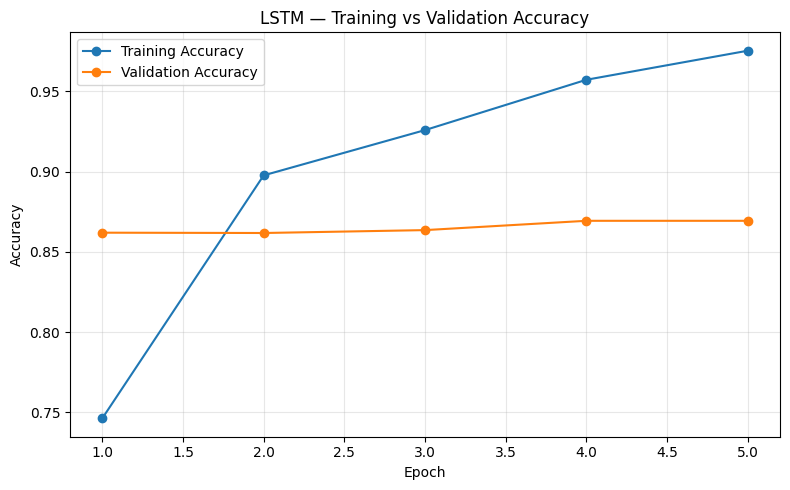

In [96]:
# ============================================================
# 10.5 LSTM — TRAINING VS VALIDATION ACCURACY
# ============================================================

lstm_epochs_range = range(
    1,
    len(
        lstm_history.history["accuracy"]
    ) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    lstm_epochs_range,
    lstm_history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    lstm_epochs_range,
    lstm_history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title(
    "LSTM — Training vs Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

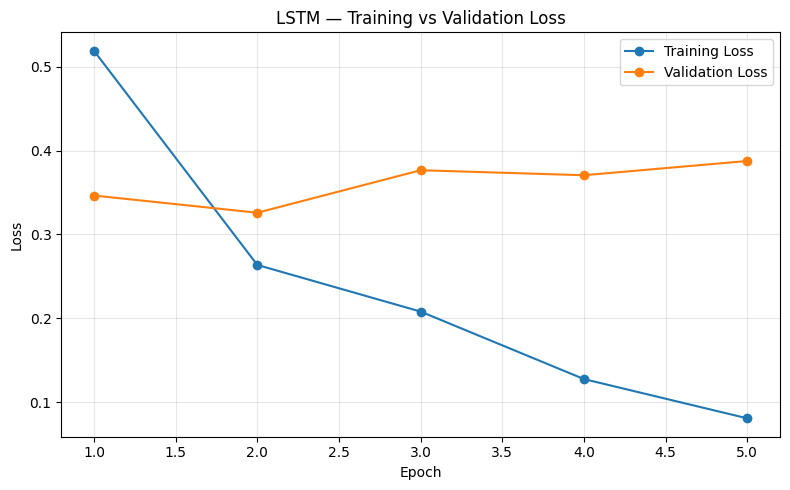

In [97]:
# ============================================================
# 10.5 LSTM — TRAINING VS VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    lstm_epochs_range,
    lstm_history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    lstm_epochs_range,
    lstm_history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title(
    "LSTM — Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation — LSTM Learning Curves

The LSTM learning curves show strong early learning followed by increasing separation between training and validation performance.

Training accuracy increased consistently from approximately **74.63%** in epoch 1 to **97.54%** by epoch 5. In contrast, validation accuracy remained relatively stable between approximately **86.18% and 86.94%** after the first epoch.

The loss curves provide clearer evidence of the model's generalization behavior. Training loss decreased continuously from approximately **0.5191** to **0.0805**, while validation loss reached its minimum value of **0.3258 at epoch 2** and then increased to **0.3765**, **0.3705**, and **0.3875** in the following epochs.

Therefore, the LSTM demonstrates **overfitting after epoch 2**. The model continues fitting the training data more strongly without producing corresponding improvements in validation performance.

However, this behavior is effectively controlled by `EarlyStopping`, which restores the model weights from epoch 2. Consequently, the final evaluated LSTM corresponds to the strongest validation-loss checkpoint rather than the later overfitted epochs.

## 10.6 Final LSTM Test Evaluation

After training and validation are complete, the restored LSTM checkpoint associated with the lowest validation loss is evaluated on the untouched official IMDb test set.

The same evaluation metrics used for the Simple RNN are calculated:

- Accuracy
- Precision
- Recall
- F1-score
- Classification Report

Using the same metrics and the same official test set enables a direct and consistent comparison between the LSTM and Simple RNN models.

In [98]:
# ============================================================
# 10.6 FINAL LSTM — TEST EVALUATION
# ============================================================

# Generate sentiment probabilities
lstm_test_probabilities = lstm_model.predict(
    X_test_padded,
    batch_size=LSTM_BATCH_SIZE,
    verbose=1
).ravel()

# Convert probabilities to binary predictions
lstm_test_predictions = (
    lstm_test_probabilities >= 0.5
).astype(int)


# ============================================================
# CALCULATE TEST METRICS
# ============================================================

lstm_accuracy = accuracy_score(
    y_test_neural,
    lstm_test_predictions
)

lstm_precision = precision_score(
    y_test_neural,
    lstm_test_predictions,
    zero_division=0
)

lstm_recall = recall_score(
    y_test_neural,
    lstm_test_predictions,
    zero_division=0
)

lstm_f1 = f1_score(
    y_test_neural,
    lstm_test_predictions,
    zero_division=0
)


# ============================================================
# DISPLAY TEST PERFORMANCE
# ============================================================

print("=" * 75)
print("FINAL LSTM — TEST PERFORMANCE")
print("=" * 75)

print(
    f"Best Val Epoch : "
    f"{LSTM_BEST_EPOCH}"
)

print(
    f"Accuracy       : "
    f"{lstm_accuracy:.4f}"
)

print(
    f"Precision      : "
    f"{lstm_precision:.4f}"
)

print(
    f"Recall         : "
    f"{lstm_recall:.4f}"
)

print(
    f"F1-score       : "
    f"{lstm_f1:.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test_neural,
        lstm_test_predictions,
        target_names=[
            "Negative",
            "Positive"
        ],
        digits=4,
        zero_division=0
    )
)

print("=" * 75)

196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
FINAL LSTM — TEST PERFORMANCE
Best Val Epoch : 2
Accuracy       : 0.8536
Precision      : 0.8872
Recall         : 0.8103
F1-score       : 0.8470

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8254    0.8970    0.8597     12500
    Positive     0.8872    0.8103    0.8470     12500

    accuracy                         0.8536     25000
   macro avg     0.8563    0.8536    0.8534     25000
weighted avg     0.8563    0.8536    0.8534     25000



### Observation — Final LSTM Test Performance

The final LSTM achieved an **accuracy of 85.36%**, **precision of 88.72%**, **recall of 81.03%**, and an **F1-score of 84.70%** on the untouched official IMDb test set.

The selected validation checkpoint achieved **86.18% validation accuracy**, while test accuracy was **85.36%**, corresponding to a relatively small difference of approximately **0.82 percentage points**.

This indicates that the validation-selected LSTM checkpoint generalizes reasonably well to unseen test data despite the overfitting observed in later training epochs.

For the Positive class, precision (**88.72%**) is noticeably higher than recall (**81.03%**). This indicates that when the model predicts Positive sentiment, its predictions are relatively reliable, but it misses a proportion of genuinely Positive reviews.

The Negative class achieved a precision of **82.54%**, recall of **89.70%**, and F1-score of **85.97%**, while the Positive class achieved an F1-score of **84.70%**.

Overall, the LSTM provides strong and reasonably balanced sentiment classification performance on the official test set.

## 10.7 LSTM vs Simple RNN Comparison

The final LSTM is compared directly with the final selected Simple RNN using the same official IMDb test set.

Both models use the same sequence representation, development split, embedding dimensionality, recurrent-unit count, hidden Dense layer, dropout rate, optimizer configuration, training strategy, and evaluation metrics.

This controlled comparison is designed to isolate the effect of replacing the basic recurrent mechanism with the gated LSTM architecture.

In [99]:
# ============================================================
# 10.7 LSTM VS SIMPLE RNN
# ============================================================

rnn_lstm_comparison = pd.DataFrame({

    "Model": [
        "Simple RNN",
        "LSTM"
    ],

    "Recurrent Layer": [
        "SimpleRNN",
        "LSTM"
    ],

    "Accuracy": [
        rnn_accuracy,
        lstm_accuracy
    ],

    "Precision": [
        rnn_precision,
        lstm_precision
    ],

    "Recall": [
        rnn_recall,
        lstm_recall
    ],

    "F1-score": [
        rnn_f1,
        lstm_f1
    ]
})


print("=" * 85)
print("SIMPLE RNN VS LSTM — TEST PERFORMANCE")
print("=" * 85)

display(
    rnn_lstm_comparison.round(4)
)


# ============================================================
# CALCULATE LSTM MINUS RNN DIFFERENCES
# ============================================================

lstm_minus_rnn_accuracy = (
    lstm_accuracy - rnn_accuracy
)

lstm_minus_rnn_precision = (
    lstm_precision - rnn_precision
)

lstm_minus_rnn_recall = (
    lstm_recall - rnn_recall
)

lstm_minus_rnn_f1 = (
    lstm_f1 - rnn_f1
)


print(
    "\nPerformance Difference "
    "— LSTM Minus Simple RNN"
)

print(
    f"Accuracy difference  : "
    f"{lstm_minus_rnn_accuracy:+.4f}"
)

print(
    f"Precision difference : "
    f"{lstm_minus_rnn_precision:+.4f}"
)

print(
    f"Recall difference    : "
    f"{lstm_minus_rnn_recall:+.4f}"
)

print(
    f"F1-score difference  : "
    f"{lstm_minus_rnn_f1:+.4f}"
)

print("=" * 85)

SIMPLE RNN VS LSTM — TEST PERFORMANCE


,Model,Recurrent Layer,Accuracy,Precision,Recall,F1-score
0,Simple RNN,SimpleRNN,0.8388,0.8575,0.8127,0.8345
1,LSTM,LSTM,0.8536,0.8872,0.8103,0.8470



Performance Difference — LSTM Minus Simple RNN
Accuracy difference  : +0.0148
Precision difference : +0.0297
Recall difference    : -0.0024
F1-score difference  : +0.0125


### Observation — LSTM vs Simple RNN

The LSTM outperformed the Simple RNN on most of the main test metrics under the controlled experimental setup.

The Simple RNN achieved **83.88% accuracy**, **85.75% precision**, **81.27% recall**, and an **F1-score of 83.45%**.

In comparison, the LSTM achieved **85.36% accuracy**, **88.72% precision**, **81.03% recall**, and an **F1-score of 84.70%**.

Relative to the Simple RNN, the LSTM improved:

- **Accuracy by 1.48 percentage points**
- **Precision by 2.97 percentage points**
- **F1-score by 1.25 percentage points**

Recall decreased only slightly by approximately **0.24 percentage points**.

Therefore, the LSTM provides better overall classification performance than the Simple RNN, particularly in terms of accuracy, precision, and F1-score.

Because both models use the same data split, sequence representation, embedding dimensionality, recurrent-unit count, hidden Dense layer, dropout rate, optimizer configuration, batch size, and training strategy, this improvement provides evidence that the LSTM's gated memory mechanism offers a more effective recurrent representation than the basic SimpleRNN architecture for this sentiment-classification task.

## 10.8 Part E Summary

A many-to-one **Long Short-Term Memory (LSTM)** sentiment classifier was developed by replacing the SimpleRNN layer with an LSTM layer while preserving a directly comparable experimental setup.

The final architecture was:

**Integer Sequence Input → Embedding (128) → LSTM (64) → Dense (32, ReLU) → Dense (1, Sigmoid)**

The LSTM used exactly the same training, validation, and test partitions as the Simple RNN, together with the same sequence length, vocabulary, embedding dimensionality, recurrent hidden size, hidden Dense layer, dropout rate, optimizer, learning rate, batch size, epoch limit, and callback strategy.

During training, validation loss reached its minimum value of **0.3258 at epoch 2**, where validation accuracy was **86.18%**. Training performance continued to improve after this point while validation loss increased, indicating **overfitting in the later epochs**.

Early stopping successfully controlled this behavior by restoring the weights from epoch 2 before final evaluation.

On the untouched official IMDb test set, the final LSTM achieved:

- **Accuracy:** 85.36%
- **Precision:** 88.72%
- **Recall:** 81.03%
- **F1-score:** 84.70%

Compared with the Simple RNN, the LSTM improved accuracy by **1.48 percentage points**, precision by **2.97 percentage points**, and F1-score by **1.25 percentage points**, while recall decreased slightly by only **0.24 percentage points**.

The improvement supports the theoretical advantage of LSTM networks for sequential modeling. Unlike a basic RNN, an LSTM uses a persistent cell state together with forget, input, and output gates to regulate information flow. This architecture allows useful information and gradients to persist across longer sequences and therefore reduces the difficulty of learning long-term dependencies.

Overall, the LSTM produced stronger test performance than the Simple RNN and represents the stronger recurrent model in the current experiment.

# 11. Part F — Pretrained Transformer for Sentiment Analysis

This section introduces Transformer-based sentiment classification using a **pretrained model** rather than constructing a Transformer architecture from scratch.

The objective is to understand the core Transformer concepts and apply an existing pretrained sentiment-analysis model to IMDb reviews.

The experiment focuses on:

- understanding Attention and Self-Attention,
- understanding Query, Key, Value, and Positional Information,
- explaining why Transformers can be trained more efficiently than recurrent models,
- applying a pretrained Hugging Face Transformer,
- generating sentiment predictions for at least 10 reviews, and
- comparing those predictions with the true sentiment labels.

## 11.1 Core Transformer Concepts

### Attention

Attention allows a model to focus more strongly on the parts of a sequence that are most relevant to the current prediction.

For sentiment analysis, not every word contributes equally to the final sentiment. For example, words such as *excellent*, *terrible*, or *not enjoyable* may carry much more useful information than neutral words.

Attention allows the model to assign different importance to different tokens instead of treating every token as equally informative.

### Self-Attention

Self-Attention means that every token in a sequence can examine the other tokens in the same sequence and determine which ones are relevant to its representation.

For example, in the sentence:

**"The movie was not good."**

the word *good* should be interpreted together with *not*. Self-Attention allows these tokens to directly interact even if they are separated by other words.

### Query, Key, and Value

Self-Attention represents every token using three learned vectors:

- **Query (Q):** represents what the current token is looking for.
- **Key (K):** represents what information a token can offer.
- **Value (V):** contains the actual information associated with that token.

The Query of one token is compared with the Keys of other tokens to calculate attention scores.

Tokens receiving larger attention scores contribute more strongly through their Value vectors.

In simple terms:

**Query asks what is relevant → Key determines how relevant each token is → Value provides the information that is passed forward.**

### Positional Information

Unlike RNNs and LSTMs, Transformers do not process tokens one after another in recurrent order.

Therefore, the model needs an additional way to understand token positions and word order.

**Positional information** is added to token representations so the Transformer can distinguish between different positions in the sequence.

This allows the model to understand that:

**"dog bites man"**

and

**"man bites dog"**

contain the same words but have different meanings because their positions are different.

## 11.2 Why Transformers Can Process Sequences More Efficiently During Training

Recurrent models such as Simple RNNs and LSTMs process a sequence sequentially.

The hidden state at time step `t` depends on the hidden state from time step `t-1`. Therefore, later tokens cannot be fully processed until earlier tokens have already been processed.

This sequential dependency limits parallel computation during training.

Transformers remove this recurrent dependency.

Using Self-Attention, all tokens in a sequence can be processed simultaneously. The attention mechanism directly calculates relationships between tokens without requiring information to pass through every previous time step.

This provides two important advantages:

1. **Parallel processing during training**  
   Multiple tokens can be processed at the same time, allowing efficient use of modern GPUs and other parallel hardware.

2. **Direct modeling of long-range relationships**  
   A token can attend directly to another distant token without information having to pass through many recurrent steps.

As a result, Transformers generally allow more efficient parallel training than recurrent architectures and can model long-distance relationships more directly.

## 11.3 Pretrained Transformer Model

A pretrained Transformer sentiment classifier is used through the Hugging Face `transformers` library.

The selected model is:

**`distilbert-base-uncased-finetuned-sst-2-english`**

This model is based on DistilBERT and has already been fine-tuned for binary sentiment classification.

No Transformer architecture is built or trained from scratch in this experiment.

The pretrained model is used only for inference on selected IMDb reviews.

In [100]:
# ============================================================
# 11.3 LOAD PRETRAINED HUGGING FACE SENTIMENT MODEL
# ============================================================

# Install transformers if it is not already available
try:
    from transformers import pipeline
except ImportError:
    !pip install -q transformers
    from transformers import pipeline


# Create pretrained sentiment-analysis pipeline
transformer_sentiment = pipeline(
    task="sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

print("=" * 75)
print("PRETRAINED TRANSFORMER LOADED")
print("=" * 75)

print(
    "Model : distilbert-base-uncased-finetuned-sst-2-english"
)

print(
    "Task  : Binary sentiment classification"
)

print(
    "Transformer trained from scratch : No"
)

print("=" * 75)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

PRETRAINED TRANSFORMER LOADED
Model : distilbert-base-uncased-finetuned-sst-2-english
Task  : Binary sentiment classification
Transformer trained from scratch : No


## 11.4 Transformer Predictions on IMDb Reviews

At least 10 reviews are selected from the official IMDb test set.

The pretrained Transformer receives the review text directly rather than the integer sequences used by the RNN and LSTM models.

The true IMDb labels are preserved so that Transformer predictions can be compared directly with the actual sentiment classes.



In [104]:
# ============================================================
# 11.4 SELECT 50 IMDb TEST REVIEWS FOR TRANSFORMER INFERENCE
# ============================================================

N_TRANSFORMER_REVIEWS = 50

# Select the first 50 decoded reviews from the official test set
transformer_reviews = test_reviews[:N_TRANSFORMER_REVIEWS]

# Select their corresponding true sentiment labels
transformer_true_labels = y_test[:N_TRANSFORMER_REVIEWS]

# Verify the selected sample
print("=" * 75)
print("TRANSFORMER INFERENCE SAMPLE")
print("=" * 75)

print(f"Number of reviews selected : {len(transformer_reviews)}")
print(f"Number of true labels      : {len(transformer_true_labels)}")

print("\nTrue-label distribution:")
print(
    pd.Series(transformer_true_labels)
    .map({0: "Negative", 1: "Positive"})
    .value_counts()
)

print("=" * 75)

TRANSFORMER INFERENCE SAMPLE
Number of reviews selected : 50
Number of true labels      : 50

True-label distribution:
Positive    27
Negative    23
Name: count, dtype: int64


In [105]:
# ============================================================
# 11.5 RUN PRETRAINED TRANSFORMER PREDICTIONS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Run pretrained Transformer inference
transformer_outputs = transformer_sentiment(
    list(transformer_reviews),
    truncation=True
)


# ============================================================
# CONVERT MODEL LABELS TO BINARY LABELS
# ============================================================

transformer_predicted_labels = [
    1 if output["label"] == "POSITIVE" else 0
    for output in transformer_outputs
]


# ============================================================
# CREATE PREDICTION COMPARISON TABLE
# ============================================================

transformer_results_df = pd.DataFrame({
    "Review ID": range(1, N_TRANSFORMER_REVIEWS + 1),

    "True Label": [
        "Positive" if label == 1 else "Negative"
        for label in transformer_true_labels
    ],

    "Predicted Label": [
        "Positive" if label == 1 else "Negative"
        for label in transformer_predicted_labels
    ],

    "Confidence": [
        output["score"]
        for output in transformer_outputs
    ],

    "Correct": [
        true == pred
        for true, pred in zip(
            transformer_true_labels,
            transformer_predicted_labels
        )
    ]
})


print("=" * 90)
print("PRETRAINED TRANSFORMER — PREDICTIONS VS TRUE LABELS")
print("=" * 90)

display(
    transformer_results_df.style.format({
        "Confidence": "{:.4f}"
    })
)


# ============================================================
# CALCULATE SAMPLE EVALUATION METRICS
# ============================================================

transformer_accuracy = accuracy_score(
    transformer_true_labels,
    transformer_predicted_labels
)

transformer_precision = precision_score(
    transformer_true_labels,
    transformer_predicted_labels,
    zero_division=0
)

transformer_recall = recall_score(
    transformer_true_labels,
    transformer_predicted_labels,
    zero_division=0
)

transformer_f1 = f1_score(
    transformer_true_labels,
    transformer_predicted_labels,
    zero_division=0
)


# ============================================================
# DISPLAY METRICS
# ============================================================

print("\n" + "=" * 75)
print("PRETRAINED TRANSFORMER — SAMPLE PERFORMANCE")
print("=" * 75)

print(f"Number of evaluated reviews : {N_TRANSFORMER_REVIEWS}")
print(f"Accuracy                    : {transformer_accuracy:.4f}")
print(f"Precision                   : {transformer_precision:.4f}")
print(f"Recall                      : {transformer_recall:.4f}")
print(f"F1-score                    : {transformer_f1:.4f}")

print("=" * 75)

PRETRAINED TRANSFORMER — PREDICTIONS VS TRUE LABELS


,Review ID,True Label,Predicted Label,Confidence,Correct
0,1,Negative,Negative,0.9997,True
1,2,Positive,Positive,0.9995,True
2,3,Positive,Positive,0.9649,True
3,4,Negative,Negative,0.9934,True
4,5,Positive,Positive,0.9997,True
5,6,Positive,Negative,0.9985,False
6,7,Positive,Negative,0.9859,False
7,8,Negative,Negative,0.9987,True
8,9,Negative,Negative,0.9860,True
9,10,Positive,Positive,0.9900,True



PRETRAINED TRANSFORMER — SAMPLE PERFORMANCE
Number of evaluated reviews : 50
Accuracy                    : 0.9000
Precision                   : 0.9583
Recall                      : 0.8519
F1-score                    : 0.9020


### Observation — Pretrained Transformer Performance

The pretrained DistilBERT sentiment classifier was evaluated on **50 reviews** selected from the official IMDb test set. The evaluated sample contained **27 Positive reviews** and **23 Negative reviews**, providing a reasonably balanced subset for this inference experiment.

The Transformer achieved:

- **Accuracy:** 90.00%
- **Precision:** 95.83%
- **Recall:** 85.19%
- **F1-score:** 90.20%

The model correctly classified **45 out of 50 reviews**, while only **5 reviews were misclassified**.

Among the 27 truly Positive reviews, **23 were correctly identified as Positive**, while **4 were incorrectly classified as Negative**. Among the 23 truly Negative reviews, **22 were correctly classified as Negative**, while only **1 was incorrectly classified as Positive**.

The particularly high Positive-class precision of **95.83%** indicates that Positive predictions were highly reliable within this sample. Recall was lower at **85.19%**, showing that the model was more likely to miss some Positive reviews than to incorrectly label Negative reviews as Positive.

The confidence scores also reveal an important limitation. Some incorrect predictions were produced with very high confidence. For example, Reviews 6 and 7 were incorrectly classified as Negative with confidence scores of approximately **99.85%** and **98.59%**, respectively. Therefore, prediction confidence should not be interpreted as a guarantee of correctness.

Overall, the pretrained Transformer demonstrated strong sentiment-classification performance on the selected IMDb sample, achieving both **90.00% accuracy** and an **F1-score above 90%** without constructing or training a Transformer architecture from scratch.

Because these metrics are calculated from a selected sample of 50 test reviews rather than the complete 25,000-review test set, they should be interpreted as **sample-level Transformer performance** rather than a directly equivalent full-test benchmark.

## 11.6 Part F Summary

A pretrained Transformer was successfully applied to IMDb sentiment classification without building or training a Transformer architecture from scratch.

The experiment used the pretrained **DistilBERT sentiment-analysis model** `distilbert-base-uncased-finetuned-sst-2-english` through the Hugging Face Transformers library.

The fundamental Transformer concepts were examined, including **Attention, Self-Attention, Query, Key, Value, and Positional Information**. Attention enables the model to identify which tokens are most relevant to one another, while Self-Attention allows tokens within the same sequence to interact directly. Query, Key, and Value representations determine how these relationships are calculated, while positional information provides the model with information about token order.

Transformers also differ fundamentally from recurrent architectures during training. RNNs and LSTMs process sequences through recurrent dependencies between consecutive time steps, which limits parallel computation. Transformers remove this recurrent dependency and use Self-Attention to process token relationships in parallel, enabling more efficient utilization of modern parallel hardware during training and more direct modeling of long-range relationships.

For practical evaluation, the pretrained Transformer was applied to **50 reviews from the official IMDb test set**, exceeding the minimum requirement of 10 reviews. The sample contained 27 Positive and 23 Negative reviews.

The model achieved:

- **Accuracy:** 90.00%
- **Precision:** 95.83%
- **Recall:** 85.19%
- **F1-score:** 90.20%

The Transformer correctly classified **45 of the 50 reviews**. Most errors involved Positive reviews being classified as Negative, which explains why precision was higher than recall.

Overall, the experiment demonstrates both the conceptual advantages and practical application of pretrained Transformer models for sentiment classification. The pretrained DistilBERT model produced strong predictions directly from review text without requiring a Transformer to be constructed or trained from scratch.

The reported Transformer metrics represent performance on the selected 50-review sample. Therefore, they should be distinguished from the full-test metrics reported for the TF-IDF, Simple RNN, and LSTM models when constructing the final model comparison.

# 12. Final Model Comparison

The final stage compares the sentiment-classification approaches developed throughout the project.

The comparison includes:

- **TF-IDF + Logistic Regression** using sparse TF-IDF features,
- **Simple RNN** using learned word embeddings,
- **LSTM** using learned word embeddings, and
- **Pretrained Transformer (DistilBERT)** using contextual representations.

The models are compared using **Accuracy, Precision, Recall, and F1-score** based exclusively on the results obtained from the experiments performed in this notebook.

> **Evaluation Note:** TF-IDF + Logistic Regression, Simple RNN, and LSTM were evaluated on the complete official IMDb test set of 25,000 reviews. The pretrained Transformer metrics were calculated from the 50-review inference sample required for the Transformer experiment. Therefore, the Transformer values should be interpreted as sample-level results rather than a directly equivalent full-test benchmark.

In [107]:
# ============================================================
# 12.1 FINAL MODEL COMPARISON
# ============================================================

final_comparison_df = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "Simple RNN",
        "LSTM",
        "Pretrained Transformer (DistilBERT)"
    ],

    "Representation": [
        "TF-IDF",
        "Embedding",
        "Embedding",
        "Contextual Embeddings"
    ],

    "Accuracy": [
        best_accuracy,
        rnn_accuracy,
        lstm_accuracy,
        transformer_accuracy
    ],

    "Precision": [
        best_precision,
        rnn_precision,
        lstm_precision,
        transformer_precision
    ],

    "Recall": [
        best_recall,
        rnn_recall,
        lstm_recall,
        transformer_recall
    ],

    "F1": [
        best_f1,
        rnn_f1,
        lstm_f1,
        transformer_f1
    ],

    "Evaluation Size": [
        25000,
        25000,
        25000,
        50
    ]
})


# ============================================================
# CREATE DISPLAY VERSION
# ============================================================

final_comparison_display = final_comparison_df.copy()

for metric in ["Accuracy", "Precision", "Recall", "F1"]:
    final_comparison_display[metric] = (
        final_comparison_display[metric] * 100
    )


# ============================================================
# DISPLAY FINAL COMPARISON TABLE
# ============================================================

print("=" * 110)
print("FINAL SENTIMENT CLASSIFICATION MODEL COMPARISON")
print("=" * 110)

display(
    final_comparison_display.style.format({
        "Accuracy": "{:.2f}%",
        "Precision": "{:.2f}%",
        "Recall": "{:.2f}%",
        "F1": "{:.2f}%",
        "Evaluation Size": "{:,}"
    })
)

print("=" * 110)
print(
    "Evaluation note: TF-IDF + Logistic Regression, Simple RNN, "
    "and LSTM were evaluated on the complete 25,000-review test set."
)
print(
    "The pretrained Transformer was evaluated on the selected "
    "50-review test sample."
)
print("=" * 110)

FINAL SENTIMENT CLASSIFICATION MODEL COMPARISON


,Model,Representation,Accuracy,Precision,Recall,F1,Evaluation Size
0,TF-IDF + Logistic Regression,TF-IDF,89.58%,89.31%,89.94%,89.62%,"25,000"
1,Simple RNN,Embedding,83.88%,85.75%,81.27%,83.45%,"25,000"
2,LSTM,Embedding,85.36%,88.72%,81.03%,84.70%,"25,000"
3,Pretrained Transformer (DistilBERT),Contextual Embeddings,90.00%,95.83%,85.19%,90.20%,50


Evaluation note: TF-IDF + Logistic Regression, Simple RNN, and LSTM were evaluated on the complete 25,000-review test set.
The pretrained Transformer was evaluated on the selected 50-review test sample.


## 12.2 Final Model Comparison — Observation

The final comparison demonstrates clear differences among the four sentiment-classification approaches.

Among the models evaluated on the complete **25,000-review official IMDb test set**, the optimized **TF-IDF + Logistic Regression** model achieved the strongest overall performance, with **89.58% accuracy**, **89.31% precision**, **89.94% recall**, and an **F1-score of 89.62%**.

The **Simple RNN** achieved **83.88% accuracy** and an **F1-score of 83.45%**, representing the lowest overall performance among the three models evaluated on the complete test set.

Replacing the Simple RNN with an **LSTM** improved accuracy from **83.88% to 85.36%**, precision from **85.75% to 88.72%**, and F1-score from **83.45% to 84.70%**. Recall decreased slightly from **81.27% to 81.03%**. Therefore, the LSTM provided better overall performance than the basic RNN, although it did not outperform the optimized TF-IDF classifier.

The pretrained **DistilBERT Transformer** achieved **90.00% accuracy**, **95.83% precision**, **85.19% recall**, and an **F1-score of 90.20%** on the selected 50-review test sample. These are the highest observed accuracy, precision, and F1 values in the table.

However, the Transformer results are **not directly equivalent to the full-test results of the other models**, because DistilBERT was evaluated on only **50 reviews**, whereas TF-IDF, RNN, and LSTM were evaluated on **25,000 reviews**. Consequently, the Transformer results demonstrate strong sample-level performance but should not be used to claim that DistilBERT definitively outperforms the other models on the complete IMDb test set.

Overall, the experiment shows that model complexity does not automatically guarantee better performance. The optimized TF-IDF + Logistic Regression approach remained highly competitive and produced the strongest directly comparable full-test performance, while the LSTM improved upon the Simple RNN and the pretrained Transformer demonstrated strong contextual sentiment-classification capability on the evaluated sample.

# 13. Final Conclusions

This project developed and evaluated multiple Natural Language Processing approaches for **binary sentiment classification on the IMDb movie-review dataset**, progressing from classical text representations to recurrent neural networks and pretrained Transformer-based modeling.

The IMDb dataset was systematically inspected and prepared while preserving the official training and testing structure. Text preprocessing and tokenization were performed carefully, with unnecessary aggressive normalization avoided in order to preserve sentiment-relevant linguistic information such as negation.

For the classical NLP approach, an optimized **TF-IDF + Logistic Regression** classifier achieved strong performance on the complete 25,000-review official test set:

- **Accuracy:** 89.58%
- **Precision:** 89.31%
- **Recall:** 89.94%
- **F1-score:** 89.62%

Word2Vec was also explored as a dense semantic representation. The learned embeddings demonstrated meaningful relationships between words, illustrating how distributed representations can capture semantic similarity beyond sparse frequency-based features.

For sequential deep learning, a many-to-one **Simple RNN** was developed using learned word embeddings. The final RNN achieved:

- **Accuracy:** 83.88%
- **Precision:** 85.75%
- **Recall:** 81.27%
- **F1-score:** 83.45%

The RNN showed overfitting after its optimal validation checkpoint, which was controlled using regularization and early stopping.

Replacing the Simple RNN with an **LSTM** improved overall recurrent-model performance. The LSTM achieved:

- **Accuracy:** 85.36%
- **Precision:** 88.72%
- **Recall:** 81.03%
- **F1-score:** 84.70%

The LSTM therefore improved accuracy, precision, and F1-score compared with the Simple RNN, while recall decreased only slightly. This result is consistent with the LSTM architecture's ability to regulate information flow through its gated memory mechanism and better preserve useful information across longer sequences.

The project also examined the fundamental concepts behind **Transformer architectures**, including Attention, Self-Attention, Query, Key, Value, and Positional Information. Unlike recurrent models, Transformers do not depend on sequential hidden-state propagation during training, allowing token relationships to be processed more efficiently in parallel.

A pretrained **DistilBERT sentiment classifier** was then applied through Hugging Face without constructing or training a Transformer from scratch. On the selected sample of 50 official IMDb test reviews, the pretrained Transformer achieved:

- **Accuracy:** 90.00%
- **Precision:** 95.83%
- **Recall:** 85.19%
- **F1-score:** 90.20%

The Transformer correctly classified 45 of the 50 selected reviews, demonstrating strong practical sentiment-classification capability using contextual representations.

However, the Transformer results were obtained from a **50-review sample**, whereas TF-IDF + Logistic Regression, Simple RNN, and LSTM were evaluated on the complete **25,000-review test set**. Therefore, the Transformer metrics should be interpreted as sample-level evidence and should not be used to claim definitive superiority over the models evaluated on the complete test set.

Among the directly comparable full-test models, **TF-IDF + Logistic Regression achieved the strongest overall performance**, demonstrating that increased architectural complexity does not automatically guarantee better classification performance. The LSTM nevertheless improved upon the Simple RNN, while the pretrained Transformer demonstrated the advantages of modern contextual language representations.

Overall, the project demonstrates the progression of sentiment-analysis techniques from **sparse statistical representations (TF-IDF)**, through **dense semantic embeddings (Word2Vec)** and **sequential neural models (RNN and LSTM)**, to **contextual pretrained Transformer representations (DistilBERT)**. Each approach provides different strengths, and appropriate model selection should consider not only predictive performance but also representation quality, computational requirements, evaluation methodology, and the specific objectives of the NLP task.

# Required Questions

## 14. What is NLP and why do computers need text preprocessing?

**Natural Language Processing (NLP)** is a field of Artificial Intelligence that enables computers to process, analyze, and extract meaning from human language.

Computers cannot naturally interpret text in the same way humans do. Raw text may contain inconsistent capitalization, HTML artifacts, punctuation, special characters, URLs, and other elements that can introduce noise into a machine-learning pipeline.

Text preprocessing converts raw text into a cleaner and more consistent representation before feature extraction or modeling.

In this project, preprocessing was intentionally conservative. The reviews were normalized while sentiment-relevant linguistic information, particularly **negation**, was preserved because expressions such as *"not good"* and *"good"* represent different sentiments.


## 15. What is the difference between a token, a sequence, and an embedding?

A **token** is an individual unit of text, such as a word or subword.

A **sequence** is an ordered collection of tokens representing a complete text input. For neural models, tokens are usually converted into integer IDs, producing sequences such as:

`[25, 107, 42, 981, ...]`

An **embedding** is a dense numerical vector representing a token in a continuous vector space. Unlike an integer token ID, an embedding can learn meaningful relationships between words.

Therefore:

**Token → individual text unit**  
**Sequence → ordered collection of tokens**  
**Embedding → dense numerical representation of a token**


## 16. Why can raw text not be directly passed to most ML models?

Most machine-learning algorithms perform mathematical operations on **numerical features**, not raw strings.

Therefore, text must first be transformed into numerical representations.

For example, this project used:

- **TF-IDF** for sparse statistical text representations,
- **Word2Vec** for dense semantic word representations,
- **learned embeddings** for the RNN and LSTM models, and
- **contextual representations** produced by the pretrained Transformer.

These transformations allow mathematical models to process linguistic information numerically.


## 17. What is the intuition behind TF-IDF?

**TF-IDF (Term Frequency–Inverse Document Frequency)** measures how informative a word is to a particular document relative to the complete collection of documents.

**Term Frequency (TF)** increases when a word occurs frequently within a document.

**Inverse Document Frequency (IDF)** reduces the importance of words that appear frequently across many documents.

Therefore, TF-IDF assigns relatively high weights to words that are frequent in a particular document but less common across the entire corpus.

In sentiment analysis, this helps emphasize potentially discriminative terms rather than giving the same importance to every word.


## 18. Why does TF-IDF usually create sparse vectors?

TF-IDF creates one feature dimension for each retained vocabulary term.

A single review contains only a small subset of the complete vocabulary. Therefore, most vocabulary terms do not occur in that review and receive a value of zero.

As a result, each document vector contains many zeros and relatively few non-zero values, producing a **sparse representation**.

In this project, the optimized TF-IDF representation contained **30,000 features**, while each individual review used only a fraction of those features.


## 19. How is Word2Vec different from TF-IDF?

TF-IDF and Word2Vec represent language in fundamentally different ways.

**TF-IDF** creates high-dimensional sparse vectors based mainly on term frequency and corpus-level importance. It does not directly learn semantic similarity between words.

**Word2Vec**, in contrast, learns low-dimensional dense vectors from the contexts in which words occur. Words appearing in similar linguistic contexts can therefore receive similar vector representations.

In this project, TF-IDF was used as the representation for the Logistic Regression classifier, while Word2Vec was explored as a semantic embedding technique through learned word similarities.


## 20. What problem can a basic RNN face with long sequences?

A basic RNN can have difficulty learning **long-term dependencies**.

During backpropagation through many time steps, gradients may become increasingly small, producing the **vanishing-gradient problem**. As a result, information from earlier parts of a long sequence can become difficult for the network to preserve and use effectively.

This limitation is particularly relevant for long movie reviews, where sentiment-relevant information may appear far apart within the sequence.


## 21. What are the main components of an LSTM cell?

An LSTM contains a persistent **cell state** together with several gating mechanisms that regulate information flow.

The main components are:

- **Forget gate** — determines which existing information should be discarded.
- **Input gate** — determines which new information should be stored.
- **Candidate information** — represents new candidate content that may be added to the cell state.
- **Cell state** — carries information across time steps.
- **Output gate** — determines which information contributes to the current hidden state.

Together, these components allow the LSTM to control what information is remembered, updated, and exposed at each time step.


## 22. Why does LSTM usually perform better than a basic RNN on long dependencies?

A basic RNN repeatedly updates a single hidden state, making it difficult to preserve information across many time steps and increasing susceptibility to vanishing gradients.

An LSTM introduces a persistent cell state and gating mechanisms that regulate the flow of information.

This creates a more effective pathway for useful information and gradients to persist across longer sequences.

The experimental results in this project support this advantage. The Simple RNN achieved **83.88% accuracy** and **83.45% F1-score**, whereas the LSTM achieved **85.36% accuracy** and **84.70% F1-score** on the same 25,000-review test set.

Therefore, the LSTM produced better overall recurrent-model performance in this experiment.


## 23. What is attention in a Transformer?

**Attention** is a mechanism that allows a model to determine which tokens are most relevant when constructing a representation.

In Self-Attention, each token can directly examine other tokens in the same sequence.

Each token is represented through **Query, Key, and Value** vectors. Queries are compared with Keys to determine attention weights, and these weights control how strongly the corresponding Values contribute to the resulting representation.

This enables a Transformer to model relationships between words even when they are far apart in a sequence.


## 24. Why does a Transformer not depend on recurrence in the same way as an RNN?

An RNN processes a sequence through recurrent hidden-state updates. The representation at one time step depends on the preceding hidden state, creating a sequential computational dependency.

A Transformer does not use this recurrent chain.

Instead, **Self-Attention** allows tokens to interact directly with other tokens in the sequence. Positional information provides information about token order.

Because token relationships can be computed in parallel during training, Transformers can use modern parallel hardware more efficiently than recurrent models and can model long-range relationships without passing information through every intermediate recurrent step.


## 25. Which model performed best in your experiment and why do you think it did?

Among the models evaluated on the complete **25,000-review official IMDb test set**, the **optimized TF-IDF + Logistic Regression** classifier achieved the strongest overall performance:

- **Accuracy:** 89.58%
- **Precision:** 89.31%
- **Recall:** 89.94%
- **F1-score:** 89.62%

This indicates that sparse TF-IDF features combined with a linear classifier were highly effective for this binary sentiment-classification problem. Sentiment classification can depend strongly on discriminative words and short phrases, which the optimized unigram-and-bigram TF-IDF representation captured effectively.

The pretrained DistilBERT Transformer produced **90.00% accuracy** and **90.20% F1-score**, but these results were calculated on only a **50-review sample**. Therefore, they cannot be treated as a directly equivalent benchmark against models evaluated on all 25,000 test reviews.

Consequently, **TF-IDF + Logistic Regression is the strongest model under the directly comparable full-test evaluation**, while DistilBERT demonstrated very strong sample-level performance.


## 26. Which model would you choose if computational resources were very limited? Explain.

If computational resources were very limited, I would choose **TF-IDF + Logistic Regression**.

This approach is substantially simpler and less computationally demanding than training recurrent neural networks or performing inference with large pretrained Transformer models.

It also produced the strongest directly comparable full-test performance in this project, achieving **89.58% accuracy** and **89.62% F1-score**.

Therefore, it provides an excellent balance between **predictive performance, computational efficiency, training simplicity, and interpretability** for this sentiment-classification task.


## 27. What signs of overfitting did you observe, if any?

Overfitting was observed during the recurrent neural-network experiments.

For the **Simple RNN**, training performance continued to improve substantially after the best validation checkpoint, while validation performance deteriorated. The best validation-loss checkpoint occurred at **epoch 2**, after which the increasing separation between training and validation behavior indicated overfitting.

A similar pattern appeared in the **LSTM**. Its validation loss reached its minimum value of **0.3258 at epoch 2**, while training accuracy continued increasing and eventually reached approximately **97.54%**. Meanwhile, validation loss increased in later epochs.

This indicates that the LSTM was increasingly fitting the training data without obtaining corresponding improvements in generalization.

In both experiments, **EarlyStopping with restoration of the best validation-loss weights** was used to control this behavior. Therefore, the final test evaluations used the strongest validation-selected checkpoints rather than the later overfitted model states.

No evidence of underfitting was observed in the final recurrent models because they were able to achieve very strong training performance.

# 15. Bonus Challenges

The following section extends the main sentiment-classification experiments through optional advanced challenges.

The bonus experiments preserve the methodology established in the main project. Whenever models are compared, the same training, validation, and test partitions are retained, model selection is based only on validation performance, and the official test set remains untouched until final evaluation.

## 15.1 Bidirectional LSTM vs Normal LSTM

A **Bidirectional LSTM (BiLSTM)** extends a standard LSTM by processing the input sequence in two directions.

The forward LSTM processes the review from beginning to end, while the backward LSTM processes the same review from end to beginning. Their representations are then combined before classification.

This allows the final representation to incorporate information from both preceding and following parts of the sequence.

To make the comparison with the previously developed normal LSTM as controlled as possible, the experiment reuses the same:

- training, validation, and test partitions,
- vocabulary and sequence length,
- embedding dimensionality,
- LSTM units per direction,
- hidden Dense layer,
- dropout rate,
- optimizer and initial learning rate,
- batch size,
- maximum number of epochs, and
- validation-based early-stopping strategy.

The principal architectural change is therefore:

**LSTM → Bidirectional LSTM**

Because a Bidirectional LSTM contains both a forward and backward LSTM, it inherently contains more recurrent parameters than the normal unidirectional LSTM. This difference will be considered when interpreting the final comparison.

In [110]:
# ============================================================
# 15.1.1 BIDIRECTIONAL LSTM — FAIR COMPARISON SETUP
# ============================================================

# Reuse exactly the same data partitions as the normal LSTM
X_bilstm_train = X_lstm_train
X_bilstm_val = X_lstm_val

y_bilstm_train = y_lstm_train
y_bilstm_val = y_lstm_val

X_bilstm_test = X_test_padded
y_bilstm_test = y_test_neural


# ============================================================
# REUSE THE ACTUAL NORMAL-LSTM CONFIGURATION
# ============================================================

BILSTM_EMBEDDING_DIM = LSTM_EMBEDDING_DIM
BILSTM_UNITS = LSTM_UNITS
BILSTM_HIDDEN_UNITS = LSTM_HIDDEN_UNITS
BILSTM_DROPOUT = LSTM_DROPOUT

BILSTM_INITIAL_LR = LSTM_INITIAL_LR
BILSTM_EPOCHS = LSTM_EPOCHS
BILSTM_BATCH_SIZE = LSTM_BATCH_SIZE

BILSTM_EARLY_STOPPING_PATIENCE = (
    LSTM_EARLY_STOPPING_PATIENCE
)


# ============================================================
# VERIFY THE CONTROLLED COMPARISON
# ============================================================

print("=" * 78)
print("BIDIRECTIONAL LSTM — FAIR COMPARISON SETUP")
print("=" * 78)

print(f"Training input shape       : {X_bilstm_train.shape}")
print(f"Validation input shape     : {X_bilstm_val.shape}")
print(f"Test input shape           : {X_bilstm_test.shape}")

print(f"\nSequence length             : {MAX_SEQUENCE_LENGTH}")
print(f"Vocabulary size             : {NEURAL_VOCAB_SIZE}")
print(f"Embedding dimension         : {BILSTM_EMBEDDING_DIM}")
print(f"LSTM units per direction    : {BILSTM_UNITS}")
print(f"Hidden Dense units          : {BILSTM_HIDDEN_UNITS}")
print(f"Dropout rate                : {BILSTM_DROPOUT}")
print(f"Initial learning rate       : {BILSTM_INITIAL_LR}")
print(f"Batch size                  : {BILSTM_BATCH_SIZE}")
print(f"Maximum epochs              : {BILSTM_EPOCHS}")
print(
    f"Early-stopping patience     : "
    f"{BILSTM_EARLY_STOPPING_PATIENCE}"
)

print("\nPrimary architecture change : LSTM → Bidirectional LSTM")
print("New data split created      : No")
print("Test set used for training  : No")

print("=" * 78)

BIDIRECTIONAL LSTM — FAIR COMPARISON SETUP
Training input shape       : (20000, 500)
Validation input shape     : (5000, 500)
Test input shape           : (25000, 500)

Sequence length             : 500
Vocabulary size             : 19679
Embedding dimension         : 128
LSTM units per direction    : 64
Hidden Dense units          : 32
Dropout rate                : 0.2
Initial learning rate       : 0.001
Batch size                  : 128
Maximum epochs              : 12
Early-stopping patience     : 3

Primary architecture change : LSTM → Bidirectional LSTM
New data split created      : No
Test set used for training  : No


### 15.1.2 Bidirectional LSTM Architecture

The Bidirectional LSTM preserves the main architecture used by the normal LSTM while replacing the single-direction recurrent layer with a bidirectional recurrent layer.

The architecture is:

**Integer Sequence Input → Embedding → Bidirectional LSTM → Dense (32, ReLU) → Dense (1, Sigmoid)**

The `Bidirectional` wrapper creates two LSTM passes:

**Forward LSTM:** beginning → end  
**Backward LSTM:** end → beginning

The two final recurrent representations are concatenated before being passed to the hidden Dense layer.

The model remains a **many-to-one binary sentiment classifier**, producing one sentiment probability for each complete review.

The number of LSTM units is kept at 64 per direction to preserve the same recurrent hidden size used by the normal LSTM. Consequently, the Bidirectional LSTM has a larger parameter count because two recurrent directions are learned.

In [111]:
# ============================================================
# 15.1.2 BIDIRECTIONAL LSTM MODEL BUILDER
# ============================================================

from tensorflow.keras.layers import Bidirectional


def build_bilstm_model():
    """
    Build and compile a fresh many-to-one Bidirectional LSTM
    sentiment classifier using the same main configuration
    as the normal LSTM.
    """

    # Clear previous Keras graph state
    tf.keras.backend.clear_session()

    # Reset random seeds for reproducibility
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    # Build a fresh Bidirectional LSTM model
    model = Sequential([

        # Fixed-length integer sequence input
        tf.keras.Input(
            shape=(MAX_SEQUENCE_LENGTH,),
            name="integer_sequence_input"
        ),

        # Same trainable embedding configuration
        Embedding(
            input_dim=NEURAL_VOCAB_SIZE,
            output_dim=BILSTM_EMBEDDING_DIM,
            mask_zero=True,
            name="embedding"
        ),

        # Bidirectional recurrent layer
        Bidirectional(
            LSTM(
                units=BILSTM_UNITS,
                dropout=BILSTM_DROPOUT,
                return_sequences=False
            ),
            name="bidirectional_lstm"
        ),

        # Same hidden nonlinear Dense layer
        Dense(
            units=BILSTM_HIDDEN_UNITS,
            activation="relu",
            name="hidden_dense_relu"
        ),

        # Binary sentiment output
        Dense(
            units=1,
            activation="sigmoid",
            name="sentiment_output"
        )
    ])

    # Compile using the same optimizer configuration
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=BILSTM_INITIAL_LR
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Build one fresh model for architecture inspection
bilstm_architecture_model = build_bilstm_model()


print("=" * 78)
print("BIDIRECTIONAL LSTM ARCHITECTURE")
print("=" * 78)

bilstm_architecture_model.summary()

print("\nArchitecture configuration:")
print(f"Vocabulary size          : {NEURAL_VOCAB_SIZE}")
print(f"Sequence length          : {MAX_SEQUENCE_LENGTH}")
print(f"Embedding dimension      : {BILSTM_EMBEDDING_DIM}")
print(f"LSTM units per direction : {BILSTM_UNITS}")
print(f"Hidden Dense units       : {BILSTM_HIDDEN_UNITS}")
print(f"Dropout rate             : {BILSTM_DROPOUT}")
print("Hidden activation        : ReLU")
print("Output activation        : Sigmoid")
print("Padding masking          : Enabled")
print("Sequence architecture    : Many-to-one")
print("Bidirectional processing : Enabled")

print("=" * 78)

BIDIRECTIONAL LSTM ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     2,518,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ (None, 128)            │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_relu (Dense)       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment_output (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,889 (10.00 MB)

 Trainable params: 2,621,889 (10.00 MB)

 Non-trainable params: 0 (0.00 B)


Architecture configuration:
Vocabulary size          : 19679
Sequence length          : 500
Embedding dimension      : 128
LSTM units per direction : 64
Hidden Dense units       : 32
Dropout rate             : 0.2
Hidden activation        : ReLU
Output activation        : Sigmoid
Padding masking          : Enabled
Sequence architecture    : Many-to-one
Bidirectional processing : Enabled


### 15.1.3 Bidirectional LSTM Training Configuration

The Bidirectional LSTM is trained using the same optimization and validation strategy as the normal LSTM.

Model selection is based on **validation loss**, not test performance.

`EarlyStopping` restores the weights associated with the lowest validation loss, while `ReduceLROnPlateau` reduces the learning rate when validation loss stops improving.

The official IMDb test set is not used during training, hyperparameter selection, or checkpoint selection.

In [112]:
# ============================================================
# 15.1.3 BIDIRECTIONAL LSTM CALLBACKS
# ============================================================


def build_bilstm_callbacks(verbose=1):
    """
    Create fresh callbacks for Bidirectional LSTM training.
    """

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=BILSTM_EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=verbose
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=verbose
    )

    return [
        early_stopping,
        reduce_lr
    ]


print("=" * 75)
print("BIDIRECTIONAL LSTM TRAINING CONFIGURATION")
print("=" * 75)

print(f"Maximum epochs          : {BILSTM_EPOCHS}")
print(f"Batch size              : {BILSTM_BATCH_SIZE}")
print(f"Initial learning rate   : {BILSTM_INITIAL_LR}")
print(f"Dropout                 : {BILSTM_DROPOUT}")
print("Optimizer               : Adam")
print("Loss function           : Binary Crossentropy")
print("Training metric         : Accuracy")
print("Validation monitor      : Validation Loss")
print("Early stopping          : Enabled")
print(
    f"Early stopping patience : "
    f"{BILSTM_EARLY_STOPPING_PATIENCE}"
)
print("Restore best weights    : Enabled")
print("Learning-rate reduction : Enabled")
print("Test set used           : No")

print("=" * 75)

BIDIRECTIONAL LSTM TRAINING CONFIGURATION
Maximum epochs          : 12
Batch size              : 128
Initial learning rate   : 0.001
Dropout                 : 0.2
Optimizer               : Adam
Loss function           : Binary Crossentropy
Training metric         : Accuracy
Validation monitor      : Validation Loss
Early stopping          : Enabled
Early stopping patience : 3
Restore best weights    : Enabled
Learning-rate reduction : Enabled
Test set used           : No


### 15.1.4 Bidirectional LSTM Training

A completely fresh Bidirectional LSTM is now trained using only the development training and validation partitions.

The epoch with the lowest validation loss is treated as the optimal checkpoint. Early stopping restores this checkpoint before any final test evaluation is performed.


In [113]:
# ============================================================
# 15.1.4 TRAIN BIDIRECTIONAL LSTM FROM SCRATCH
# ============================================================

# Build a completely fresh model
bilstm_model = build_bilstm_model()

# Create fresh callbacks
bilstm_callbacks = build_bilstm_callbacks(
    verbose=1
)

# Train using training + validation only
bilstm_history = bilstm_model.fit(
    X_bilstm_train,
    y_bilstm_train,

    validation_data=(
        X_bilstm_val,
        y_bilstm_val
    ),

    epochs=BILSTM_EPOCHS,
    batch_size=BILSTM_BATCH_SIZE,

    callbacks=bilstm_callbacks,

    verbose=1
)


# ============================================================
# IDENTIFY BEST VALIDATION CHECKPOINT
# ============================================================

bilstm_best_epoch_index = int(
    np.argmin(
        bilstm_history.history["val_loss"]
    )
)

BILSTM_BEST_EPOCH = (
    bilstm_best_epoch_index + 1
)

BILSTM_BEST_VAL_LOSS = (
    bilstm_history.history["val_loss"][
        bilstm_best_epoch_index
    ]
)

BILSTM_VAL_ACCURACY_AT_BEST_LOSS = (
    bilstm_history.history["val_accuracy"][
        bilstm_best_epoch_index
    ]
)

BILSTM_MAX_VAL_ACCURACY = max(
    bilstm_history.history["val_accuracy"]
)


# ============================================================
# VERIFY RESTORED CHECKPOINT
# ============================================================

(
    bilstm_verified_val_loss,
    bilstm_verified_val_accuracy
) = bilstm_model.evaluate(
    X_bilstm_val,
    y_bilstm_val,
    batch_size=BILSTM_BATCH_SIZE,
    verbose=0
)


print("\n" + "=" * 78)
print("BIDIRECTIONAL LSTM TRAINING SUMMARY")
print("=" * 78)

print(
    f"Epochs completed                  : "
    f"{len(bilstm_history.history['loss'])}"
)

print(
    f"Best epoch by validation loss     : "
    f"{BILSTM_BEST_EPOCH}"
)

print(
    f"Lowest validation loss            : "
    f"{BILSTM_BEST_VAL_LOSS:.4f}"
)

print(
    f"Validation accuracy at best loss  : "
    f"{BILSTM_VAL_ACCURACY_AT_BEST_LOSS:.4f}"
)

print(
    f"Maximum validation accuracy       : "
    f"{BILSTM_MAX_VAL_ACCURACY:.4f}"
)

print(
    f"Verified restored val accuracy    : "
    f"{bilstm_verified_val_accuracy:.4f}"
)

print(
    f"Verified restored val loss        : "
    f"{bilstm_verified_val_loss:.4f}"
)

print("=" * 78)

Epoch 1/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.7832 - loss: 0.4539 - val_accuracy: 0.8520 - val_loss: 0.3615 - learning_rate: 0.0010
Epoch 2/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9068 - loss: 0.2348
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.9231 - loss: 0.1991 - val_accuracy: 0.8522 - val_loss: 0.4255 - learning_rate: 0.0010
Epoch 3/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.9635 - loss: 0.1055 - val_accuracy: 0.8666 - val_loss: 0.3429 - learning_rate: 5.0000e-04
Epoch 4/12
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9690 - loss: 0.0856
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9768 - loss: 0.0682 - val_accuracy: 0.8674 - val_loss: 0.3913 - learning_rate: 5.0000e-04
Epoch 5/12
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9848 - l

### Observation — Bidirectional LSTM Training Behavior

The Bidirectional LSTM completed training after **6 epochs**, with `EarlyStopping` restoring the model weights from **epoch 3**, which achieved the minimum validation loss.

At the selected checkpoint, the model achieved a validation accuracy of **86.66%** with a validation loss of **0.3429**.

Training accuracy continued to increase substantially after epoch 3, reaching **99.19%** by epoch 6, while training loss decreased to **0.0272**. In contrast, validation loss increased after the optimal checkpoint, reaching **0.4453** by epoch 6.

Although validation accuracy remained relatively stable and reached a maximum of **87.22%**, the simultaneous decrease in training loss and increase in validation loss provides clear evidence of **overfitting after epoch 3**.

Early stopping successfully controlled this behavior by restoring the weights from the minimum-validation-loss checkpoint. The restored model was independently verified and reproduced exactly **86.66% validation accuracy** and **0.3429 validation loss**.

### 15.1.5 Bidirectional LSTM Learning Curves

Training and validation accuracy and loss are visualized to examine the learning behavior of the Bidirectional LSTM.

The curves will be used to determine whether the model shows evidence of overfitting or underfitting and whether the validation-selected checkpoint successfully controls later deterioration.

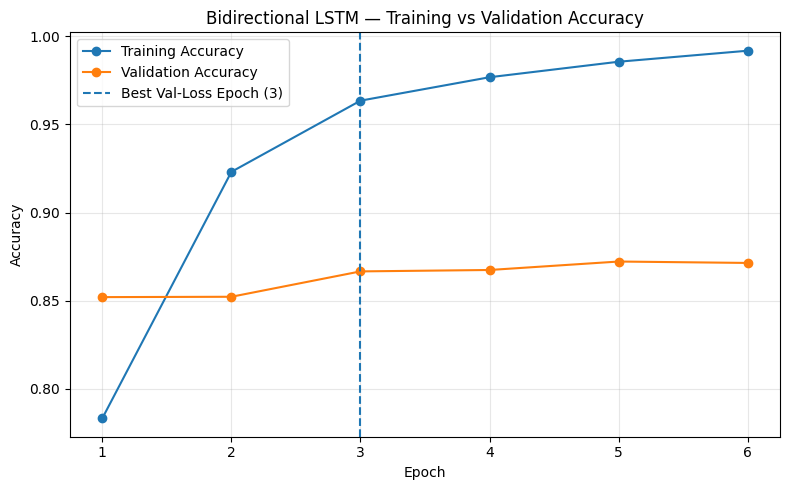

In [114]:
# ============================================================
# 15.1.5 BIDIRECTIONAL LSTM — ACCURACY CURVE
# ============================================================

bilstm_epochs = range(
    1,
    len(bilstm_history.history["accuracy"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    bilstm_epochs,
    bilstm_history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    bilstm_epochs,
    bilstm_history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    BILSTM_BEST_EPOCH,
    linestyle="--",
    label=f"Best Val-Loss Epoch ({BILSTM_BEST_EPOCH})"
)

plt.title(
    "Bidirectional LSTM — Training vs Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

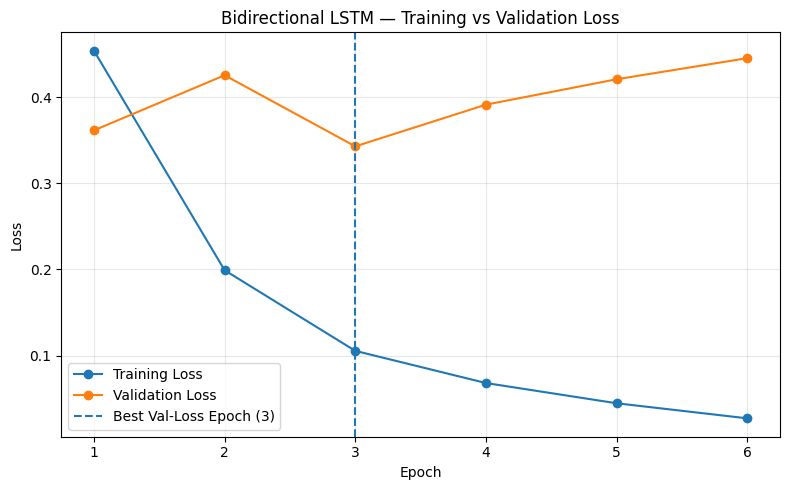

In [115]:
# ============================================================
# 15.1.5 BIDIRECTIONAL LSTM — LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    bilstm_epochs,
    bilstm_history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    bilstm_epochs,
    bilstm_history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    BILSTM_BEST_EPOCH,
    linestyle="--",
    label=f"Best Val-Loss Epoch ({BILSTM_BEST_EPOCH})"
)

plt.title(
    "Bidirectional LSTM — Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation — Bidirectional LSTM Learning Curves

The learning curves show strong learning during the early epochs followed by a clear divergence between training and validation performance.

Training accuracy increased from **78.32%** in epoch 1 to **99.19%** by epoch 6, while validation accuracy improved much more gradually and remained within approximately **85.20%–87.22%**.

The loss curves provide stronger evidence of overfitting. Training loss decreased continuously from **0.4539** to **0.0272**, whereas validation loss reached its minimum value of **0.3429 at epoch 3** and subsequently increased to **0.3913**, **0.4208**, and **0.4453**.

Therefore, the Bidirectional LSTM begins to **overfit after epoch 3**. The model continues fitting the training data increasingly well without a corresponding improvement in validation generalization.

The validation-based early-stopping strategy appropriately restores epoch 3, preventing the later overfitted epochs from determining the final model used for test evaluation.

### 15.1.6 Final Bidirectional LSTM Test Evaluation

After model selection is completed exclusively through validation performance, the restored Bidirectional LSTM checkpoint is evaluated once on the untouched official IMDb test set.

The same evaluation metrics used for the normal LSTM are calculated:

**Accuracy, Precision, Recall, and F1-score.**

This allows the Bidirectional LSTM to be compared directly with the normal LSTM under the same test conditions.

In [116]:
# ============================================================
# 15.1.6 FINAL BIDIRECTIONAL LSTM — TEST EVALUATION
# ============================================================

# Generate test probabilities
bilstm_test_probabilities = bilstm_model.predict(
    X_bilstm_test,
    batch_size=BILSTM_BATCH_SIZE,
    verbose=1
).ravel()


# Convert probabilities to binary predictions
bilstm_test_predictions = (
    bilstm_test_probabilities >= 0.5
).astype(int)


# ============================================================
# CALCULATE TEST METRICS
# ============================================================

bilstm_accuracy = accuracy_score(
    y_bilstm_test,
    bilstm_test_predictions
)

bilstm_precision = precision_score(
    y_bilstm_test,
    bilstm_test_predictions,
    zero_division=0
)

bilstm_recall = recall_score(
    y_bilstm_test,
    bilstm_test_predictions,
    zero_division=0
)

bilstm_f1 = f1_score(
    y_bilstm_test,
    bilstm_test_predictions,
    zero_division=0
)


# ============================================================
# DISPLAY TEST PERFORMANCE
# ============================================================

print("=" * 78)
print("FINAL BIDIRECTIONAL LSTM — TEST PERFORMANCE")
print("=" * 78)

print(f"Best Val Epoch : {BILSTM_BEST_EPOCH}")
print(f"Accuracy       : {bilstm_accuracy:.4f}")
print(f"Precision      : {bilstm_precision:.4f}")
print(f"Recall         : {bilstm_recall:.4f}")
print(f"F1-score       : {bilstm_f1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_bilstm_test,
        bilstm_test_predictions,
        target_names=[
            "Negative",
            "Positive"
        ],
        digits=4,
        zero_division=0
    )
)

print("=" * 78)

196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step
FINAL BIDIRECTIONAL LSTM — TEST PERFORMANCE
Best Val Epoch : 3
Accuracy       : 0.8555
Precision      : 0.8259
Recall         : 0.9010
F1-score       : 0.8618

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8911    0.8101    0.8486     12500
    Positive     0.8259    0.9010    0.8618     12500

    accuracy                         0.8555     25000
   macro avg     0.8585    0.8555    0.8552     25000
weighted avg     0.8585    0.8555    0.8552     25000



### Observation — Final Bidirectional LSTM Test Performance

The final Bidirectional LSTM achieved an **accuracy of 85.55%**, **precision of 82.59%**, **recall of 90.10%**, and an **F1-score of 86.18%** on the complete untouched 25,000-review IMDb test set.

The selected validation checkpoint achieved **86.66% validation accuracy**, compared with **85.55% test accuracy**, producing a relatively small difference of approximately **1.11 percentage points**. This indicates reasonable generalization from the validation set to unseen test data.

For the Positive class, recall was particularly strong at **90.10%**, meaning that the model successfully identified a large proportion of genuinely positive reviews. However, Positive precision was lower at **82.59%**, indicating that this higher sensitivity was accompanied by more false-positive predictions.

For the Negative class, the model achieved **89.11% precision**, **81.01% recall**, and an **F1-score of 84.86%**.

Overall, the Bidirectional LSTM demonstrates strong test performance with a noticeable tendency toward higher Positive-class recall.

### 15.1.7 Normal LSTM vs Bidirectional LSTM

The final Bidirectional LSTM is compared directly with the previously evaluated normal LSTM.

Both models use the same official test set and the same evaluation metrics. Therefore, their test results are directly comparable.

The comparison determines whether processing each review in both forward and backward directions improved sentiment-classification performance in this experiment.

In [117]:
# ============================================================
# 15.1.7 NORMAL LSTM VS BIDIRECTIONAL LSTM
# ============================================================

lstm_bilstm_comparison = pd.DataFrame({

    "Model": [
        "Normal LSTM",
        "Bidirectional LSTM"
    ],

    "Accuracy": [
        lstm_accuracy,
        bilstm_accuracy
    ],

    "Precision": [
        lstm_precision,
        bilstm_precision
    ],

    "Recall": [
        lstm_recall,
        bilstm_recall
    ],

    "F1": [
        lstm_f1,
        bilstm_f1
    ]
})


print("=" * 85)
print("NORMAL LSTM VS BIDIRECTIONAL LSTM")
print("=" * 85)

display(
    lstm_bilstm_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)


print("\nBidirectional LSTM minus Normal LSTM:")

print(
    f"Accuracy  : "
    f"{bilstm_accuracy - lstm_accuracy:+.4f}"
)

print(
    f"Precision : "
    f"{bilstm_precision - lstm_precision:+.4f}"
)

print(
    f"Recall    : "
    f"{bilstm_recall - lstm_recall:+.4f}"
)

print(
    f"F1-score  : "
    f"{bilstm_f1 - lstm_f1:+.4f}"
)

print("=" * 85)

NORMAL LSTM VS BIDIRECTIONAL LSTM


,Model,Accuracy,Precision,Recall,F1
0,Normal LSTM,0.8536,0.8872,0.8103,0.8470
1,Bidirectional LSTM,0.8555,0.8259,0.9010,0.8618



Bidirectional LSTM minus Normal LSTM:
Accuracy  : +0.0019
Precision : -0.0613
Recall    : +0.0906
F1-score  : +0.0148


### Observation — Normal LSTM vs Bidirectional LSTM

The Bidirectional LSTM produced a modest improvement in overall performance compared with the normal LSTM.

The normal LSTM achieved **85.36% accuracy**, **88.72% precision**, **81.03% recall**, and an **F1-score of 84.70%**.

The Bidirectional LSTM achieved **85.55% accuracy**, **82.59% precision**, **90.10% recall**, and an **F1-score of 86.18%**.

Relative to the normal LSTM, the Bidirectional LSTM changed performance by:

- **Accuracy:** +0.19 percentage points
- **Precision:** −6.13 percentage points
- **Recall:** +9.06 percentage points
- **F1-score:** +1.48 percentage points

The largest improvement occurred in **recall**, showing that bidirectional processing enabled the model to identify substantially more Positive reviews. This improvement was accompanied by lower precision, indicating a trade-off in which the Bidirectional LSTM predicted the Positive class more aggressively.

Despite the very small improvement in overall accuracy, the higher F1-score indicates a better balance between precision and recall for the Positive class.

Therefore, the Bidirectional LSTM performed **slightly better overall than the normal LSTM in this experiment**, particularly when F1-score and Positive-class recall are important. However, the improvement should not be interpreted as a universal advantage because the Bidirectional architecture also contains more trainable parameters and requires additional computation.

### 15.1.8 Bidirectional LSTM — Conclusion

The Bidirectional LSTM bonus experiment was successfully completed using the same data partitions and main training configuration as the normal LSTM.

The experiment showed that bidirectional sequence processing produced a small improvement in test accuracy from **85.36% to 85.55%** and increased the F1-score from **84.70% to 86.18%**.

The most substantial difference was observed in recall, which increased from **81.03% to 90.10%**, while precision decreased from **88.72% to 82.59%**. Therefore, the Bidirectional LSTM achieved greater sensitivity to Positive reviews at the cost of additional false-positive predictions.

The training curves also revealed overfitting after epoch 3. Early stopping successfully controlled this behavior by restoring the minimum-validation-loss checkpoint before final test evaluation.

Overall, the Bidirectional LSTM provided a modest improvement over the normal LSTM, especially in F1-score and recall, but this improvement comes with greater architectural complexity and a larger number of trainable parameters.

## 15.2 Dropout Regularization — Overfitting Before vs After

Dropout regularization was already investigated during the Simple RNN experiments, so the model does not need to be retrained for this bonus challenge.

The purpose of this experiment was to determine whether adding dropout could reduce overfitting and improve validation generalization.

Four dropout configurations were evaluated using the same RNN development data:

| Dropout | Epochs Trained | Best Epoch | Best Validation Loss | Validation Accuracy at Best-Loss Checkpoint | Maximum Validation Accuracy |
|---:|---:|---:|---:|---:|---:|
| 0.0 | 5 | 2 | 0.4837 | 78.40% | 78.40% |
| 0.2 | 4 | 1 | 0.3868 | 83.90% | 85.28% |
| 0.4 | 7 | 4 | 0.5040 | 76.90% | 76.90% |
| 0.5 | 7 | 4 | 0.4610 | 82.90% | 83.22% |

The **0.0 dropout** configuration represents the model **before dropout regularization**, while **0.2 dropout** represents the selected model **after adding dropout**.

### Before Dropout — Dropout = 0.0

Without dropout, the RNN achieved a best validation loss of **0.4837** and validation accuracy of **78.40%** at its best-loss checkpoint.

Training performance continued to improve strongly after the optimal validation checkpoint while validation performance deteriorated, providing clear evidence of overfitting.

### After Dropout — Dropout = 0.2

Adding **20% dropout** substantially improved validation behavior.

The best validation loss decreased from **0.4837 to 0.3868**, while validation accuracy at the best-loss checkpoint increased from **78.40% to 83.90%**.

The maximum validation accuracy also increased from **78.40% to 85.28%**.

Therefore, moderate dropout improved the RNN's ability to generalize to unseen validation data.

### Direct Before-vs-After Comparison

Comparing the no-dropout model with the selected 0.2-dropout model:

- **Best validation loss:** 0.4837 → 0.3868
- **Validation accuracy at best-loss checkpoint:** 78.40% → 83.90%
- **Maximum validation accuracy:** 78.40% → 85.28%
- **Improvement in validation accuracy at the selected checkpoint:** +5.50 percentage points
- **Improvement in maximum validation accuracy:** +6.88 percentage points

These results demonstrate that dropout reduced the severity of overfitting and produced substantially stronger validation performance.

However, increasing dropout beyond the selected level did not continue improving performance. Dropout values of **0.4** and **0.5** produced weaker validation results than **0.2**, demonstrating that excessive regularization can also reduce model performance.

### Conclusion

The dropout experiment demonstrates that **moderate regularization was beneficial, but stronger dropout was not automatically better**.

The RNN without dropout showed stronger overfitting and weaker validation generalization. Introducing **0.2 dropout** produced the best regularized configuration, substantially improving validation loss and validation accuracy.

Therefore, **0.2 dropout was selected for the final RNN**, successfully satisfying the bonus requirement to add dropout and compare overfitting before and after regularization.

## 15.3 GRU — RNN vs GRU vs LSTM

A **Gated Recurrent Unit (GRU)** model is implemented as an additional recurrent architecture and compared with the previously trained **Simple RNN** and **LSTM** models.

The GRU uses gating mechanisms to control the flow of information through a sequence, but it has a simpler internal structure than an LSTM. A GRU mainly uses **update** and **reset** gates, whereas an LSTM uses separate input, forget, and output gates together with a cell state.

To make the comparison as controlled as possible, the GRU uses the same:

- training, validation, and test partitions,
- integer-sequence representation,
- vocabulary,
- sequence length,
- embedding dimensionality,
- recurrent hidden size,
- hidden Dense layer,
- dropout rate,
- optimizer and learning rate,
- batch size,
- maximum number of epochs,
- early-stopping strategy.

The principal architectural change is therefore the recurrent layer:

**SimpleRNN → GRU → LSTM**

The official test set remains untouched during GRU training and model selection.

In [118]:
# ============================================================
# 15.3.1 GRU — Fair Comparison Setup
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Reuse exactly the same data used by the RNN and LSTM
X_gru_train = X_rnn_train
X_gru_val = X_rnn_val
y_gru_train = y_rnn_train
y_gru_val = y_rnn_val

# Official untouched test set
X_gru_test = X_test_padded
y_gru_test = y_test_neural

# Same main architecture/training settings
GRU_VOCAB_SIZE = 19679
GRU_SEQUENCE_LENGTH = 500
GRU_EMBEDDING_DIM = 128
GRU_UNITS = 64
GRU_DENSE_UNITS = 32
GRU_DROPOUT = 0.2

GRU_LEARNING_RATE = 0.001
GRU_BATCH_SIZE = 128
GRU_MAX_EPOCHS = 12
GRU_PATIENCE = 3

print("=" * 78)
print("GRU — FAIR COMPARISON SETUP")
print("=" * 78)

print(f"Training input shape       : {X_gru_train.shape}")
print(f"Validation input shape     : {X_gru_val.shape}")
print(f"Test input shape           : {X_gru_test.shape}")

print(f"\nSequence length            : {GRU_SEQUENCE_LENGTH}")
print(f"Vocabulary size            : {GRU_VOCAB_SIZE}")
print(f"Embedding dimension        : {GRU_EMBEDDING_DIM}")
print(f"GRU units                  : {GRU_UNITS}")
print(f"Hidden Dense units         : {GRU_DENSE_UNITS}")
print(f"Dropout rate               : {GRU_DROPOUT}")
print(f"Initial learning rate      : {GRU_LEARNING_RATE}")
print(f"Batch size                 : {GRU_BATCH_SIZE}")
print(f"Maximum epochs             : {GRU_MAX_EPOCHS}")
print(f"Early-stopping patience    : {GRU_PATIENCE}")

print("\nPrimary architecture change : Recurrent layer → GRU")
print("New data split created      : No")
print("Test set used for training  : No")
print("=" * 78)

GRU — FAIR COMPARISON SETUP
Training input shape       : (20000, 500)
Validation input shape     : (5000, 500)
Test input shape           : (25000, 500)

Sequence length            : 500
Vocabulary size            : 19679
Embedding dimension        : 128
GRU units                  : 64
Hidden Dense units         : 32
Dropout rate               : 0.2
Initial learning rate      : 0.001
Batch size                 : 128
Maximum epochs             : 12
Early-stopping patience    : 3

Primary architecture change : Recurrent layer → GRU
New data split created      : No
Test set used for training  : No


### 15.3.2 GRU Architecture

The GRU classifier follows the same many-to-one sentiment-classification structure used for the previous recurrent models:

**Integer Sequence Input → Embedding (128) → GRU (64) → Dense (32, ReLU) → Dense (1, Sigmoid)**

The GRU produces one final sequence representation, which is passed through the hidden Dense layer and then to the sigmoid output neuron for binary sentiment classification.

Using the same dimensional configuration as the previous recurrent models makes the experimental comparison more controlled while allowing the recurrent mechanism itself to be evaluated.

In [119]:
# ============================================================
# Build GRU Model
# ============================================================

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

gru_model = Sequential([
    Embedding(
        input_dim=GRU_VOCAB_SIZE,
        output_dim=GRU_EMBEDDING_DIM,
        mask_zero=True,
        name="embedding"
    ),

    GRU(
        GRU_UNITS,
        dropout=GRU_DROPOUT,
        return_sequences=False,
        name="gru"
    ),

    Dense(
        GRU_DENSE_UNITS,
        activation="relu",
        name="hidden_dense_relu"
    ),

    Dense(
        1,
        activation="sigmoid",
        name="sentiment_output"
    )
])

# Explicitly build the model before displaying its summary
gru_model.build(input_shape=(None, GRU_SEQUENCE_LENGTH))

print("=" * 78)
print("GRU ARCHITECTURE")
print("=" * 78)

gru_model.summary()

print("\nArchitecture configuration:")
print(f"Vocabulary size       : {GRU_VOCAB_SIZE}")
print(f"Sequence length       : {GRU_SEQUENCE_LENGTH}")
print(f"Embedding dimension   : {GRU_EMBEDDING_DIM}")
print(f"GRU units             : {GRU_UNITS}")
print(f"Hidden Dense units    : {GRU_DENSE_UNITS}")
print(f"Dropout rate          : {GRU_DROPOUT}")
print("Hidden activation     : ReLU")
print("Output activation     : Sigmoid")
print("Padding masking       : Enabled")
print("Sequence architecture : Many-to-one")
print("=" * 78)

GRU ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     2,518,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_relu (Dense)       │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment_output (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,558,273 (9.76 MB)

 Trainable params: 2,558,273 (9.76 MB)

 Non-trainable params: 0 (0.00 B)


Architecture configuration:
Vocabulary size       : 19679
Sequence length       : 500
Embedding dimension   : 128
GRU units             : 64
Hidden Dense units    : 32
Dropout rate          : 0.2
Hidden activation     : ReLU
Output activation     : Sigmoid
Padding masking       : Enabled
Sequence architecture : Many-to-one


In [120]:
# ============================================================
# 15.3.3 GRU Training Configuration
# ============================================================

gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=GRU_LEARNING_RATE
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

gru_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=GRU_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

gru_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

print("=" * 75)
print("GRU TRAINING CONFIGURATION")
print("=" * 75)
print(f"Maximum epochs          : {GRU_MAX_EPOCHS}")
print(f"Batch size              : {GRU_BATCH_SIZE}")
print(f"Initial learning rate   : {GRU_LEARNING_RATE}")
print(f"Dropout                 : {GRU_DROPOUT}")
print("Optimizer               : Adam")
print("Loss function           : Binary Crossentropy")
print("Training metric         : Accuracy")
print("Validation monitor      : Validation Loss")
print("Early stopping          : Enabled")
print(f"Early stopping patience : {GRU_PATIENCE}")
print("Restore best weights    : Enabled")
print("Learning-rate reduction : Enabled")
print("Test set used           : No")
print("=" * 75)

GRU TRAINING CONFIGURATION
Maximum epochs          : 12
Batch size              : 128
Initial learning rate   : 0.001
Dropout                 : 0.2
Optimizer               : Adam
Loss function           : Binary Crossentropy
Training metric         : Accuracy
Validation monitor      : Validation Loss
Early stopping          : Enabled
Early stopping patience : 3
Restore best weights    : Enabled
Learning-rate reduction : Enabled
Test set used           : No


In [121]:
# ============================================================
# 15.3.4 Train GRU
# ============================================================

gru_history = gru_model.fit(
    X_gru_train,
    y_gru_train,
    validation_data=(X_gru_val, y_gru_val),
    epochs=GRU_MAX_EPOCHS,
    batch_size=GRU_BATCH_SIZE,
    callbacks=[
        gru_early_stopping,
        gru_reduce_lr
    ],
    verbose=1
)

# Extract training history
gru_train_accuracy = gru_history.history["accuracy"]
gru_val_accuracy = gru_history.history["val_accuracy"]

gru_train_loss = gru_history.history["loss"]
gru_val_loss = gru_history.history["val_loss"]

# Best checkpoint according to validation loss
gru_best_epoch = int(np.argmin(gru_val_loss) + 1)
gru_best_val_loss = float(np.min(gru_val_loss))
gru_val_acc_at_best_loss = float(
    gru_val_accuracy[gru_best_epoch - 1]
)
gru_max_val_accuracy = float(np.max(gru_val_accuracy))

# Verify the restored checkpoint
gru_restored_val_loss, gru_restored_val_accuracy = (
    gru_model.evaluate(
        X_gru_val,
        y_gru_val,
        verbose=0
    )
)

print("\n" + "=" * 78)
print("GRU TRAINING SUMMARY")
print("=" * 78)

print(
    f"Epochs completed                  : "
    f"{len(gru_train_loss)}"
)

print(
    f"Best epoch by validation loss     : "
    f"{gru_best_epoch}"
)

print(
    f"Lowest validation loss            : "
    f"{gru_best_val_loss:.4f}"
)

print(
    f"Validation accuracy at best loss  : "
    f"{gru_val_acc_at_best_loss:.4f}"
)

print(
    f"Maximum validation accuracy       : "
    f"{gru_max_val_accuracy:.4f}"
)

print(
    f"Verified restored val accuracy    : "
    f"{gru_restored_val_accuracy:.4f}"
)

print(
    f"Verified restored val loss        : "
    f"{gru_restored_val_loss:.4f}"
)

print("=" * 78)

Epoch 1/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 68ms/step - accuracy: 0.7322 - loss: 0.5059 - val_accuracy: 0.8304 - val_loss: 0.3800 - learning_rate: 0.0010
Epoch 2/12
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8778 - loss: 0.2998
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8921 - loss: 0.2731 - val_accuracy: 0.8248 - val_loss: 0.4451 - learning_rate: 0.0010
Epoch 3/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9401 - loss: 0.1607 - val_accuracy: 0.8708 - val_loss: 0.3558 - learning_rate: 5.0000e-04
Epoch 4/12
155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9565 - loss: 0.1266
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9660 - loss: 0.1037 - val_accuracy: 0.8730 - val_loss: 0.3691 - learning_rate: 5.0000e-04
Epoch 5/12
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9654 - l

### Observation — GRU Training Behavior

The GRU completed training after **6 epochs**, with `EarlyStopping` restoring the model weights from **epoch 3**, which achieved the minimum validation loss.

At the selected checkpoint, the GRU achieved a validation accuracy of **87.08%** with a validation loss of **0.3558**.

Training performance continued to improve substantially after epoch 3. Training accuracy increased to **98.51%** by epoch 6, while training loss decreased to **0.0489**.

In contrast, validation loss increased after the optimal checkpoint, rising from **0.3558** at epoch 3 to **0.3691**, **0.3830**, and finally **0.4368**. Validation accuracy remained relatively stable and reached a maximum of **87.50%**.

This divergence between continuously improving training performance and deteriorating validation loss indicates **overfitting after epoch 3**.

The validation-based early-stopping strategy successfully controlled this behavior by restoring the epoch-3 checkpoint. The restored model was independently verified and reproduced exactly **87.08% validation accuracy** and **0.3558 validation loss**.

### 15.3.5 GRU Learning Curves

Training and validation accuracy and loss are visualized to examine the GRU's learning behavior and identify the point at which generalization begins to deteriorate.

The validation-loss minimum is also marked to show the checkpoint selected by early stopping.

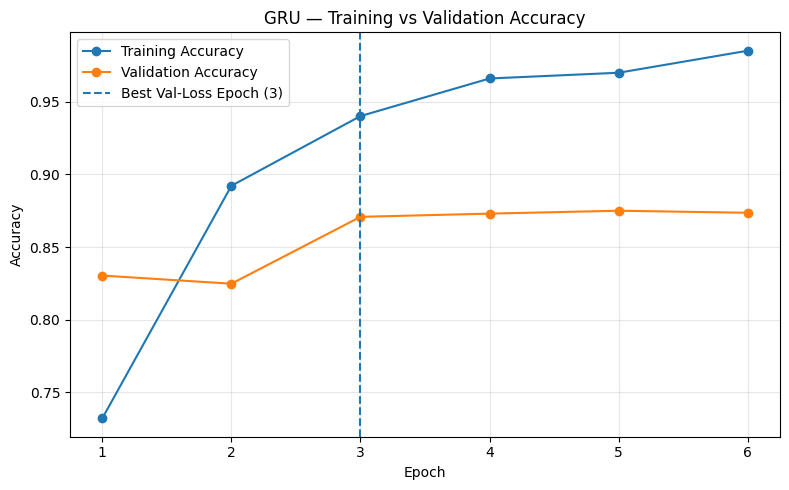

In [122]:
# ============================================================
# 15.3.5 GRU — ACCURACY CURVE
# ============================================================

gru_epochs = range(
    1,
    len(gru_history.history["accuracy"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    gru_epochs,
    gru_history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    gru_epochs,
    gru_history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    gru_best_epoch,
    linestyle="--",
    label=f"Best Val-Loss Epoch ({gru_best_epoch})"
)

plt.title("GRU — Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

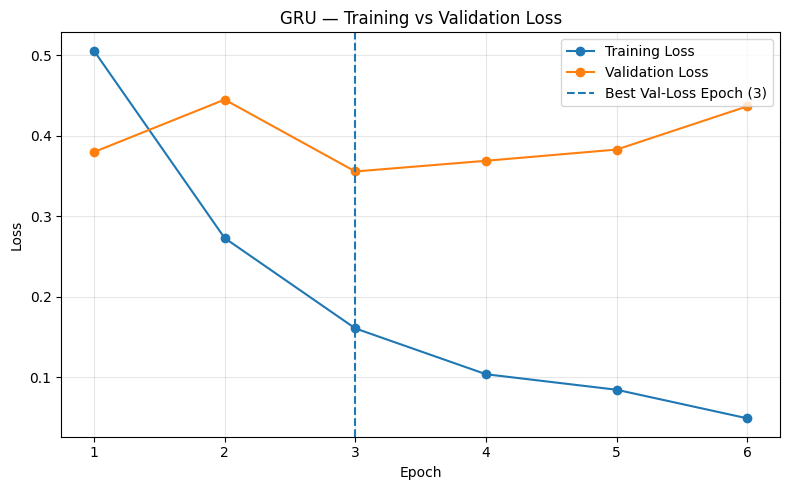

In [123]:
# ============================================================
# 15.3.5 GRU — LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    gru_epochs,
    gru_history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    gru_epochs,
    gru_history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    gru_best_epoch,
    linestyle="--",
    label=f"Best Val-Loss Epoch ({gru_best_epoch})"
)

plt.title("GRU — Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation — GRU Learning Curves and Overfitting Behavior

The training and validation curves show that the GRU learns the training data very effectively during the first few epochs, but a growing generalization gap appears as training continues.

Training accuracy increased from **73.22% in epoch 1** to **98.51% by epoch 6**, while validation accuracy remained much more stable, ranging around the mid-to-high 80% range and reaching a maximum of **87.50%**.

The loss curves provide the clearest evidence of overfitting. Training loss decreased continuously from **0.5059** to **0.0489**, whereas validation loss reached its minimum value of **0.3558 at epoch 3**. After this point, validation loss increased to **0.3691**, **0.3830**, and finally **0.4368**, even though training performance continued to improve.

The dashed vertical line marks **epoch 3**, which was selected as the best checkpoint according to validation loss. Therefore, the curves indicate that the GRU begins to **overfit after epoch 3**.

Early stopping handled this behavior appropriately by restoring the epoch-3 model weights. The restored checkpoint achieved **87.08% validation accuracy** with a validation loss of **0.3558**, ensuring that the final test evaluation uses the best validation-selected GRU rather than a later overfitted state.

### 15.3.6 Final GRU Test Evaluation

After model selection has been completed exclusively using the validation set, the restored GRU checkpoint is evaluated on the untouched official IMDb test set.

The same metrics used for the Simple RNN and LSTM are calculated:

**Accuracy, Precision, Recall, and F1-score.**

In [124]:
# ============================================================
# 15.3.6 FINAL GRU — TEST EVALUATION
# ============================================================

# Generate test probabilities
gru_test_probabilities = gru_model.predict(
    X_gru_test,
    batch_size=GRU_BATCH_SIZE,
    verbose=1
).ravel()

# Convert probabilities to binary predictions
gru_test_predictions = (
    gru_test_probabilities >= 0.5
).astype(int)


# ============================================================
# CALCULATE TEST METRICS
# ============================================================

gru_accuracy = accuracy_score(
    y_gru_test,
    gru_test_predictions
)

gru_precision = precision_score(
    y_gru_test,
    gru_test_predictions,
    zero_division=0
)

gru_recall = recall_score(
    y_gru_test,
    gru_test_predictions,
    zero_division=0
)

gru_f1 = f1_score(
    y_gru_test,
    gru_test_predictions,
    zero_division=0
)


# ============================================================
# DISPLAY TEST RESULTS
# ============================================================

print("=" * 78)
print("FINAL GRU — TEST PERFORMANCE")
print("=" * 78)

print(f"Best Val Epoch : {gru_best_epoch}")
print(f"Accuracy       : {gru_accuracy:.4f}")
print(f"Precision      : {gru_precision:.4f}")
print(f"Recall         : {gru_recall:.4f}")
print(f"F1-score       : {gru_f1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_gru_test,
        gru_test_predictions,
        target_names=[
            "Negative",
            "Positive"
        ],
        digits=4,
        zero_division=0
    )
)

print("=" * 78)

196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
FINAL GRU — TEST PERFORMANCE
Best Val Epoch : 3
Accuracy       : 0.8692
Precision      : 0.8538
Recall         : 0.8910
F1-score       : 0.8720

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8860    0.8474    0.8663     12500
    Positive     0.8538    0.8910    0.8720     12500

    accuracy                         0.8692     25000
   macro avg     0.8699    0.8692    0.8691     25000
weighted avg     0.8699    0.8692    0.8691     25000



### Observation — Final GRU Test Performance

The validation-selected GRU achieved strong performance on the untouched **25,000-review IMDb test set**, obtaining an **accuracy of 86.92%**, **precision of 85.38%**, **recall of 89.10%**, and **F1-score of 87.20%**.

The class-level results show relatively balanced performance. For the **Negative** class, the model achieved **88.60% precision**, **84.74% recall**, and **86.63% F1-score**. For the **Positive** class, it achieved **85.38% precision**, **89.10% recall**, and **87.20% F1-score**.

The relatively high positive-class recall indicates that the GRU successfully identifies a large proportion of positive reviews, although this is accompanied by slightly lower positive-class precision.

Overall, the GRU generalizes well to the unseen test data. Its **86.92% test accuracy** is also reasonably close to the **87.08% validation accuracy** of the restored epoch-3 checkpoint, producing a difference of only **0.16 percentage points**. This supports the effectiveness of validation-based model selection and early stopping.

### 15.3.7 Simple RNN vs GRU vs LSTM

The GRU is now compared directly with the previously evaluated Simple RNN and LSTM.

All three recurrent models are evaluated on the same official 25,000-review IMDb test set using the same metrics, allowing a direct recurrent-model comparison.

In [125]:
# ============================================================
# 15.3.7 SIMPLE RNN VS GRU VS LSTM
# ============================================================

rnn_gru_lstm_comparison = pd.DataFrame({

    "Model": [
        "Simple RNN",
        "GRU",
        "LSTM"
    ],

    "Accuracy": [
        rnn_accuracy,
        gru_accuracy,
        lstm_accuracy
    ],

    "Precision": [
        rnn_precision,
        gru_precision,
        lstm_precision
    ],

    "Recall": [
        rnn_recall,
        gru_recall,
        lstm_recall
    ],

    "F1": [
        rnn_f1,
        gru_f1,
        lstm_f1
    ]
})


print("=" * 85)
print("SIMPLE RNN VS GRU VS LSTM")
print("=" * 85)

display(
    rnn_gru_lstm_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

print("=" * 85)

SIMPLE RNN VS GRU VS LSTM


,Model,Accuracy,Precision,Recall,F1
0,Simple RNN,0.8388,0.8575,0.8127,0.8345
1,GRU,0.8692,0.8538,0.8910,0.8720
2,LSTM,0.8536,0.8872,0.8103,0.8470


### Observation — Simple RNN vs GRU vs LSTM

The three recurrent architectures show clear differences in their ability to model sequential sentiment information.

The **Simple RNN** achieved **83.88% accuracy** and **83.45% F1-score**, making it the weakest of the three recurrent architectures on the test set. This is consistent with the limitations of a basic recurrent state when learning more complex or longer-range dependencies.

The **LSTM** improved test accuracy to **85.36%** and F1-score to **84.70%**. It also achieved the highest precision of the three models at **88.72%**, although its recall remained comparatively lower at **81.03%**.

The **GRU produced the strongest overall recurrent-model performance**, achieving **86.92% accuracy** and **87.20% F1-score**. It also obtained the highest recall at **89.10%**, substantially exceeding both the Simple RNN and LSTM.

Compared with the Simple RNN, the GRU improved accuracy by **3.04 percentage points** and F1-score by **3.75 percentage points**. Compared with the LSTM, the GRU improved accuracy by **1.56 percentage points** and F1-score by **2.50 percentage points**.

However, the LSTM retained the highest precision. Therefore, the GRU did not dominate every individual metric, but it provided the strongest overall balance of accuracy, recall, and F1-score in this experiment.

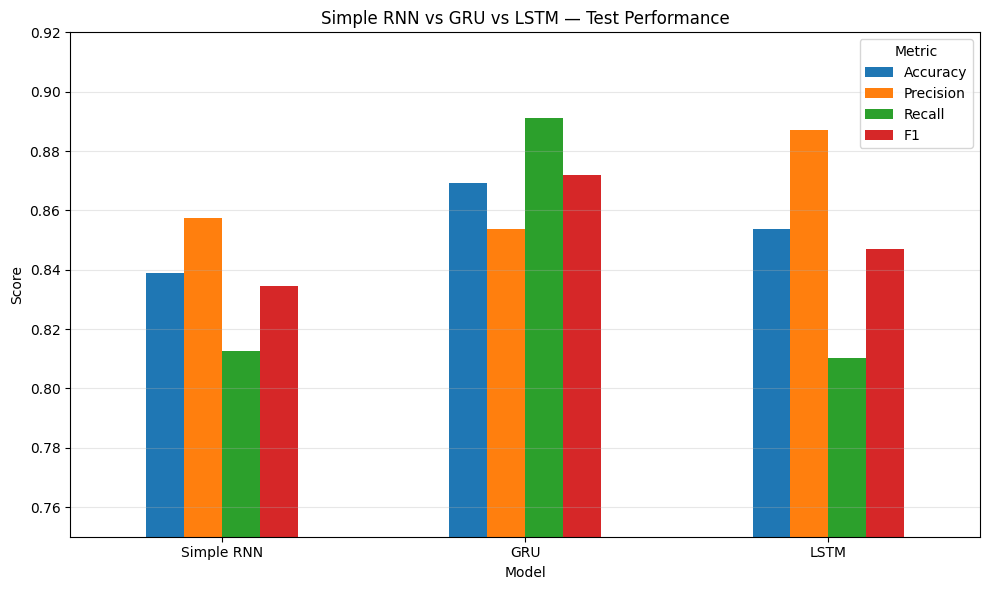

In [126]:
# ============================================================
# 15.3.8 RNN vs GRU vs LSTM — Performance Visualization
# ============================================================

comparison_plot = rnn_gru_lstm_comparison.set_index("Model")

ax = comparison_plot[
    ["Accuracy", "Precision", "Recall", "F1"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Simple RNN vs GRU vs LSTM — Test Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.75, 0.92)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 15.3.8 GRU — Conclusion

The GRU experiment demonstrates that gated recurrent architectures can provide a meaningful improvement over a basic Simple RNN for IMDb sentiment classification.

Using the same dataset partitions and a comparable training configuration, the GRU achieved:

- **Accuracy:** 86.92%
- **Precision:** 85.38%
- **Recall:** 89.10%
- **F1-score:** 87.20%

Among the three recurrent architectures, the GRU achieved the **highest accuracy, recall, and F1-score**, while the LSTM achieved the highest precision.

The GRU also showed signs of overfitting after epoch 3, as training performance continued to improve while validation loss increased. Early stopping successfully controlled this behavior by restoring the best validation-loss checkpoint.

Overall, the experimental ranking based on test accuracy and F1-score is:

**GRU > LSTM > Simple RNN**

Therefore, the GRU provided the strongest overall recurrent-model performance in this experiment while retaining a simpler gated structure than the LSTM.

## 15.4 Vocabulary Size and Sequence Length Tuning

The vocabulary size and maximum sequence length are two important hyperparameters in neural NLP models.

A larger vocabulary can preserve more distinct words and reduce the number of out-of-vocabulary tokens, but it also increases the size of the embedding matrix and therefore increases memory usage and computational cost.

Similarly, a longer sequence length preserves more information from long reviews, but increases padding, recurrent computation, memory requirements, and training time.

Therefore, this bonus experiment evaluates multiple combinations of vocabulary size and sequence length to identify a configuration that provides a strong balance between predictive performance and computational efficiency.

The **GRU architecture** is used as the controlled model for this tuning experiment because it produced the strongest overall performance among the recurrent models in the preceding comparison.

Importantly, hyperparameter selection is performed using the **development training and validation sets only**. The official test set is not used to select the vocabulary size or sequence length.

### 15.4.1 Tuning Search Space

A controlled grid of candidate configurations is evaluated:

| Hyperparameter | Candidate Values |
|---|---|
| Vocabulary Size | 10,000, 15,000, 20,000 |
| Sequence Length | 300, 500, 700 |

This produces **9 vocabulary–sequence combinations**.

The configuration originally used by the recurrent models, approximately **20,000 vocabulary terms and 500 sequence tokens**, is included in the search space so that the tuned alternatives can be compared against the existing configuration.

Each candidate uses the same GRU architecture and training settings. Only the vocabulary size and sequence length are changed.

In [127]:
# ============================================================
# 15.4.2 VOCABULARY SIZE & SEQUENCE LENGTH — TUNING SETUP
# ============================================================

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Candidate hyperparameter values
VOCABULARY_CANDIDATES = [
    10000,
    15000,
    20000
]

SEQUENCE_LENGTH_CANDIDATES = [
    300,
    500,
    700
]

# Reuse the existing development text split
X_tuning_train_text = X_dev_train
X_tuning_val_text = X_validation

y_tuning_train = y_dev_train.to_numpy()
y_tuning_val = y_validation.to_numpy()

print("=" * 78)
print("VOCABULARY & SEQUENCE-LENGTH TUNING SETUP")
print("=" * 78)

print(f"Development training samples : {len(X_tuning_train_text):,}")
print(f"Validation samples           : {len(X_tuning_val_text):,}")

print(
    f"\nVocabulary candidates        : "
    f"{VOCABULARY_CANDIDATES}"
)

print(
    f"Sequence-length candidates   : "
    f"{SEQUENCE_LENGTH_CANDIDATES}"
)

print(
    f"Total configurations         : "
    f"{len(VOCABULARY_CANDIDATES) * len(SEQUENCE_LENGTH_CANDIDATES)}"
)

print("\nControlled model             : GRU")
print("Test set used for tuning     : No")
print("=" * 78)

VOCABULARY & SEQUENCE-LENGTH TUNING SETUP
Development training samples : 20,000
Validation samples           : 5,000

Vocabulary candidates        : [10000, 15000, 20000]
Sequence-length candidates   : [300, 500, 700]
Total configurations         : 9

Controlled model             : GRU
Test set used for tuning     : No


In [128]:
# ============================================================
# 15.4.3 VOCABULARY & SEQUENCE-LENGTH GRID SEARCH
# ============================================================

tuning_results = []

total_experiments = (
    len(VOCABULARY_CANDIDATES)
    * len(SEQUENCE_LENGTH_CANDIDATES)
)

experiment_number = 0


for vocab_size in VOCABULARY_CANDIDATES:

    # --------------------------------------------------------
    # Create a fresh tokenizer for this vocabulary size
    # --------------------------------------------------------

    tuning_tokenizer = Tokenizer(
        num_words=vocab_size,
        oov_token="<OOV>"
    )

    # Fit ONLY on development training text
    tuning_tokenizer.fit_on_texts(
        X_tuning_train_text
    )

    # Convert train and validation text to sequences
    train_sequences = (
        tuning_tokenizer.texts_to_sequences(
            X_tuning_train_text
        )
    )

    val_sequences = (
        tuning_tokenizer.texts_to_sequences(
            X_tuning_val_text
        )
    )

    # Actual embedding vocabulary size
    actual_vocab_size = min(
        vocab_size,
        len(tuning_tokenizer.word_index) + 1
    )


    for sequence_length in SEQUENCE_LENGTH_CANDIDATES:

        experiment_number += 1

        print("\n" + "=" * 90)

        print(
            f"TUNING EXPERIMENT "
            f"{experiment_number}/{total_experiments}"
        )

        print(
            f"Vocabulary = {vocab_size:,} | "
            f"Sequence Length = {sequence_length}"
        )

        print("=" * 90)


        # ----------------------------------------------------
        # Pad/truncate sequences for this candidate length
        # ----------------------------------------------------

        X_candidate_train = pad_sequences(
            train_sequences,
            maxlen=sequence_length,
            padding="post",
            truncating="post"
        )

        X_candidate_val = pad_sequences(
            val_sequences,
            maxlen=sequence_length,
            padding="post",
            truncating="post"
        )


        # ----------------------------------------------------
        # Reset model state for a fair fresh experiment
        # ----------------------------------------------------

        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(
            RANDOM_STATE
        )


        # ----------------------------------------------------
        # Build controlled GRU model
        # ----------------------------------------------------

        candidate_model = Sequential([

            tf.keras.Input(
                shape=(sequence_length,)
            ),

            Embedding(
                input_dim=actual_vocab_size,
                output_dim=GRU_EMBEDDING_DIM,
                mask_zero=True
            ),

            GRU(
                GRU_UNITS,
                dropout=GRU_DROPOUT,
                return_sequences=False
            ),

            Dense(
                GRU_DENSE_UNITS,
                activation="relu"
            ),

            Dense(
                1,
                activation="sigmoid"
            )
        ])


        # ----------------------------------------------------
        # Compile
        # ----------------------------------------------------

        candidate_model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=GRU_LEARNING_RATE
            ),
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )


        # ----------------------------------------------------
        # Fresh callbacks for every candidate
        # ----------------------------------------------------

        candidate_early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=GRU_PATIENCE,
            restore_best_weights=True,
            verbose=0
        )

        candidate_reduce_lr = ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-6,
            verbose=0
        )


        # ----------------------------------------------------
        # Train using development train + validation ONLY
        # ----------------------------------------------------

        candidate_history = candidate_model.fit(
            X_candidate_train,
            y_tuning_train,
            validation_data=(
                X_candidate_val,
                y_tuning_val
            ),
            epochs=GRU_MAX_EPOCHS,
            batch_size=GRU_BATCH_SIZE,
            callbacks=[
                candidate_early_stopping,
                candidate_reduce_lr
            ],
            verbose=0
        )


        # ----------------------------------------------------
        # Identify best validation-loss checkpoint
        # ----------------------------------------------------

        candidate_best_index = int(
            np.argmin(
                candidate_history.history[
                    "val_loss"
                ]
            )
        )

        candidate_best_epoch = (
            candidate_best_index + 1
        )

        candidate_best_val_loss = float(
            candidate_history.history[
                "val_loss"
            ][candidate_best_index]
        )

        candidate_val_accuracy = float(
            candidate_history.history[
                "val_accuracy"
            ][candidate_best_index]
        )

        candidate_max_val_accuracy = float(
            np.max(
                candidate_history.history[
                    "val_accuracy"
                ]
            )
        )


        # ----------------------------------------------------
        # Verify restored checkpoint
        # ----------------------------------------------------

        restored_val_loss, restored_val_accuracy = (
            candidate_model.evaluate(
                X_candidate_val,
                y_tuning_val,
                batch_size=GRU_BATCH_SIZE,
                verbose=0
            )
        )


        # ----------------------------------------------------
        # Store experiment results
        # ----------------------------------------------------

        tuning_results.append({

            "Vocabulary Size":
                vocab_size,

            "Sequence Length":
                sequence_length,

            "Actual Vocabulary":
                actual_vocab_size,

            "Epochs Trained":
                len(
                    candidate_history.history[
                        "loss"
                    ]
                ),

            "Best Epoch":
                candidate_best_epoch,

            "Best Val Loss":
                candidate_best_val_loss,

            "Val Accuracy at Best Loss":
                candidate_val_accuracy,

            "Maximum Val Accuracy":
                candidate_max_val_accuracy,

            "Restored Val Accuracy":
                float(restored_val_accuracy)
        })


        print(
            f"Best Epoch              : "
            f"{candidate_best_epoch}"
        )

        print(
            f"Best Validation Loss    : "
            f"{candidate_best_val_loss:.4f}"
        )

        print(
            f"Validation Accuracy     : "
            f"{candidate_val_accuracy:.4f}"
        )

        print(
            f"Maximum Val Accuracy    : "
            f"{candidate_max_val_accuracy:.4f}"
        )


# ============================================================
# CREATE FINAL TUNING TABLE
# ============================================================

vocab_sequence_tuning_df = pd.DataFrame(
    tuning_results
)

print("\n" + "=" * 100)
print("VOCABULARY SIZE & SEQUENCE LENGTH — TUNING RESULTS")
print("=" * 100)

display(
    vocab_sequence_tuning_df.style.format({

        "Best Val Loss":
            "{:.4f}",

        "Val Accuracy at Best Loss":
            "{:.4f}",

        "Maximum Val Accuracy":
            "{:.4f}",

        "Restored Val Accuracy":
            "{:.4f}"
    })
)


TUNING EXPERIMENT 1/9
Vocabulary = 10,000 | Sequence Length = 300
Best Epoch              : 3
Best Validation Loss    : 0.3502
Validation Accuracy     : 0.8570
Maximum Val Accuracy    : 0.8710

TUNING EXPERIMENT 2/9
Vocabulary = 10,000 | Sequence Length = 500
Best Epoch              : 2
Best Validation Loss    : 0.3260
Validation Accuracy     : 0.8690
Maximum Val Accuracy    : 0.8798

TUNING EXPERIMENT 3/9
Vocabulary = 10,000 | Sequence Length = 700
Best Epoch              : 4
Best Validation Loss    : 0.3465
Validation Accuracy     : 0.8722
Maximum Val Accuracy    : 0.8728

TUNING EXPERIMENT 4/9
Vocabulary = 15,000 | Sequence Length = 300
Best Epoch              : 2
Best Validation Loss    : 0.3493
Validation Accuracy     : 0.8708
Maximum Val Accuracy    : 0.8712

TUNING EXPERIMENT 5/9
Vocabulary = 15,000 | Sequence Length = 500
Best Epoch              : 2
Best Validation Loss    : 0.3328
Validation Accuracy     : 0.8714
Maximum Val Accuracy    : 0.8804

TUNING EXPERIMENT 6/9
Vocabul

,Vocabulary Size,Sequence Length,Actual Vocabulary,Epochs Trained,Best Epoch,Best Val Loss,Val Accuracy at Best Loss,Maximum Val Accuracy,Restored Val Accuracy
0,10000,300,10000,6,3,0.3502,0.8570,0.8710,0.8570
1,10000,500,10000,5,2,0.3260,0.8690,0.8798,0.8690
2,10000,700,10000,7,4,0.3465,0.8722,0.8728,0.8722
3,15000,300,15000,5,2,0.3493,0.8708,0.8712,0.8708
4,15000,500,15000,5,2,0.3328,0.8714,0.8804,0.8714
5,15000,700,15000,6,3,0.3366,0.8698,0.8734,0.8698
6,20000,300,19678,6,3,0.3412,0.8712,0.8752,0.8712
7,20000,500,19678,6,3,0.3373,0.8716,0.8726,0.8716
8,20000,700,19678,4,1,0.3447,0.8556,0.8798,0.8556


In [129]:
# ============================================================
# 15.4.4 SELECT BEST VOCABULARY / SEQUENCE CONFIGURATION
# ============================================================

selected_tuning_row = (
    vocab_sequence_tuning_df
    .sort_values(
        by=[
            "Val Accuracy at Best Loss",
            "Best Val Loss"
        ],
        ascending=[
            False,
            True
        ]
    )
    .iloc[0]
)


BEST_TUNED_VOCAB_SIZE = int(
    selected_tuning_row[
        "Vocabulary Size"
    ]
)

BEST_TUNED_SEQUENCE_LENGTH = int(
    selected_tuning_row[
        "Sequence Length"
    ]
)

BEST_TUNED_VAL_ACCURACY = float(
    selected_tuning_row[
        "Val Accuracy at Best Loss"
    ]
)

BEST_TUNED_VAL_LOSS = float(
    selected_tuning_row[
        "Best Val Loss"
    ]
)

BEST_TUNED_EPOCH = int(
    selected_tuning_row[
        "Best Epoch"
    ]
)


print("=" * 78)
print("SELECTED VOCABULARY / SEQUENCE CONFIGURATION")
print("=" * 78)

print(
    f"Selected vocabulary size    : "
    f"{BEST_TUNED_VOCAB_SIZE:,}"
)

print(
    f"Selected sequence length    : "
    f"{BEST_TUNED_SEQUENCE_LENGTH}"
)

print(
    f"Best validation epoch       : "
    f"{BEST_TUNED_EPOCH}"
)

print(
    f"Validation accuracy         : "
    f"{BEST_TUNED_VAL_ACCURACY:.4f}"
)

print(
    f"Validation loss             : "
    f"{BEST_TUNED_VAL_LOSS:.4f}"
)

print("=" * 78)

SELECTED VOCABULARY / SEQUENCE CONFIGURATION
Selected vocabulary size    : 10,000
Selected sequence length    : 700
Best validation epoch       : 4
Validation accuracy         : 0.8722
Validation loss             : 0.3465


### 15.4.5 Vocabulary Size and Sequence Length — Tuning Analysis

The nine candidate configurations are compared using validation accuracy at the checkpoint with the lowest validation loss.

The visualization below shows how sequence length interacts with vocabulary size and makes it easier to identify whether increasing either hyperparameter consistently improves validation performance.

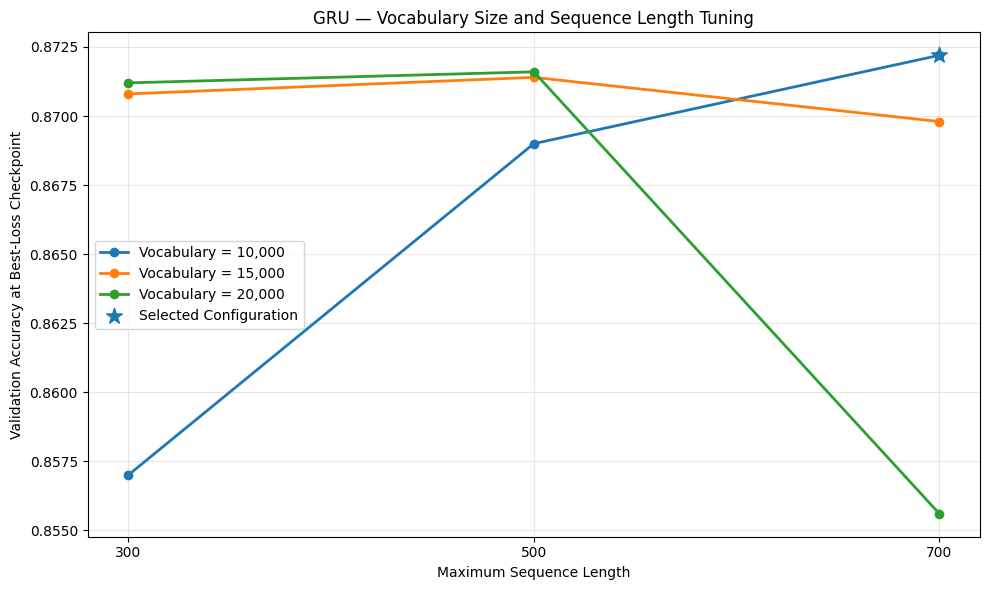

In [130]:
# ============================================================
# 15.4.5 VOCABULARY / SEQUENCE-LENGTH TUNING VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

for vocab_size in VOCABULARY_CANDIDATES:

    subset = vocab_sequence_tuning_df[
        vocab_sequence_tuning_df["Vocabulary Size"] == vocab_size
    ].sort_values("Sequence Length")

    plt.plot(
        subset["Sequence Length"],
        subset["Val Accuracy at Best Loss"],
        marker="o",
        linewidth=2,
        label=f"Vocabulary = {vocab_size:,}"
    )

plt.scatter(
    BEST_TUNED_SEQUENCE_LENGTH,
    BEST_TUNED_VAL_ACCURACY,
    s=140,
    marker="*",
    label="Selected Configuration",
    zorder=5
)

plt.title(
    "GRU — Vocabulary Size and Sequence Length Tuning"
)
plt.xlabel("Maximum Sequence Length")
plt.ylabel("Validation Accuracy at Best-Loss Checkpoint")
plt.xticks(SEQUENCE_LENGTH_CANDIDATES)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation — Vocabulary Size and Sequence Length Tuning

The tuning results show that model performance depends on the **interaction between vocabulary size and sequence length**, rather than consistently improving as either hyperparameter becomes larger.

Across the nine evaluated configurations, validation accuracy at the best-validation-loss checkpoint ranged from **85.56% to 87.22%**. The selected configuration used a vocabulary size of **10,000** and a maximum sequence length of **700**, achieving the highest selected-checkpoint validation accuracy of **87.22%**, with a validation loss of **0.3465 at epoch 4**.

For the **10,000-word vocabulary**, increasing sequence length from 300 to 500 improved validation accuracy from **85.70% to 86.90%**, and increasing it further to 700 produced the highest value of **87.22%**. However, this pattern was not consistent across larger vocabularies. With **20,000 words**, for example, increasing sequence length from 500 to 700 reduced selected-checkpoint validation accuracy from **87.16% to 85.56%**.

The experiment also shows that a larger vocabulary is not automatically beneficial. The selected **10,000-word vocabulary** outperformed the larger alternatives at sequence length 700 while requiring a smaller embedding vocabulary and therefore reducing the size of the embedding representation.

It is also important to note that the **10,000 / 500** configuration achieved the lowest validation loss of the entire grid (**0.3260**) and a maximum validation accuracy of **87.98%**. However, according to the predefined selection criterion—**validation accuracy at the minimum-validation-loss checkpoint**, with validation loss used as a tie-breaker—the 10,000 / 700 configuration was selected because it achieved the highest checkpoint accuracy of 87.22%**.

Overall, the results demonstrate that vocabulary size and sequence length should be tuned empirically rather than simply maximized. In this experiment, **10,000 vocabulary terms and a sequence length of 700 provided the strongest validation accuracy according to the predefined model-selection criterion**.

### 15.4.6 Original GRU vs Selected Tuned Configuration

The selected vocabulary and sequence-length configuration is compared with the original GRU configuration to quantify the effect of hyperparameter tuning.

Because the tuning models use newly fitted tokenizers, this comparison should be interpreted as a controlled hyperparameter experiment rather than as an identical-input rerun.

In [131]:
# ============================================================
# 15.4.6 ORIGINAL GRU VS SELECTED TUNED CONFIGURATION
# ============================================================

original_vs_tuned = pd.DataFrame({

    "Configuration": [
        "Original GRU",
        "Selected Tuned GRU"
    ],

    "Vocabulary Size": [
        19679,
        BEST_TUNED_VOCAB_SIZE
    ],

    "Sequence Length": [
        500,
        BEST_TUNED_SEQUENCE_LENGTH
    ],

    "Validation Accuracy": [
        gru_val_acc_at_best_loss,
        BEST_TUNED_VAL_ACCURACY
    ],

    "Validation Loss": [
        gru_best_val_loss,
        BEST_TUNED_VAL_LOSS
    ]
})

display(
    original_vs_tuned.style.format({
        "Validation Accuracy": "{:.4f}",
        "Validation Loss": "{:.4f}"
    })
)

accuracy_change = (
    BEST_TUNED_VAL_ACCURACY
    - gru_val_acc_at_best_loss
) * 100

loss_change = (
    BEST_TUNED_VAL_LOSS
    - gru_best_val_loss
)

print(
    f"Validation accuracy change : "
    f"{accuracy_change:+.2f} percentage points"
)

print(
    f"Validation loss change     : "
    f"{loss_change:+.4f}"
)

,Configuration,Vocabulary Size,Sequence Length,Validation Accuracy,Validation Loss
0,Original GRU,19679,500,0.8708,0.3558
1,Selected Tuned GRU,10000,700,0.8722,0.3465


Validation accuracy change : +0.14 percentage points
Validation loss change     : -0.0093


### Observation — Original GRU vs Selected Tuned GRU

Hyperparameter tuning produced a **modest but consistent improvement** over the original GRU configuration.

The original GRU used a vocabulary size of **19,679** and a maximum sequence length of **500**, achieving **87.08% validation accuracy** with a validation loss of **0.3558**.

The selected tuned configuration reduced the vocabulary size to **10,000** while increasing the maximum sequence length to **700**. It achieved **87.22% validation accuracy** with a lower validation loss of **0.3465**.

Therefore, tuning improved validation accuracy by **0.14 percentage points** and reduced validation loss by **0.0093**.

Although the accuracy improvement is relatively small, the result is meaningful because it was achieved with a vocabulary that is approximately half the size of the original vocabulary. This reduces the size of the embedding matrix while the longer sequence length allows the model to preserve more information from longer reviews.

Overall, the experiment demonstrates that simply maximizing vocabulary size is unnecessary for this task. A **smaller vocabulary combined with a longer sequence length** provided slightly better validation generalization according to the predefined model-selection criterion.

### 15.4.7 Final Tuned GRU — Rebuild and Test Evaluation

After completing hyperparameter selection using only the development training and validation sets, the selected configuration is rebuilt as a fresh final tuned GRU.

The selected hyperparameters are:

- **Vocabulary size:** 10,000
- **Maximum sequence length:** 700

All remaining GRU architecture and optimization settings are kept unchanged. A fresh tokenizer is fitted exclusively on the development training text, and the same tokenizer is then applied to the validation and official test reviews.

The validation set continues to control checkpoint selection through validation loss. Only after the best checkpoint has been restored is the untouched official **25,000-review test set** used for final evaluation.

In [134]:
# ============================================================
# 15.4.7 FINAL TUNED GRU — TOKENIZATION
# ============================================================

# Create a fresh tokenizer using the selected vocabulary size
final_tuned_tokenizer = Tokenizer(
    num_words=BEST_TUNED_VOCAB_SIZE,
    oov_token="<OOV>"
)

# Fit ONLY on development training text
final_tuned_tokenizer.fit_on_texts(
    X_tuning_train_text
)

# Convert development train, validation, and official test text
final_tuned_train_sequences = (
    final_tuned_tokenizer.texts_to_sequences(
        X_tuning_train_text
    )
)

final_tuned_val_sequences = (
    final_tuned_tokenizer.texts_to_sequences(
        X_tuning_val_text
    )
)

final_tuned_test_sequences = (
    final_tuned_tokenizer.texts_to_sequences(
        test_df["cleaned_review"]
    )
)

# Pad/truncate using the selected sequence length
X_final_tuned_train = pad_sequences(
    final_tuned_train_sequences,
    maxlen=BEST_TUNED_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_final_tuned_val = pad_sequences(
    final_tuned_val_sequences,
    maxlen=BEST_TUNED_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_final_tuned_test = pad_sequences(
    final_tuned_test_sequences,
    maxlen=BEST_TUNED_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

# Actual embedding vocabulary size
FINAL_TUNED_ACTUAL_VOCAB_SIZE = min(
    BEST_TUNED_VOCAB_SIZE,
    len(final_tuned_tokenizer.word_index) + 1
)

# Preserve official test labels
y_final_tuned_test = y_test_neural

print("=" * 78)
print("FINAL TUNED GRU — DATA PREPARATION")
print("=" * 78)

print(
    f"Selected vocabulary size : "
    f"{BEST_TUNED_VOCAB_SIZE:,}"
)

print(
    f"Actual embedding vocab   : "
    f"{FINAL_TUNED_ACTUAL_VOCAB_SIZE:,}"
)

print(
    f"Selected sequence length : "
    f"{BEST_TUNED_SEQUENCE_LENGTH}"
)

print(
    f"\nTraining shape           : "
    f"{X_final_tuned_train.shape}"
)

print(
    f"Validation shape         : "
    f"{X_final_tuned_val.shape}"
)

print(
    f"Test shape               : "
    f"{X_final_tuned_test.shape}"
)

print(
    f"Test target shape        : "
    f"{y_final_tuned_test.shape}"
)

print("\nTokenizer fitted on test : No")
print("Test used for selection  : No")

print("=" * 78)

FINAL TUNED GRU — DATA PREPARATION
Selected vocabulary size : 10,000
Actual embedding vocab   : 10,000
Selected sequence length : 700

Training shape           : (20000, 700)
Validation shape         : (5000, 700)
Test shape               : (25000, 700)
Test target shape        : (25000,)

Tokenizer fitted on test : No
Test used for selection  : No


In [135]:
# ============================================================
# 15.4.8 BUILD FINAL TUNED GRU
# ============================================================

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)

final_tuned_gru = Sequential([

    tf.keras.Input(
        shape=(BEST_TUNED_SEQUENCE_LENGTH,)
    ),

    Embedding(
        input_dim=FINAL_TUNED_ACTUAL_VOCAB_SIZE,
        output_dim=GRU_EMBEDDING_DIM,
        mask_zero=True,
        name="embedding"
    ),

    GRU(
        GRU_UNITS,
        dropout=GRU_DROPOUT,
        return_sequences=False,
        name="gru"
    ),

    Dense(
        GRU_DENSE_UNITS,
        activation="relu",
        name="hidden_dense_relu"
    ),

    Dense(
        1,
        activation="sigmoid",
        name="sentiment_output"
    )
])

final_tuned_gru.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=GRU_LEARNING_RATE
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

final_tuned_gru.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 700, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_relu (Dense)       │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment_output (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,319,361 (5.03 MB)

 Trainable params: 1,319,361 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

In [136]:
# ============================================================
# 15.4.9 TRAIN FINAL TUNED GRU
# ============================================================

final_tuned_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=GRU_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

final_tuned_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

final_tuned_history = final_tuned_gru.fit(
    X_final_tuned_train,
    y_tuning_train,
    validation_data=(
        X_final_tuned_val,
        y_tuning_val
    ),
    epochs=GRU_MAX_EPOCHS,
    batch_size=GRU_BATCH_SIZE,
    callbacks=[
        final_tuned_early_stopping,
        final_tuned_reduce_lr
    ],
    verbose=1
)

# Identify best validation-loss epoch
final_tuned_best_index = int(
    np.argmin(
        final_tuned_history.history["val_loss"]
    )
)

final_tuned_best_epoch = final_tuned_best_index + 1

final_tuned_best_val_loss = float(
    final_tuned_history.history["val_loss"][
        final_tuned_best_index
    ]
)

final_tuned_val_accuracy = float(
    final_tuned_history.history["val_accuracy"][
        final_tuned_best_index
    ]
)

# Verify restored checkpoint
final_tuned_restored_loss, final_tuned_restored_accuracy = (
    final_tuned_gru.evaluate(
        X_final_tuned_val,
        y_tuning_val,
        batch_size=GRU_BATCH_SIZE,
        verbose=0
    )
)

print("\n" + "=" * 78)
print("FINAL TUNED GRU — TRAINING SUMMARY")
print("=" * 78)

print(
    f"Epochs completed              : "
    f"{len(final_tuned_history.history['loss'])}"
)

print(
    f"Best epoch by val loss        : "
    f"{final_tuned_best_epoch}"
)

print(
    f"Best validation loss          : "
    f"{final_tuned_best_val_loss:.4f}"
)

print(
    f"Validation accuracy           : "
    f"{final_tuned_val_accuracy:.4f}"
)

print(
    f"Restored validation accuracy  : "
    f"{final_tuned_restored_accuracy:.4f}"
)

print(
    f"Restored validation loss      : "
    f"{final_tuned_restored_loss:.4f}"
)

print("=" * 78)

Epoch 1/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.6999 - loss: 0.5477 - val_accuracy: 0.8394 - val_loss: 0.3764 - learning_rate: 0.0010
Epoch 2/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8826 - loss: 0.2885 - val_accuracy: 0.8612 - val_loss: 0.3352 - learning_rate: 0.0010
Epoch 3/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9130 - loss: 0.2297
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9133 - loss: 0.2272 - val_accuracy: 0.8216 - val_loss: 0.4499 - learning_rate: 0.0010
Epoch 4/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9320 - loss: 0.1736
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9448 - loss: 0.1490 - val_accuracy: 0.8766 - val_loss: 0.3717 - learning_rate: 5.0000e-04
Epoch 5/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9603 - loss: 

### Observation — Final Tuned GRU Training

The final tuned GRU was successfully rebuilt using the selected hyperparameter configuration of a **10,000-word vocabulary** and a **maximum sequence length of 700**.

The preprocessing stage produced the expected data dimensions of **(20,000, 700)** for training, **(5,000, 700)** for validation, and **(25,000, 700)** for the official test set. The tokenizer was fitted only on the development training data, while the validation and test sets were transformed using the fitted tokenizer, preserving the integrity of the tuning process.

The tuned GRU contains approximately **1.32 million trainable parameters**, substantially fewer than the earlier GRU configuration because the embedding vocabulary was reduced to 10,000 terms. The GRU recurrent layer itself contains **37,248 parameters**, while the embedding layer accounts for the majority of the model capacity.

Training stopped after **5 epochs** due to early stopping. The minimum validation loss was achieved at **epoch 2**, where the model reached a validation accuracy of **86.12%** and a validation loss of **0.3352**. The best epoch was correctly restored before final evaluation.

After epoch 2, training accuracy continued increasing while validation performance became less stable. For example, training accuracy increased to approximately **96.54%** by epoch 5, whereas validation loss remained worse than the minimum achieved at epoch 2. This behavior indicates the beginning of **overfitting**, and confirms that early stopping was appropriate for preventing the model from retaining later, less generalizable weights.

The restored validation performance of **86.12% accuracy and 0.3352 loss** is slightly different from the earlier tuning result for the same 10,000 / 700 configuration. This is expected because the final model was retrained from a fresh initialization, and neural network optimization can produce small run-to-run variations even when the architecture and hyperparameters remain unchanged.

Overall, the selected tuned GRU configuration was trained successfully, showed controlled overfitting through early stopping, and is now ready for final evaluation on the official test set.

In [137]:
# ============================================================
# 15.4.10 FINAL TUNED GRU — TEST EVALUATION
# ============================================================

final_tuned_test_probabilities = (
    final_tuned_gru.predict(
        X_final_tuned_test,
        batch_size=GRU_BATCH_SIZE,
        verbose=1
    ).ravel()
)

final_tuned_test_predictions = (
    final_tuned_test_probabilities >= 0.5
).astype(int)

# Calculate metrics
tuned_gru_accuracy = accuracy_score(
    y_test_neural,
    final_tuned_test_predictions
)

tuned_gru_precision = precision_score(
    y_test_neural,
    final_tuned_test_predictions,
    zero_division=0
)

tuned_gru_recall = recall_score(
    y_test_neural,
    final_tuned_test_predictions,
    zero_division=0
)

tuned_gru_f1 = f1_score(
    y_test_neural,
    final_tuned_test_predictions,
    zero_division=0
)

print("=" * 78)
print("FINAL TUNED GRU — TEST PERFORMANCE")
print("=" * 78)

print(
    f"Vocabulary Size : "
    f"{BEST_TUNED_VOCAB_SIZE:,}"
)

print(
    f"Sequence Length : "
    f"{BEST_TUNED_SEQUENCE_LENGTH}"
)

print(
    f"Best Val Epoch  : "
    f"{final_tuned_best_epoch}"
)

print(f"\nAccuracy        : {tuned_gru_accuracy:.4f}")
print(f"Precision       : {tuned_gru_precision:.4f}")
print(f"Recall          : {tuned_gru_recall:.4f}")
print(f"F1-score        : {tuned_gru_f1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test_neural,
        final_tuned_test_predictions,
        target_names=[
            "Negative",
            "Positive"
        ],
        digits=4,
        zero_division=0
    )
)

print("=" * 78)

196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step
FINAL TUNED GRU — TEST PERFORMANCE
Vocabulary Size : 10,000
Sequence Length : 700
Best Val Epoch  : 2

Accuracy        : 0.8609
Precision       : 0.8322
Recall          : 0.9041
F1-score        : 0.8667

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8950    0.8178    0.8546     12500
    Positive     0.8322    0.9041    0.8667     12500

    accuracy                         0.8609     25000
   macro avg     0.8636    0.8609    0.8607     25000
weighted avg     0.8636    0.8609    0.8607     25000



### Observation — Final Tuned GRU Test Performance

The final tuned GRU was evaluated on the official **25,000-review test set**, which was excluded from the vocabulary and sequence-length tuning process.

The model achieved an **accuracy of 86.09%**, **precision of 83.22%**, **recall of 90.41%**, and an **F1-score of 86.67%** for the positive class. The particularly high positive-class recall indicates that the tuned model successfully identified most positive reviews, although this was accompanied by lower precision.

Class-wise performance also reveals an important trade-off. For negative reviews, the model achieved **89.50% precision**, **81.78% recall**, and an **F1-score of 85.46%**. For positive reviews, recall increased substantially to **90.41%**, while precision was **83.22%**. Therefore, the tuned GRU demonstrates a stronger tendency to capture positive reviews, at the cost of producing more false-positive predictions.

The macro-average F1-score was **86.07%**, while the weighted-average F1-score was also **86.07%**, which is expected given the perfectly balanced test set of **12,500 negative and 12,500 positive reviews**.

Overall, the final tuned GRU demonstrates strong and relatively balanced generalization on unseen test data. Its **86.09% test accuracy** is also close to the restored validation accuracy of **86.12%**, corresponding to a difference of only **0.03 percentage points**. This small validation-to-test gap provides evidence that the restored checkpoint generalizes consistently beyond the validation data.

### 15.4.11 Original GRU vs Final Tuned GRU

To determine whether vocabulary-size and sequence-length tuning improved generalization, the final tuned GRU is compared with the original GRU using their performance on the same official 25,000-review test set.

The comparison includes accuracy, precision, recall, and F1-score. Because both models are evaluated on the same test examples, the differences directly show the effect observed after selecting the new vocabulary-size and sequence-length configuration.

In [138]:
# ============================================================
# 15.4.11 ORIGINAL GRU VS FINAL TUNED GRU
# ============================================================

gru_tuning_test_comparison = pd.DataFrame({
    "Model": [
        "Original GRU",
        "Final Tuned GRU"
    ],

    "Vocabulary Size": [
        NEURAL_VOCAB_SIZE,
        BEST_TUNED_VOCAB_SIZE
    ],

    "Sequence Length": [
        MAX_SEQUENCE_LENGTH,
        BEST_TUNED_SEQUENCE_LENGTH
    ],

    "Accuracy": [
        gru_accuracy,
        tuned_gru_accuracy
    ],

    "Precision": [
        gru_precision,
        tuned_gru_precision
    ],

    "Recall": [
        gru_recall,
        tuned_gru_recall
    ],

    "F1-score": [
        gru_f1,
        tuned_gru_f1
    ]
})

display(
    gru_tuning_test_comparison.style.format({
        "Vocabulary Size": "{:,.0f}",
        "Sequence Length": "{:,.0f}",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)

# Calculate performance changes
accuracy_change = (
    tuned_gru_accuracy - gru_accuracy
) * 100

precision_change = (
    tuned_gru_precision - gru_precision
) * 100

recall_change = (
    tuned_gru_recall - gru_recall
) * 100

f1_change = (
    tuned_gru_f1 - gru_f1
) * 100

print("\nPerformance Change: Final Tuned GRU - Original GRU")
print("=" * 60)

print(
    f"Accuracy change  : "
    f"{accuracy_change:+.2f} percentage points"
)

print(
    f"Precision change : "
    f"{precision_change:+.2f} percentage points"
)

print(
    f"Recall change    : "
    f"{recall_change:+.2f} percentage points"
)

print(
    f"F1-score change  : "
    f"{f1_change:+.2f} percentage points"
)

print("=" * 60)

,Model,Vocabulary Size,Sequence Length,Accuracy,Precision,Recall,F1-score
0,Original GRU,"19,679",500,0.8692,0.8538,0.8910,0.8720
1,Final Tuned GRU,"10,000",700,0.8609,0.8322,0.9041,0.8667



Performance Change: Final Tuned GRU - Original GRU
Accuracy change  : -0.83 percentage points
Precision change : -2.16 percentage points
Recall change    : +1.31 percentage points
F1-score change  : -0.53 percentage points


### Observation — Original GRU vs Final Tuned GRU

The final test-set comparison shows that vocabulary-size and sequence-length tuning changed the GRU's performance profile, but did **not improve its overall test performance**.

The original GRU, using a vocabulary size of **19,679** and a sequence length of **500**, achieved **86.92% accuracy**, **85.38% precision**, **89.10% recall**, and an **87.20% F1-score**.

The final tuned GRU, using a smaller vocabulary of **10,000** and a longer sequence length of **700**, achieved **86.09% accuracy**, **83.22% precision**, **90.41% recall**, and an **86.67% F1-score**.

Compared with the original GRU, tuning resulted in a **0.83 percentage-point decrease in accuracy**, a **2.16 percentage-point decrease in precision**, and a **0.53 percentage-point decrease in F1-score**. However, recall increased by **1.31 percentage points**, from 89.10% to 90.41%.

This indicates that the tuned configuration became more sensitive to positive reviews, correctly identifying a larger proportion of them, but this improvement in recall came at the cost of additional false-positive predictions and lower overall classification performance.

Therefore, although the 10,000 / 700 configuration was selected from the validation experiment according to the predefined selection criterion, the improvement observed during validation did **not transfer to superior overall performance on the official test set**. The original GRU remains the stronger configuration when accuracy and F1-score are considered, while the tuned GRU is preferable only when maximizing positive-class recall is the primary objective.

## 15.5 Error Analysis — Five Misclassified Reviews

To better understand the limitations of the final tuned GRU, five incorrectly classified test reviews are examined in detail.

Rather than relying only on aggregate evaluation metrics, qualitative error analysis helps identify linguistic patterns that may cause incorrect predictions, such as:

- mixed positive and negative sentiment,
- negation,
- sarcasm or irony,
- long reviews containing conflicting opinions,
- implicit sentiment,
- unusual vocabulary,
- and strong sentiment toward only one aspect of the movie.

The following analysis selects misclassified examples from the official test set and reports the true label, predicted label, predicted probability, model confidence, and error type.

Both **False Positive** and **False Negative** examples are included whenever available so that different types of model errors can be examined.

In [139]:
# ============================================================
# 15.5.1 ERROR ANALYSIS — EXTRACT MISCLASSIFIED REVIEWS
# ============================================================

# Create a dataframe containing the final tuned GRU predictions
error_analysis_df = pd.DataFrame({
    "Review_ID": np.arange(len(test_df)),
    "Review": test_df["review"].values,
    "Cleaned_Review": test_df["cleaned_review"].values,
    "True_Label": y_test_neural,
    "Predicted_Label": final_tuned_test_predictions,
    "Positive_Probability": final_tuned_test_probabilities
})

# Keep only incorrectly classified reviews
misclassified_df = error_analysis_df[
    error_analysis_df["True_Label"] !=
    error_analysis_df["Predicted_Label"]
].copy()

# Convert numeric labels to readable labels
misclassified_df["True_Sentiment"] = (
    misclassified_df["True_Label"]
    .map({
        0: "Negative",
        1: "Positive"
    })
)

misclassified_df["Predicted_Sentiment"] = (
    misclassified_df["Predicted_Label"]
    .map({
        0: "Negative",
        1: "Positive"
    })
)

# Identify error type
misclassified_df["Error_Type"] = np.where(
    (
        (misclassified_df["True_Label"] == 0) &
        (misclassified_df["Predicted_Label"] == 1)
    ),
    "False Positive",
    "False Negative"
)

# Calculate confidence in the model's incorrect prediction
misclassified_df["Confidence"] = np.where(
    misclassified_df["Predicted_Label"] == 1,
    misclassified_df["Positive_Probability"],
    1 - misclassified_df["Positive_Probability"]
)

print("=" * 78)
print("FINAL TUNED GRU — ERROR ANALYSIS")
print("=" * 78)

print(f"Total test reviews        : {len(error_analysis_df):,}")
print(f"Correct predictions       : {(error_analysis_df['True_Label'] == error_analysis_df['Predicted_Label']).sum():,}")
print(f"Incorrect predictions     : {len(misclassified_df):,}")

print(
    f"False Positives           : "
    f"{(misclassified_df['Error_Type'] == 'False Positive').sum():,}"
)

print(
    f"False Negatives           : "
    f"{(misclassified_df['Error_Type'] == 'False Negative').sum():,}"
)

print("=" * 78)

FINAL TUNED GRU — ERROR ANALYSIS
Total test reviews        : 25,000
Correct predictions       : 21,523
Incorrect predictions     : 3,477
False Positives           : 2,278
False Negatives           : 1,199


In [140]:
# ============================================================
# 15.5.2 SELECT FIVE INFORMATIVE MISCLASSIFICATIONS
# ============================================================

# Select three high-confidence false positives
false_positive_examples = (
    misclassified_df[
        misclassified_df["Error_Type"] == "False Positive"
    ]
    .sort_values(
        "Confidence",
        ascending=False
    )
    .head(3)
)

# Select two high-confidence false negatives
false_negative_examples = (
    misclassified_df[
        misclassified_df["Error_Type"] == "False Negative"
    ]
    .sort_values(
        "Confidence",
        ascending=False
    )
    .head(2)
)

# Combine both error types
five_wrong_examples = pd.concat([
    false_positive_examples,
    false_negative_examples
]).reset_index(drop=True)

# Add readable example numbers
five_wrong_examples.insert(
    0,
    "Example",
    np.arange(1, len(five_wrong_examples) + 1)
)

# Display compact summary
display(
    five_wrong_examples[
        [
            "Example",
            "Review_ID",
            "True_Sentiment",
            "Predicted_Sentiment",
            "Error_Type",
            "Positive_Probability",
            "Confidence"
        ]
    ].style.format({
        "Positive_Probability": "{:.4f}",
        "Confidence": "{:.4f}"
    })
)

,Example,Review_ID,True_Sentiment,Predicted_Sentiment,Error_Type,Positive_Probability,Confidence
0,1,10596,Negative,Positive,False Positive,0.9988,0.9988
1,2,22184,Negative,Positive,False Positive,0.9977,0.9977
2,3,19001,Negative,Positive,False Positive,0.9954,0.9954
3,4,10245,Positive,Negative,False Negative,0.0084,0.9916
4,5,10523,Positive,Negative,False Negative,0.0091,0.9909


In [141]:
# ============================================================
# 15.5.3 DISPLAY FULL TEXT OF THE FIVE WRONG EXAMPLES
# ============================================================

for _, row in five_wrong_examples.iterrows():

    print("\n" + "=" * 100)

    print(
        f"EXAMPLE {int(row['Example'])} "
        f"| Review ID: {int(row['Review_ID'])}"
    )

    print("-" * 100)

    print(
        f"True Sentiment      : "
        f"{row['True_Sentiment']}"
    )

    print(
        f"Predicted Sentiment : "
        f"{row['Predicted_Sentiment']}"
    )

    print(
        f"Error Type          : "
        f"{row['Error_Type']}"
    )

    print(
        f"Positive Probability: "
        f"{row['Positive_Probability']:.4f}"
    )

    print(
        f"Model Confidence    : "
        f"{row['Confidence']:.4f}"
    )

    print("\nOriginal Review:")
    print(row["Review"])

    print("\n" + "=" * 100)


EXAMPLE 1 | Review ID: 10596
----------------------------------------------------------------------------------------------------
True Sentiment      : Negative
Predicted Sentiment : Positive
Error Type          : False Positive
Positive Probability: 0.9988
Model Confidence    : 0.9988

Original Review:
<START> i went to see this 3 nights ago here in <UNK> ireland it was the world premiere of it in the tiny cinema in the arts centre as part of the <UNK> film festival br br i found strange fruit to be an excellent movie it is a bit rough around the edges but for a low budget movie that is to be expected in general the acting particularly from the main lead kent is wonderful the cinematography and direction excellent and the script hugely entertaining and thought provoking with some nice set ups and witty dialogue br br the ending was a bit sudden with no conclusion given to characters and events once the finale came to its gripping end but perhaps that's what the filmmakers were going 

### 15.5.4 Qualitative Analysis of Five Misclassified Reviews

#### Example 1 — False Positive

**True Sentiment:** Negative  
**Predicted Sentiment:** Positive  
**Model Confidence:** 99.88%

This example is unusual because the review text is overwhelmingly positive despite being assigned a negative ground-truth label. The reviewer describes the movie using strongly positive expressions such as *"excellent movie," "wonderful," "hugely entertaining," "gripping," "high hopes,"* and *"highly recommended,"* and ultimately gives it a **7/10 rating**. The few criticisms, such as the abrupt ending and rough production quality, are minor compared with the overall praise.

The GRU therefore appears to have made a linguistically reasonable prediction. A likely explanation is **label–text inconsistency or ambiguity in the dataset**, rather than a straightforward failure to understand the sentiment. This example demonstrates an important limitation of evaluating sentiment models exclusively against dataset labels: some apparent classification errors may originate from noisy or questionable annotations rather than model behavior. :contentReference[oaicite:0]{index=0}

---

#### Example 2 — False Positive

**True Sentiment:** Negative  
**Predicted Sentiment:** Positive  
**Model Confidence:** 99.77%

Unlike Example 1, this review contains genuinely negative overall sentiment, describing the film as largely a *"rehash"* and stating that the **only thing of value** is its final scene. However, the review also contains several locally positive expressions, including *"outstanding," "erotic," "enthusiastic,"* and *"enjoyable."*

The model may therefore have placed excessive weight on these positive lexical cues while failing to capture that they describe only isolated parts of an otherwise negative review. The phrase near the end, *"not highly recommended,"* is especially important: the sentiment depends on the negation **"not"**, while the nearby word **"recommended"** is strongly positive in isolation. This error is therefore plausibly associated with **mixed sentiment, local positive cues, and negation handling**. :contentReference[oaicite:1]{index=1}

---

#### Example 3 — False Positive

**True Sentiment:** Negative  
**Predicted Sentiment:** Positive  
**Model Confidence:** 99.54%

This review begins with extensive praise for director Ridley Scott, describing him as a top director with successful films and an *"amazing talent."* The actual film being reviewed, however, is later characterized as **"hopelessly dull and uninvolving"** and receives a score of **4**.

The review subsequently becomes positive again when discussing the DVD collection containing the film, calling the DVD *"amazing"* and *"well worth buying."* Consequently, the text contains positive sentiment toward **the director and the DVD collection**, but negative sentiment toward **the target movie itself**.

The GRU appears to have struggled with **sentiment target identification and contrastive discourse**. It detected strong positive language but could not reliably determine which entity that sentiment referred to. This illustrates a limitation of sequence-level sentiment classification when several entities and conflicting opinions occur within the same review. :contentReference[oaicite:2]{index=2}

---

#### Example 4 — False Negative

**True Sentiment:** Positive  
**Predicted Sentiment:** Negative  
**Model Confidence:** 99.16%

This review expresses positive sentiment primarily through **negated negative constructions** rather than direct praise. Examples include *"not as bad as some say," "not bored," "not the worst one out there,"* and the statement that the reviewer preferred this movie to the original. The review ultimately assigns the movie a strong **8/10 rating**.

At the same time, the text repeatedly contains negative lexical items such as *"bad," "hate," "not great," "complaint," "bored,"* and *"worst."* If these terms are interpreted without sufficiently modeling their surrounding negation and context, they can incorrectly push the representation toward negative sentiment.

This error therefore provides a strong example of difficulty with **negation and compositional sentiment**. The model recognized many negative words but failed to consistently interpret how words such as *"not"* reverse or weaken their sentiment. :contentReference[oaicite:3]{index=3}

---

#### Example 5 — False Negative

**True Sentiment:** Positive  
**Predicted Sentiment:** Negative  
**Model Confidence:** 99.09%

This is a particularly challenging review because it is long and contains substantial criticism despite an ultimately positive judgment. The reviewer criticizes historical inaccuracies, supporting performances, costumes, stylistic decisions, visual effects, and several directorial choices. Expressions such as *"worst offender," "annoyed," "failed to convince me," "less effective,"* and *"fails to evoke"* create a strong negative signal throughout much of the review.

However, the reviewer also praises several elements, including the humor, lead actors, sets, montage sequences, and the filmmaker's talent. Most importantly, the final judgment states that the reviewer **enjoyed the movie**, gives it **7/10**, and looks forward to the director's next film.

The GRU appears to have allowed the large amount of negative evidence distributed throughout the long review to dominate the final positive conclusion. This error is therefore likely related to **mixed sentiment, long-range dependency, and difficulty weighting the final overall judgment against numerous earlier criticisms**. :contentReference[oaicite:4]{index=4}

### 15.5.5 Error Analysis — Conclusion

The five high-confidence misclassifications demonstrate that sentiment-classification errors cannot always be explained by a simple inability to recognize positive or negative words. Instead, several more complex linguistic and data-related factors contribute to incorrect predictions.

The analyzed examples reveal four major challenges: **mixed sentiment, negation, sentiment-target ambiguity, and long-range contextual reasoning**. Some reviews contain positive and negative opinions simultaneously, while others express positive sentiment through negated negative phrases such as *"not as bad"* or *"not bored."* The model can also struggle when sentiment is directed toward different entities, such as a director, a movie, or a DVD collection, rather than consistently toward the review's primary target.

Long reviews create an additional challenge because numerous local criticisms may dominate the learned representation even when the reviewer ultimately gives the movie a positive rating. Conversely, isolated positive expressions can cause false-positive predictions in otherwise negative reviews.

Importantly, Example 1 also suggests that not every apparent model error necessarily represents a genuine linguistic failure. The strongly positive language, explicit recommendation, and 7/10 rating conflict with its negative dataset label, indicating possible **label noise or annotation ambiguity**.

Overall, this qualitative analysis complements the numerical evaluation by showing **why** errors occur. Future improvements could include stronger contextual representations, attention-based architectures, explicit handling of negation and contrastive expressions, aspect-based sentiment analysis, and pretrained Transformer models capable of representing complex contextual relationships more effectively.

In [142]:
# ============================================================
# 15.6 STREAMLIT DEPLOYMENT — SAVE MODEL FILES
# ============================================================

import joblib

# Save the optimized TF-IDF vectorizer
joblib.dump(
    best_tfidf,
    "tfidf_vectorizer.pkl"
)

# Save the trained Logistic Regression model
joblib.dump(
    lr_tfidf_best,
    "sentiment_model.pkl"
)

print("=" * 65)
print("STREAMLIT DEPLOYMENT FILES SAVED")
print("=" * 65)
print("1. tfidf_vectorizer.pkl")
print("2. sentiment_model.pkl")
print("=" * 65)

STREAMLIT DEPLOYMENT FILES SAVED
1. tfidf_vectorizer.pkl
2. sentiment_model.pkl


## 15.6 Streamlit Sentiment Classification Interface

As the final deployment extension of this project, a Streamlit web application was developed to provide an interactive interface for real-time IMDb sentiment classification.

The deployed application uses the **optimized TF-IDF + Logistic Regression pipeline**, which achieved the strongest directly comparable performance on the complete 25,000-review official test set.

The application allows a user to:

- enter or paste a movie review,
- preprocess the review using the same cleaning strategy used during model development,
- transform the cleaned text using the trained TF-IDF vectorizer,
- predict Positive or Negative sentiment,
- display the model confidence,
- inspect positive and negative class probabilities,
- and switch between light and dark interface themes.

The trained TF-IDF vectorizer and Logistic Regression classifier are exported as `tfidf_vectorizer.pkl` and `sentiment_model.pkl`, allowing the Streamlit application to perform inference without retraining the model.

**Deployment file:** `app.py`

**Inference pipeline:**

`User Review → Text Cleaning → TF-IDF Transformation → Logistic Regression → Sentiment Prediction`